In [25]:
import dataclasses
import pandas as pd
from pathlib import Path
from IPython.display import display

# rho_grid = [0.05, 0.065, 0.075, 0.10, 0.125, 0.15, 0.20]
# rho_grid = [0.0334, 0.065, 0.067, 0.069, 0.070, 0.073, 0.075]
rho_grid = [0.065]

rows = []

for rho_new in rho_grid:
    rx_new = rho_new + 0.0075  # сохраняем zeta = 1.5

    print(f"\n=== rho={rho_new:.4f}, rx={rx_new:.4f} ===")

    params_sweep = dataclasses.replace(
        params,
        rho=rho_new,
        rx=rx_new,
        fixed_dollar_cost=10.0,
    )

    table_cfg_sweep = dataclasses.replace(
        table_cfg,
        policy_csv=f"alpha_policy_rho_{str(rho_new).replace('.', '_')}.csv",
        max_iter=400,
        tol=1e-4,
    )

    sim_cfg_sweep = dataclasses.replace(
        sim_cfg,
        n_paths=300,
        output_dir=str(Path(out_dir) / f"rho_{str(rho_new).replace('.', '_')}"),
        parallel_backend="threads",
    )

    impulse_sim.run_full_pipeline(
        params=params_sweep,
        table_cfg=table_cfg_sweep,
        sim_cfg=sim_cfg_sweep,
        force_recompute_policy=True,
    )

    mc_path = Path(sim_cfg_sweep.output_dir) / sim_cfg_sweep.results_csv
    policy_path = Path(sim_cfg_sweep.output_dir) / table_cfg_sweep.policy_csv

    mc_df_sweep = pd.read_csv(mc_path)
    policy_df_sweep = pd.read_csv(policy_path)

    # Попробуем вытащить diagnostics, если они есть в таблице.
    possible_error_cols = [
        c for c in policy_df_sweep.columns
        if "error" in c.lower() or "bellman" in c.lower()
    ]

    if possible_error_cols:
        final_error = policy_df_sweep[possible_error_cols[0]].dropna().iloc[-1]
    else:
        final_error = None

    rows.append({
        "rho": rho_new,
        "rx": rx_new,
        "zeta": params_sweep.zeta,
        "impulse_mean_return": mc_df_sweep["impulse_terminal_return"].mean(),
        "static_mean_return": mc_df_sweep["static_terminal_return"].mean(),
        "impulse_minus_static": mc_df_sweep["impulse_minus_static_return"].mean(),
        "impulse_win_rate": mc_df_sweep["impulse_wins"].mean(),
        "impulse_mean_rebalances": mc_df_sweep["impulse_n_rebalances"].mean(),
        "static_mean_rebalances": mc_df_sweep["static_n_rebalances"].mean(),
        "final_error_if_available": final_error,
    })

rho_sweep_df = pd.DataFrame(rows)
display(rho_sweep_df)


=== rho=0.0650, rx=0.0725 ===
Parameters:
ModelParams(mu=-0.3, sigma=0.2, kappa=0.015, iota=0.00375, kappa_tilde=0.545, gamma=0.05, rho=0.065, rx=0.07250000000000001, p0=2300.0, h=1.0, initial_D=1000.0, theta_F=0.01, epsilon=0.06, fixed_cost_bps=5.0, fixed_dollar_cost=10.0, include_variable_cost=True, max_cost_at_zero=False, futures_sign=-1.0)
Computed zeta = 1.50000000
iter=001 | real_time=    0.18s | error=659.469
iter=002 | real_time=    0.41s | error=0.969786
iter=003 | real_time=    0.66s | error=0.477458
iter=004 | real_time=    0.90s | error=0.313402
iter=005 | real_time=    1.14s | error=0.231413
iter=006 | real_time=    1.33s | error=0.182251
iter=007 | real_time=    1.49s | error=0.149502
iter=008 | real_time=    1.66s | error=0.126132
iter=009 | real_time=    1.89s | error=0.108625
iter=010 | real_time=    2.13s | error=0.0950247
iter=011 | real_time=    2.29s | error=0.0841603
iter=012 | real_time=    2.48s | error=0.0752852
iter=013 | real_time=    2.64s | error=0.0679198

,rho,rx,zeta,impulse_mean_return,static_mean_return,impulse_minus_static,impulse_win_rate,impulse_mean_rebalances,static_mean_rebalances,final_error_if_available
0,0.065,0.0725,1.5,0.123223,0.117308,0.005915,0.44,0.263333,2.116667,0.000199


Parameters:
ModelParams(mu=-0.3, sigma=0.2, kappa=0.015, iota=0.00375, kappa_tilde=0.545, gamma=0.05, rho=0.09, rx=0.0975, p0=2300.0, h=1.0, initial_D=1000.0, theta_F=0.01, epsilon=0.06, c_spot_bps=5.0, c_fut_bps=5.0, fixed_dollar_cost=10.0, max_cost_at_zero=False, futures_sign=-1.0)
Computed zeta = 1.50000000
iter=001 | real_time=    1.09s | error=1310.4
iter=002 | real_time=    2.23s | error=1.00057
iter=003 | real_time=    3.34s | error=0.501407
iter=004 | real_time=    4.37s | error=0.335453
iter=005 | real_time=    5.38s | error=0.252041
iter=006 | real_time=    6.51s | error=0.201782
iter=007 | real_time=    7.56s | error=0.168244
iter=008 | real_time=    8.58s | error=0.144287
iter=009 | real_time=    9.62s | error=0.12632
iter=010 | real_time=   10.65s | error=0.112348
iter=011 | real_time=   11.56s | error=0.101172
iter=012 | real_time=   12.40s | error=0.092029
iter=013 | real_time=   13.42s | error=0.0844111
iter=014 | real_time=   14.35s | error=0.0779659
iter=015 | real_ti

,D,initial_alpha_star
0,100.000000,0.314138
1,441.379310,0.246552
2,782.758621,0.212759
3,1124.137931,0.212759
4,1465.517241,0.212759



=== Initial alpha*(D): last rows ===


,D,initial_alpha_star
25,8634.482759,0.212759
26,8975.862069,0.212759
27,9317.241379,0.212759
28,9658.620690,0.212759
29,10000.000000,0.212759



=== Expanded policy table: first rows ===


...


=== Summary table ===


,metric,impulse,static,impulse_minus_static
0,mean_terminal_return,0.116173,0.102284,0.013889
1,variance_terminal_return,0.000107,0.000510,0.000369
2,std_terminal_return,0.010348,0.022584,0.019206
3,paired_mean_diff_standard_error,NaN,NaN,0.000607
4,paired_mean_diff_t_stat,NaN,NaN,22.867546
5,impulse_win_rate,0.689000,0.311000,0.378000
6,mean_n_rebalances,0.503000,2.128000,-1.625000



=== Monte Carlo results: first rows ===


,path_id,impulse_terminal_return,impulse_terminal_D,impulse_n_rebalances,static_terminal_return,static_terminal_D,static_n_rebalances,impulse_minus_static_return,impulse_minus_static_terminal_D,impulse_wins
0,0,0.093889,1093.889305,0.0,0.098050,1098.050355,0.0,-0.004161,-4.161051,False
1,1,0.119476,1119.475510,0.0,0.124771,1124.770508,0.0,-0.005295,-5.294998,False
2,2,0.124632,1124.631716,0.0,0.105729,1105.728666,2.0,0.018903,18.903051,True
3,3,0.109454,1109.454162,0.0,0.100752,1100.751690,1.0,0.008702,8.702472,True
4,4,0.111724,1111.723939,1.0,0.070469,1070.468673,5.0,0.041255,41.255266,True



notebook_sim_outputs_state2_gamma_cost\alpha_policy_vs_D.png


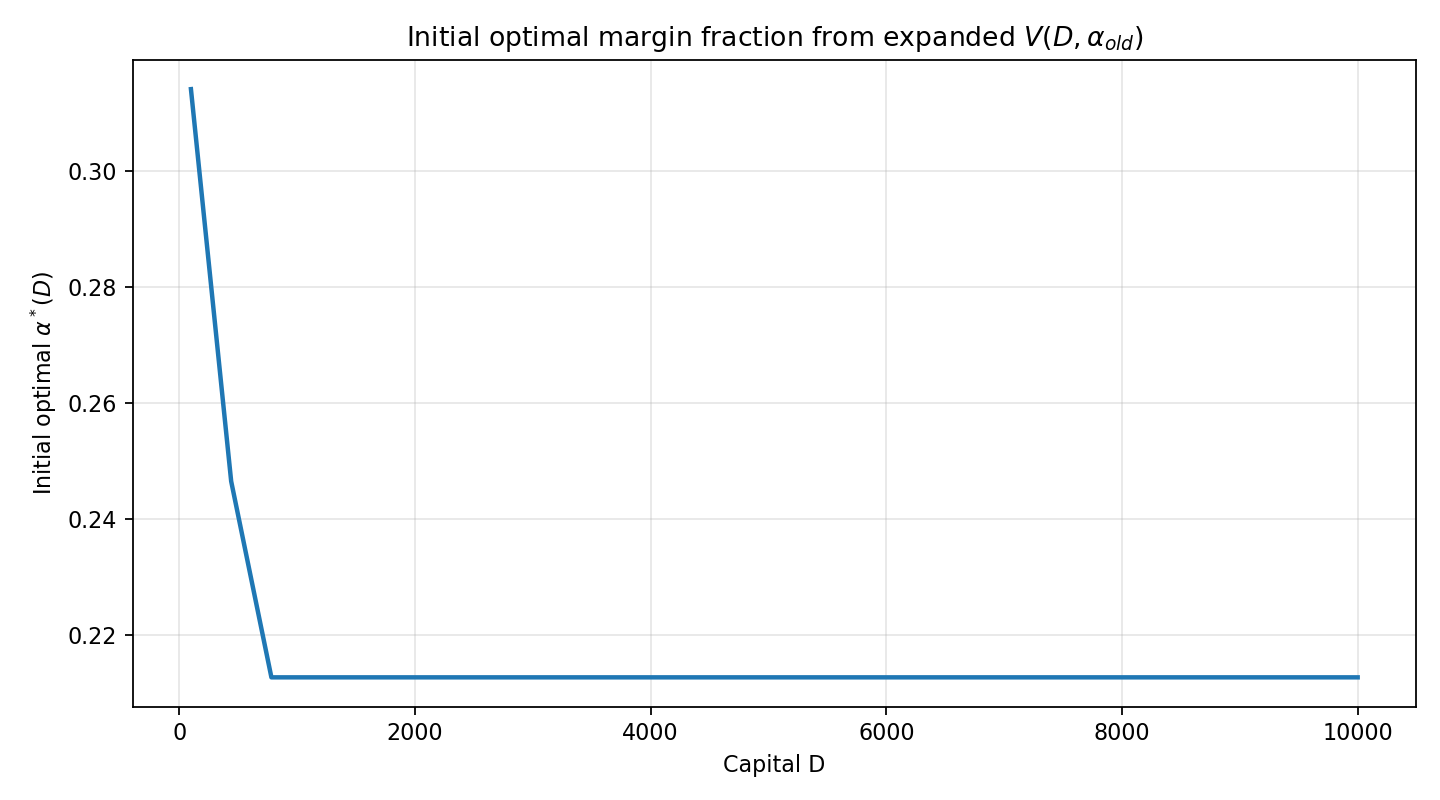


notebook_sim_outputs_state2_gamma_cost\static_alpha_policy_vs_D.png


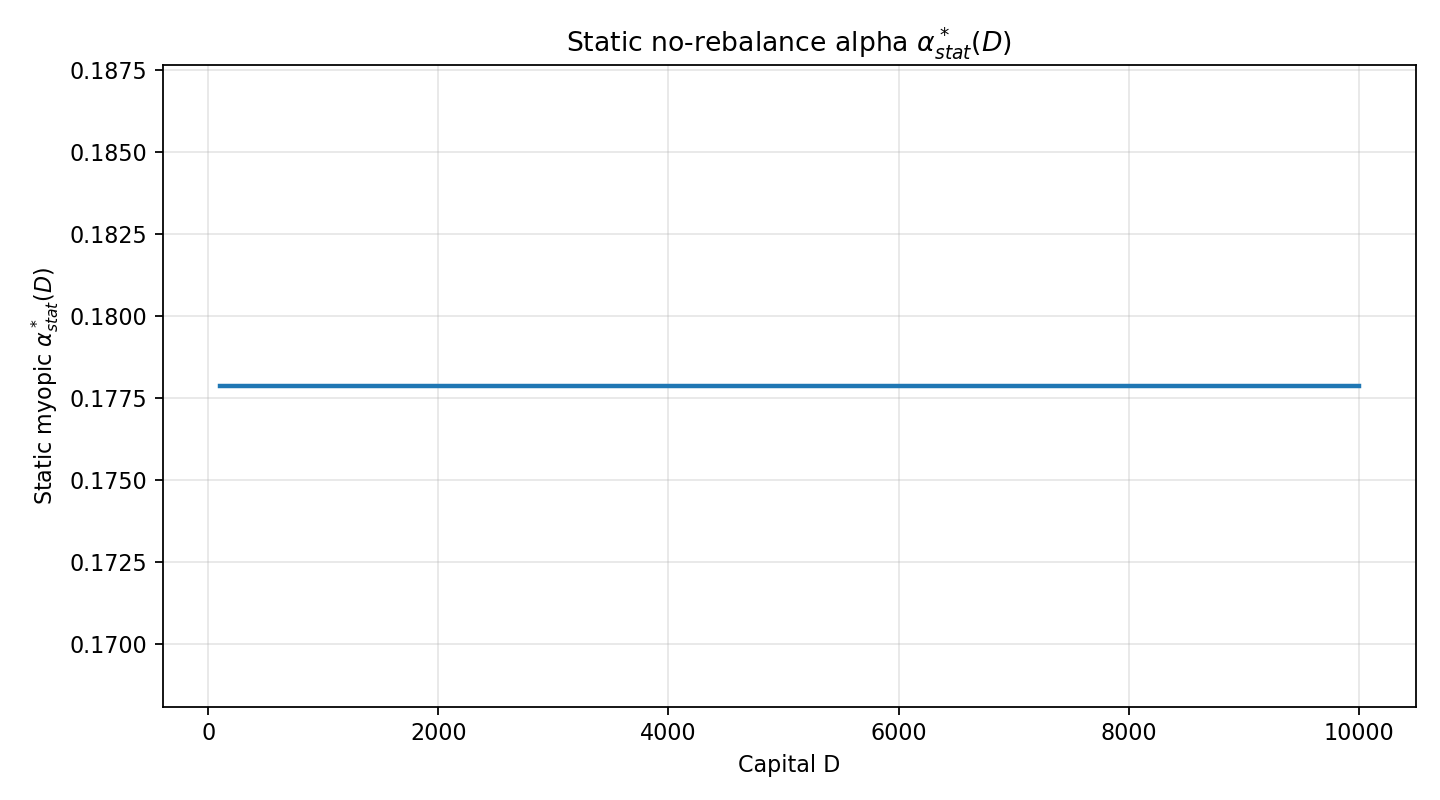


notebook_sim_outputs_state2_gamma_cost\terminal_return_comparison.png


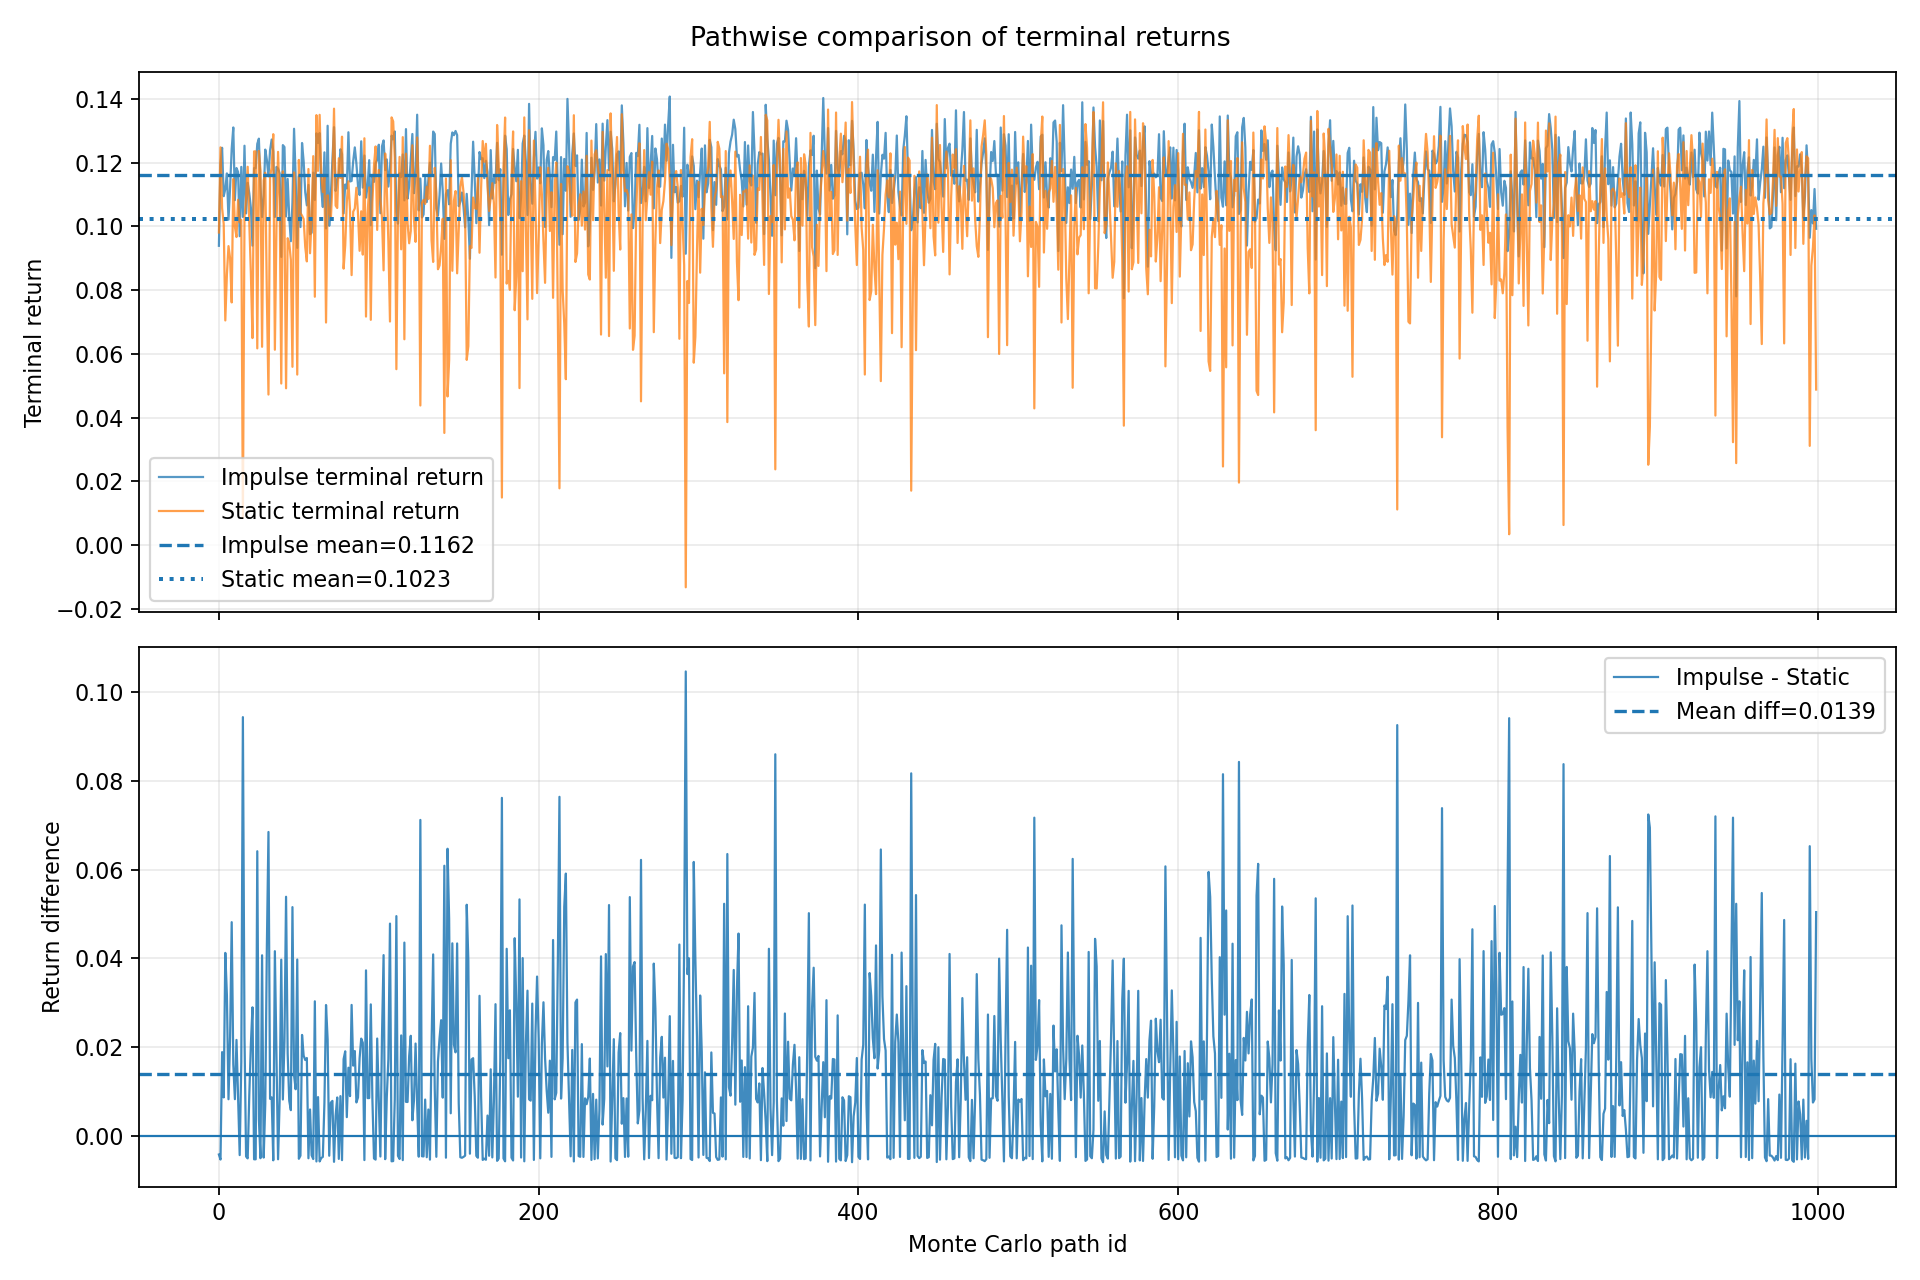


notebook_sim_outputs_state2_gamma_cost\sample_impulse_portfolio_path.png


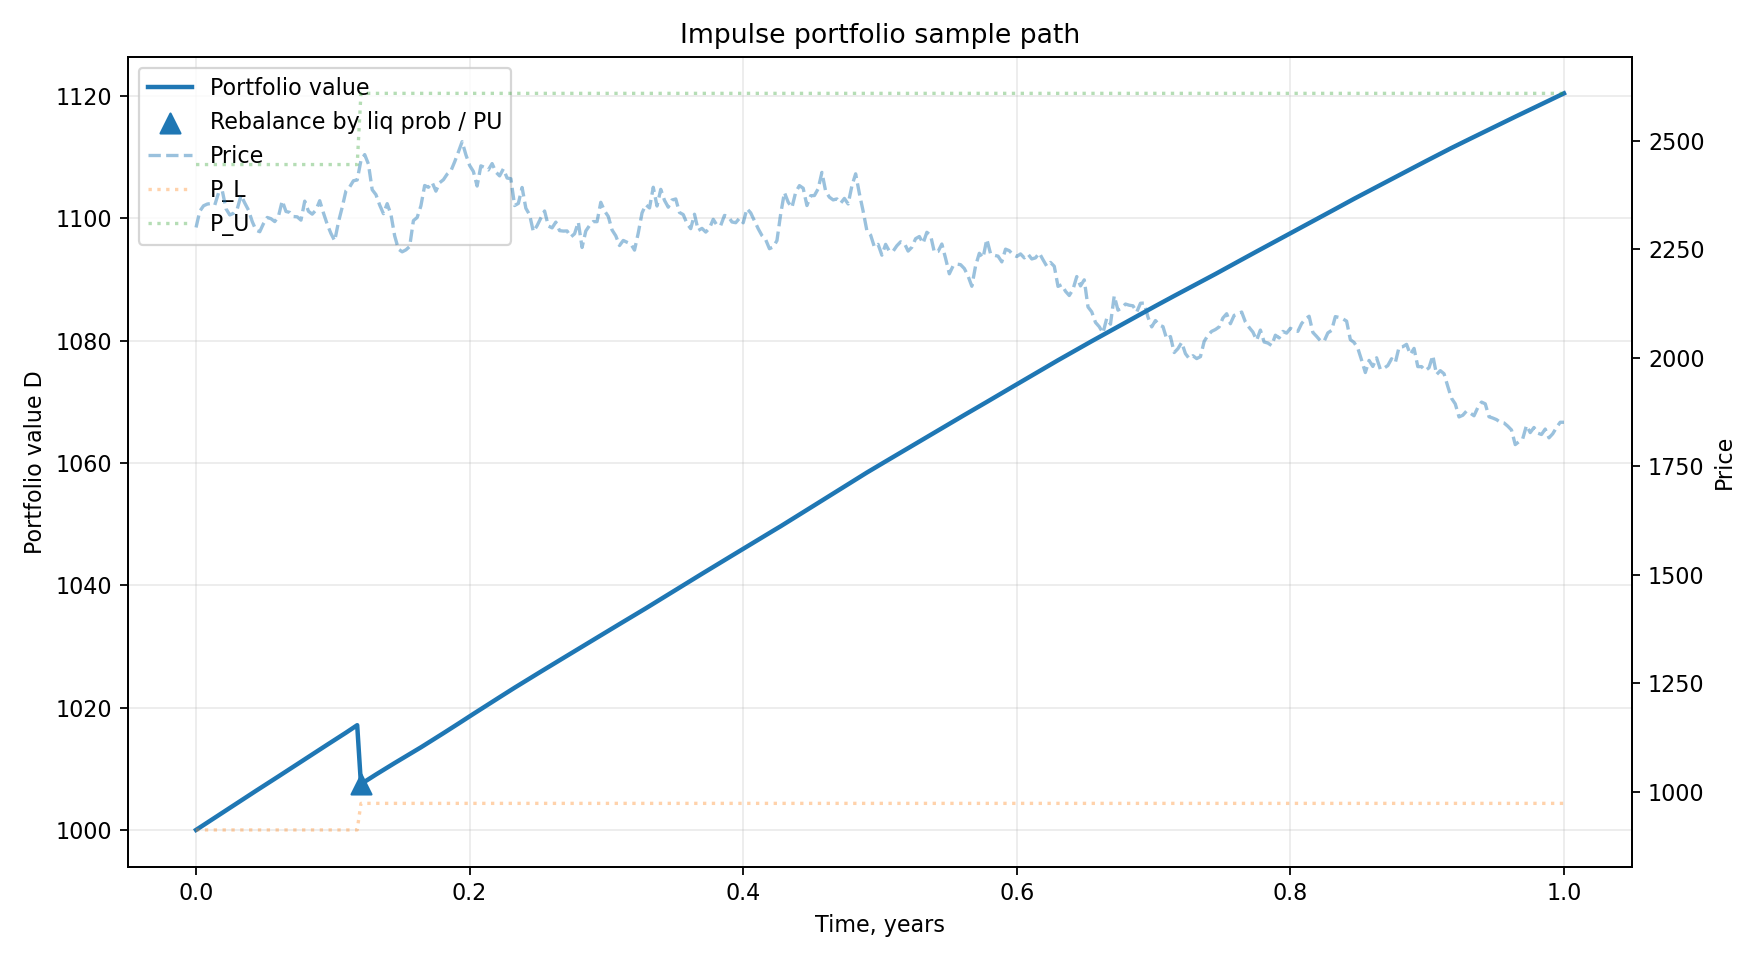


notebook_sim_outputs_state2_gamma_cost\sample_static_portfolio_path.png


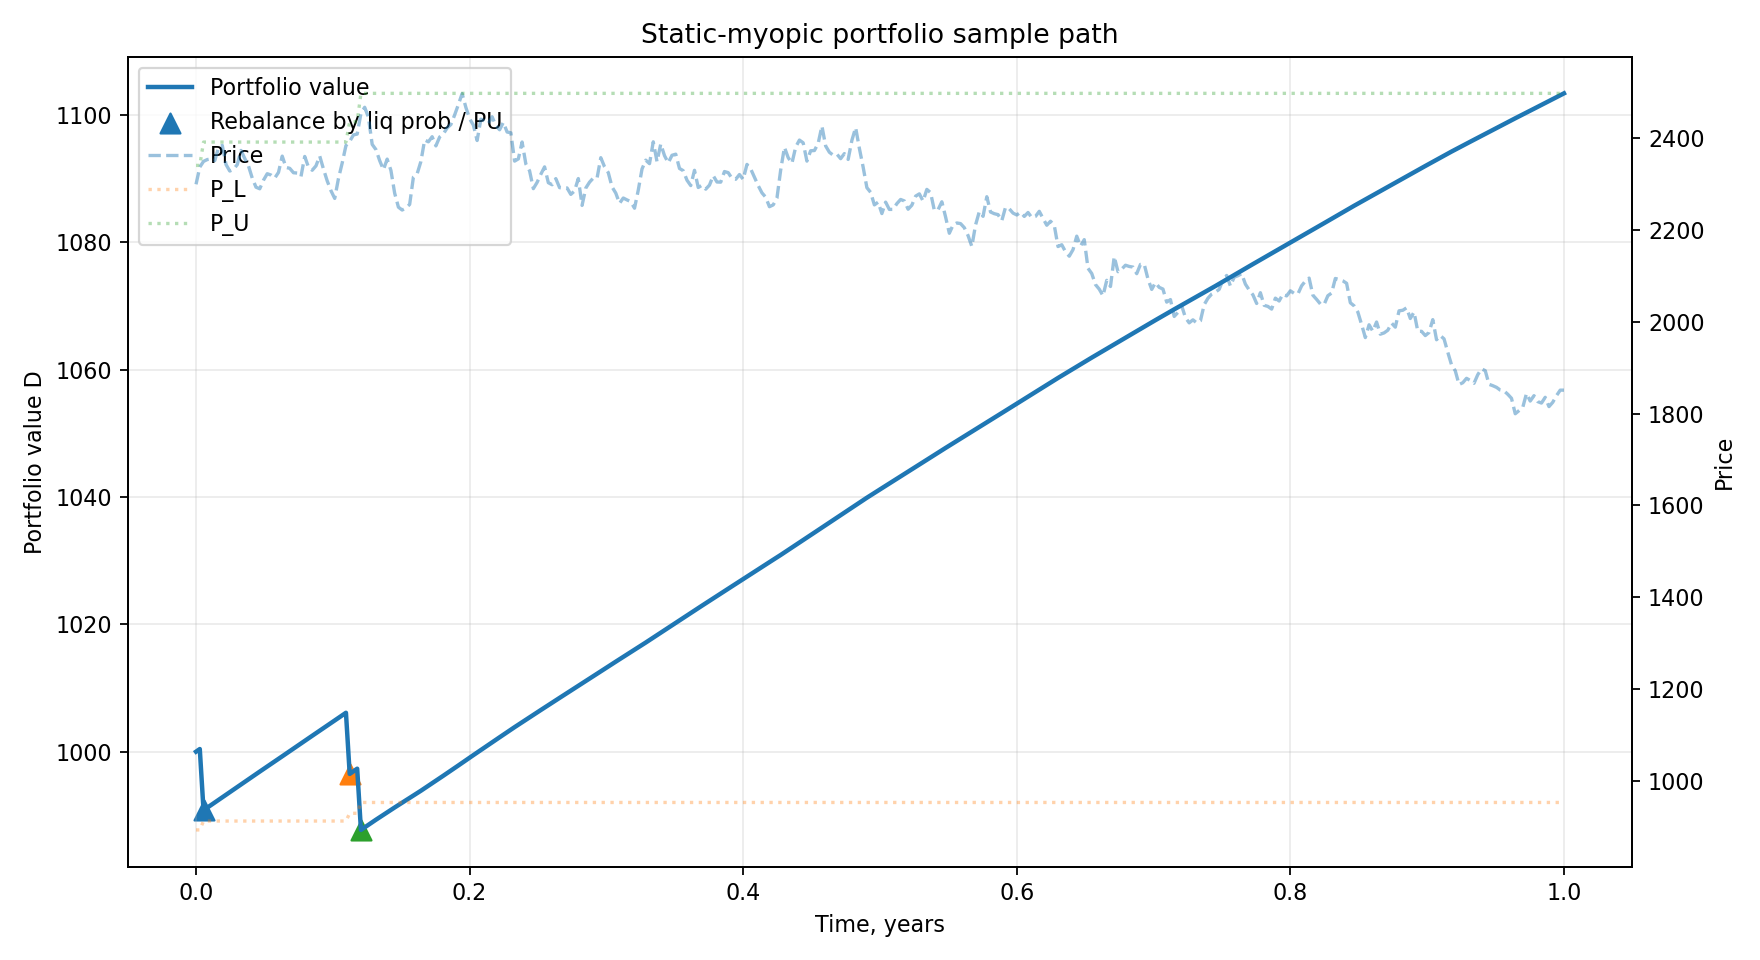


notebook_sim_outputs_state2_gamma_cost\sample_impulse_vs_static_path.png


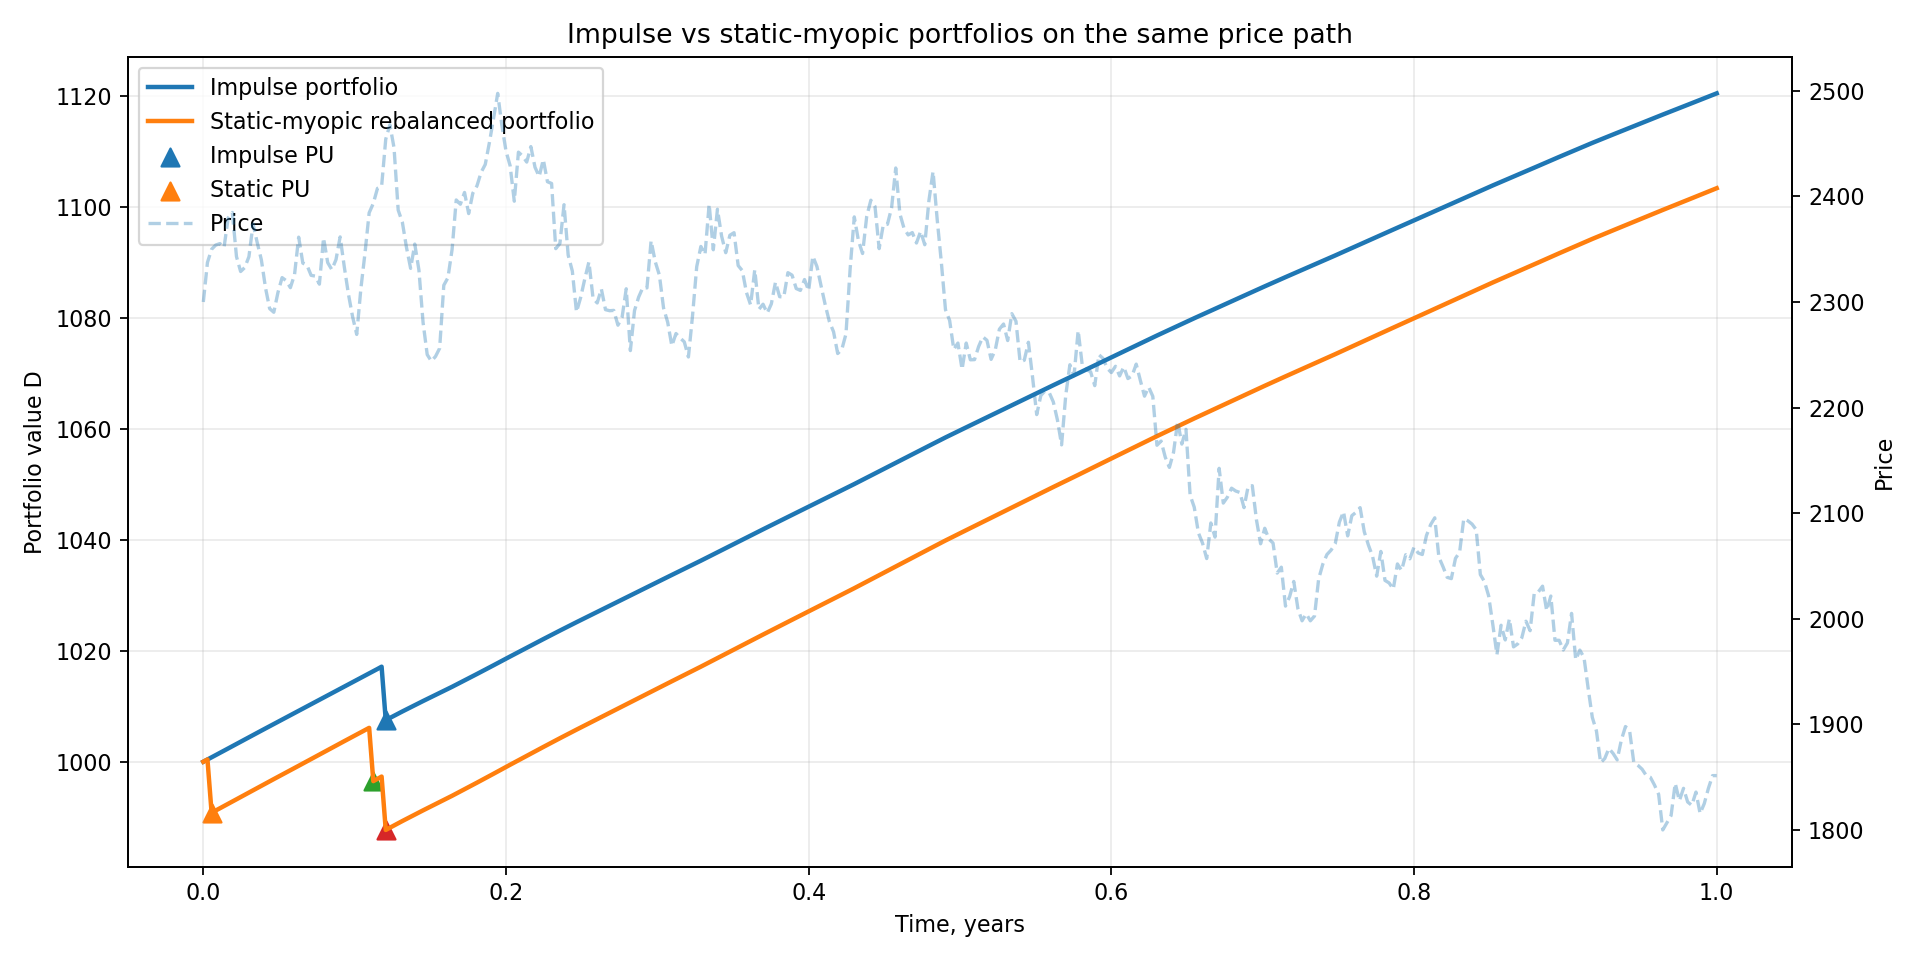


=== Output files ===
notebook_sim_outputs_state2_gamma_cost\alpha_policy_table_state2_gamma_cost.csv
notebook_sim_outputs_state2_gamma_cost\alpha_policy_vs_D.png
notebook_sim_outputs_state2_gamma_cost\portfolio_mc_results.csv
notebook_sim_outputs_state2_gamma_cost\sample_impulse_portfolio_path.png
notebook_sim_outputs_state2_gamma_cost\sample_impulse_vs_static_path.png
notebook_sim_outputs_state2_gamma_cost\sample_static_portfolio_path.png
notebook_sim_outputs_state2_gamma_cost\static_alpha_policy_vs_D.png
notebook_sim_outputs_state2_gamma_cost\terminal_return_comparison.png
notebook_sim_outputs_state2_gamma_cost\terminal_return_comparison_summary.csv


In [36]:
from pathlib import Path
import sys
import importlib.util
import pandas as pd
from IPython.display import display, Image

# ============================================================
# 1. Load simulator module
# ============================================================

MODULE_PATH = Path("impulse_alpha_simulator_gamma_cost_state2.py")

if not MODULE_PATH.exists():
    raise FileNotFoundError(
        f"Put {MODULE_PATH.name} in the same folder as this notebook, "
        "or change MODULE_PATH to the correct path."
    )

spec = importlib.util.spec_from_file_location("impulse_sim", MODULE_PATH)
impulse_sim = importlib.util.module_from_spec(spec)

# Important for dataclasses/importlib in Jupyter
sys.modules[spec.name] = impulse_sim

spec.loader.exec_module(impulse_sim)

# ============================================================
# 2. Parameters
# ============================================================
rho = 0.09 #0.0650

params = impulse_sim.ModelParams(
    mu=-0.3,
    sigma=0.2,
    kappa=0.015,
    iota=0.00375,
    kappa_tilde=0.545,
    gamma=0.05,
    rho=rho, #0.0650
    rx=rho + 0.0075,
    p0=2300.0,
    h=1.0,
    initial_D=1000.0,
    theta_F=0.0100,
    epsilon=0.06,

    # New cost convention:
    # K = c
    #   + c_spot_bps / 10000 * abs(Q_1 - Q_0) * p_1
    #   + c_fut_bps  / 10000 * abs(H_1 - H_0) * zeta * p_1
    #
    # Cost is now inside Gamma:
    # D_after = Gamma(D_before, cost)
    c_spot_bps=5.0,
    c_fut_bps=5.0,
    fixed_dollar_cost=10.0,
    max_cost_at_zero=False,

    # In your .txt formulas H is short:
    # H = -(1-alpha)D/(zeta P)
    futures_sign=-1.0,
)

out_dir = Path("notebook_sim_outputs_state2_gamma_cost")

# True = fast debug run.
# False = full run with 1000 Monte Carlo paths.
FAST_TEST = False

# True = recompute expanded V(D, alpha_old) table.
# False = load existing CSV if it exists.
FORCE_RECOMPUTE_POLICY = True

if FAST_TEST:
    table_cfg = impulse_sim.TableConfig(
        d_min=100.0,
        d_max=10_000.0,
        n_d=25,
        alpha_min=0.03,
        alpha_max=0.97,
        n_alpha=15,
        n_episode_mc=200,
        max_iter=8,
        tol=1e-3,
        policy_csv="alpha_policy_table_state2_gamma_cost_quick.csv",
    )

    sim_cfg = impulse_sim.SimulationConfig(
        n_paths=50,
        simulation_years=1.0,
        dt=1.0 / 252.0,
        n_jobs=-1,

        # Jupyter/Windows safe backend
        parallel_backend="threads",

        output_dir=str(out_dir),
    )

else:
    table_cfg = impulse_sim.TableConfig(
        d_min=100.0,
        d_max=10_000.0,
        n_d=30,
        alpha_min=0.01,
        alpha_max=0.99,
        n_alpha=30,
        n_episode_mc=2000,
        max_iter=800,
        tol=1e-4,
        policy_csv="alpha_policy_table_state2_gamma_cost.csv",
    )

    sim_cfg = impulse_sim.SimulationConfig(
        n_paths=1000,
        simulation_years=1.0,
        dt=1.0 / 365.0,
        n_jobs=-1,

        # Jupyter/Windows safe backend
        parallel_backend="threads",

        output_dir=str(out_dir),
    )

# ============================================================
# 3. Run full pipeline
# ============================================================

impulse_sim.run_full_pipeline(
    params=params,
    table_cfg=table_cfg,
    sim_cfg=sim_cfg,
    force_recompute_policy=FORCE_RECOMPUTE_POLICY,
)

# ============================================================
# 4. Load results
# ============================================================

mc_df = pd.read_csv(out_dir / sim_cfg.results_csv)
summary_df = pd.read_csv(out_dir / sim_cfg.return_comparison_summary_csv)
policy_df = pd.read_csv(out_dir / table_cfg.policy_csv)

# ============================================================
# 5. Print comparison metrics
# ============================================================

print("\n=== Mean return comparison ===")
print(f"Impulse mean return:              {mc_df['impulse_terminal_return'].mean():.6f}")
print(f"Static-myopic mean return:        {mc_df['static_terminal_return'].mean():.6f}")
print(f"Impulse - Static mean difference: {mc_df['impulse_minus_static_return'].mean():.6f}")
print(f"Impulse win rate:                 {mc_df['impulse_wins'].mean():.3f}")

print("\n=== Variance comparison ===")
print(f"Impulse return variance:          {mc_df['impulse_terminal_return'].var(ddof=1):.6f}")
print(f"Static-myopic return variance:    {mc_df['static_terminal_return'].var(ddof=1):.6f}")
print(f"Difference return variance:       {mc_df['impulse_minus_static_return'].var(ddof=1):.6f}")

print("\n=== Terminal capital comparison ===")
print(f"Impulse mean terminal D:          {mc_df['impulse_terminal_D'].mean():.6f}")
print(f"Static-myopic mean terminal D:    {mc_df['static_terminal_D'].mean():.6f}")
print(f"Impulse - Static mean terminal D: {mc_df['impulse_minus_static_terminal_D'].mean():.6f}")

print("\n=== Rebalance count comparison ===")
if "impulse_n_rebalances" in mc_df.columns:
    print(f"Impulse mean number of rebalances:       {mc_df['impulse_n_rebalances'].mean():.3f}")
if "static_n_rebalances" in mc_df.columns:
    print(f"Static-myopic mean number of rebalances: {mc_df['static_n_rebalances'].mean():.3f}")

# ============================================================
# 6. Expanded policy table diagnostics
# ============================================================

print("\n=== Expanded policy table diagnostics ===")
print(f"Rows in policy table:        {len(policy_df):,}")
print(f"Unique D states:             {policy_df['D'].nunique():,}")

if "state_alpha" in policy_df.columns:
    print(f"Unique alpha_old states:     {policy_df['state_alpha'].nunique():,}")

if "initial_alpha_star" in policy_df.columns:
    initial_policy = (
        policy_df[["D", "initial_alpha_star"]]
        .drop_duplicates("D")
        .sort_values("D")
    )
    print("\n=== Initial alpha*(D): first rows ===")
    display(initial_policy.head())

    print("\n=== Initial alpha*(D): last rows ===")
    display(initial_policy.tail())

if "next_alpha_star_at_r1" in policy_df.columns:
    print("\n=== Expanded policy table: first rows ===")
    display(policy_df[["state_alpha", "D", "value", "next_alpha_star_at_r1", "initial_alpha_star", "r_L", "r_U"]].head())
else:
    print("\n=== Policy table: first rows ===")
    display(policy_df.head())

# ============================================================
# 7. Display tables
# ============================================================

print("\n=== Summary table ===")
display(summary_df)

print("\n=== Monte Carlo results: first rows ===")
display(mc_df.head())

# ============================================================
# 8. Display plots
# ============================================================

plot_files = [
    sim_cfg.alpha_policy_plot,
    sim_cfg.static_alpha_policy_plot,
    sim_cfg.return_comparison_plot,
    sim_cfg.sample_path_plot,
    sim_cfg.static_sample_path_plot,
    sim_cfg.combined_sample_path_plot,
]

for plot_name in plot_files:
    plot_path = out_dir / plot_name
    print(f"\n{plot_path}")

    if plot_path.exists():
        display(Image(filename=str(plot_path)))
    else:
        print(f"Plot not found: {plot_path}")

# ============================================================
# 9. Optional: show saved files
# ============================================================

print("\n=== Output files ===")
for p in sorted(out_dir.glob("*")):
    print(p)

Model parameters:
ModelParams(mu=-0.3, sigma=0.2, kappa=0.015, iota=0.00375, kappa_tilde=0.545, gamma=0.05, rho=0.07, rx=0.0775, p0=2300.0, h=1.0, initial_D=1000.0, theta_F=0.01, epsilon=0.06, c_gas=10.0, c_spot=5.0, c_fut=5.0, futures_sign=-1.0)

Computed zeta = 1.5000000000

Table config:
TableConfig(d_min=100.0, d_max=10000.0, n_d=120, alpha_min=0.01, alpha_max=0.99, n_alpha=100, n_episode_mc=2000, dt_episode=0.0027397260273972603, max_episode_time=2.0, max_iter=300, tol=0.0001, relaxation=1.0, seed=42, n_jobs=-1, parallel_backend='threads', policy_csv='impulse_sim_outputs/alpha_policy_table_operator_cost.csv')

Simulation config:
SimulationConfig(n_paths=1000, simulation_years=1.0, dt=0.0027397260273972603, seed=777, n_jobs=-1, parallel_backend='threads', apply_cost_to_cash=False, output_dir='impulse_sim_outputs', mc_results_csv='mc_terminal_returns.csv', summary_csv='mc_summary.csv', alpha_plot='alpha_policy_vs_D.png', sample_path_plot='sample_portfolio_path.png', terminal_hist_pl

,state_alpha,D,value,initial_alpha_star,r_L,r_U,P_L_initial,P_U_initial,iterations,final_error,solver
0,0.01,100.000000,4.666950e+07,0.247576,0.353682,1.000001,813.46929,2300.0023,300.0,0.039642,numba_fast_operator_cost
1,0.01,183.193277,8.549547e+07,0.247576,0.353682,1.000001,813.46929,2300.0023,300.0,0.039642,numba_fast_operator_cost
2,0.01,266.386555,1.243214e+08,0.247576,0.353682,1.000001,813.46929,2300.0023,300.0,0.039642,numba_fast_operator_cost
3,0.01,349.579832,1.631474e+08,0.247576,0.353682,1.000001,813.46929,2300.0023,300.0,0.039642,numba_fast_operator_cost
4,0.01,432.773109,2.019734e+08,0.247576,0.353682,1.000001,813.46929,2300.0023,300.0,0.039642,numba_fast_operator_cost



Static one-horizon alpha = 0.17786878

Running paired Monte Carlo: impulse vs static-myopic...
Monte Carlo finished. real_time=39.78s


,metric,impulse,static,impulse_minus_static
0,mean_terminal_return,0.114924,0.103802,0.011122
1,variance_terminal_return,0.000105,0.000460,0.000510
2,std_terminal_return,0.010256,0.021436,0.022586
3,mean_terminal_D,1114.923622,1103.802024,11.121597
4,mean_n_rebalances,0.207000,2.173000,-1.966000
5,impulse_win_rate,0.660000,0.340000,0.320000



Impulse-control portfolio:
mean terminal return     = 0.11492362
variance terminal return = 0.00010518
mean n_rebalances        = 0.2070

Static-myopic portfolio:
mean terminal return     = 0.10380202
variance terminal return = 0.00045952
mean n_rebalances        = 2.1730

Paired comparison:
mean impulse - static    = 0.01112160
variance diff            = 0.00051013
impulse win rate         = 0.6600

Saved plots:
impulse_sim_outputs\alpha_policy_vs_D.png
impulse_sim_outputs\static_alpha_policy_vs_D.png
impulse_sim_outputs\terminal_return_comparison.png


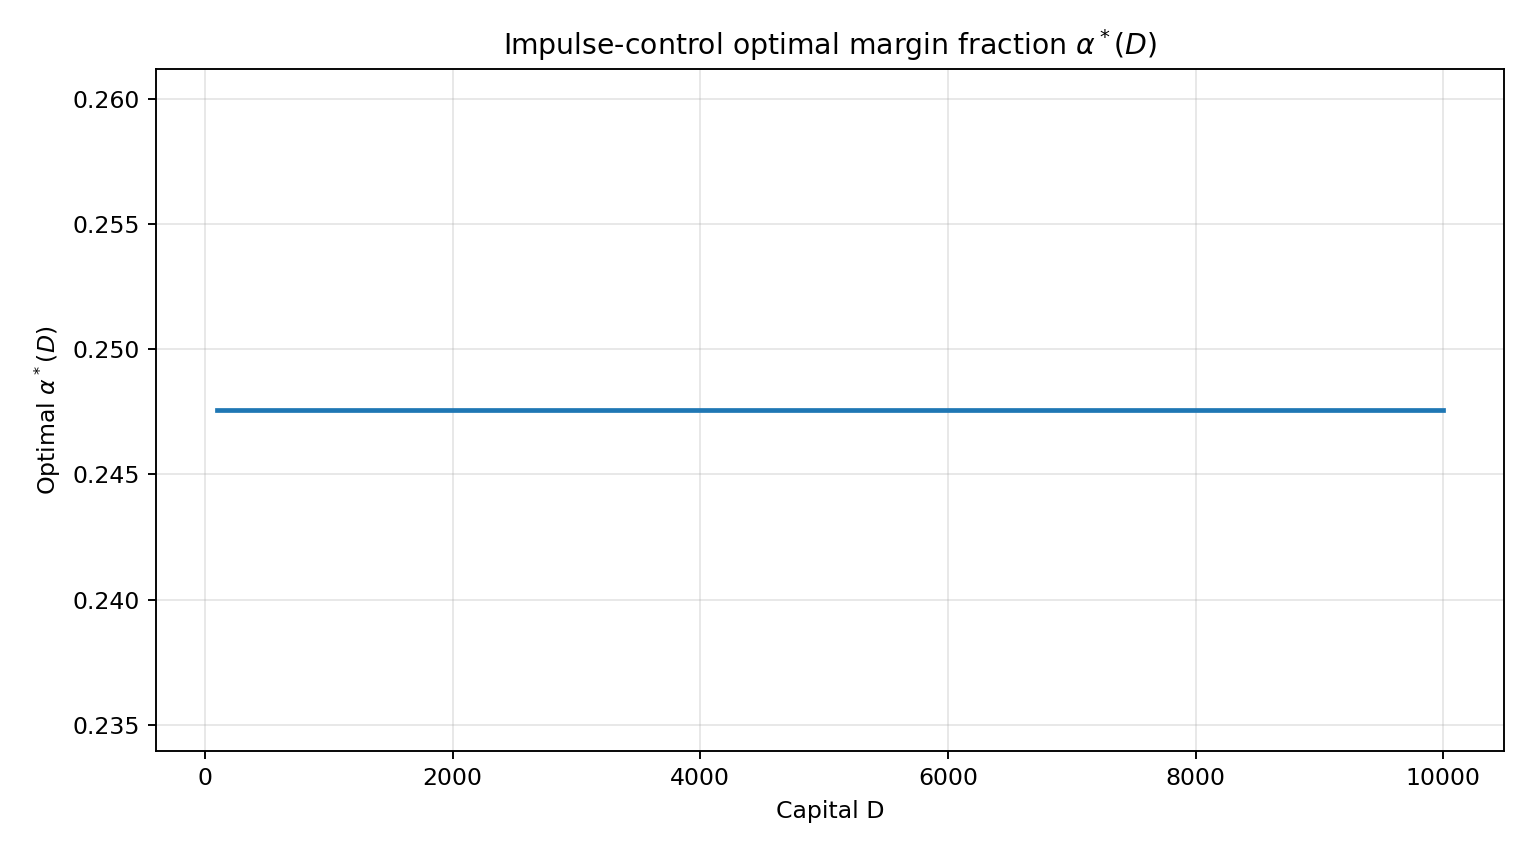

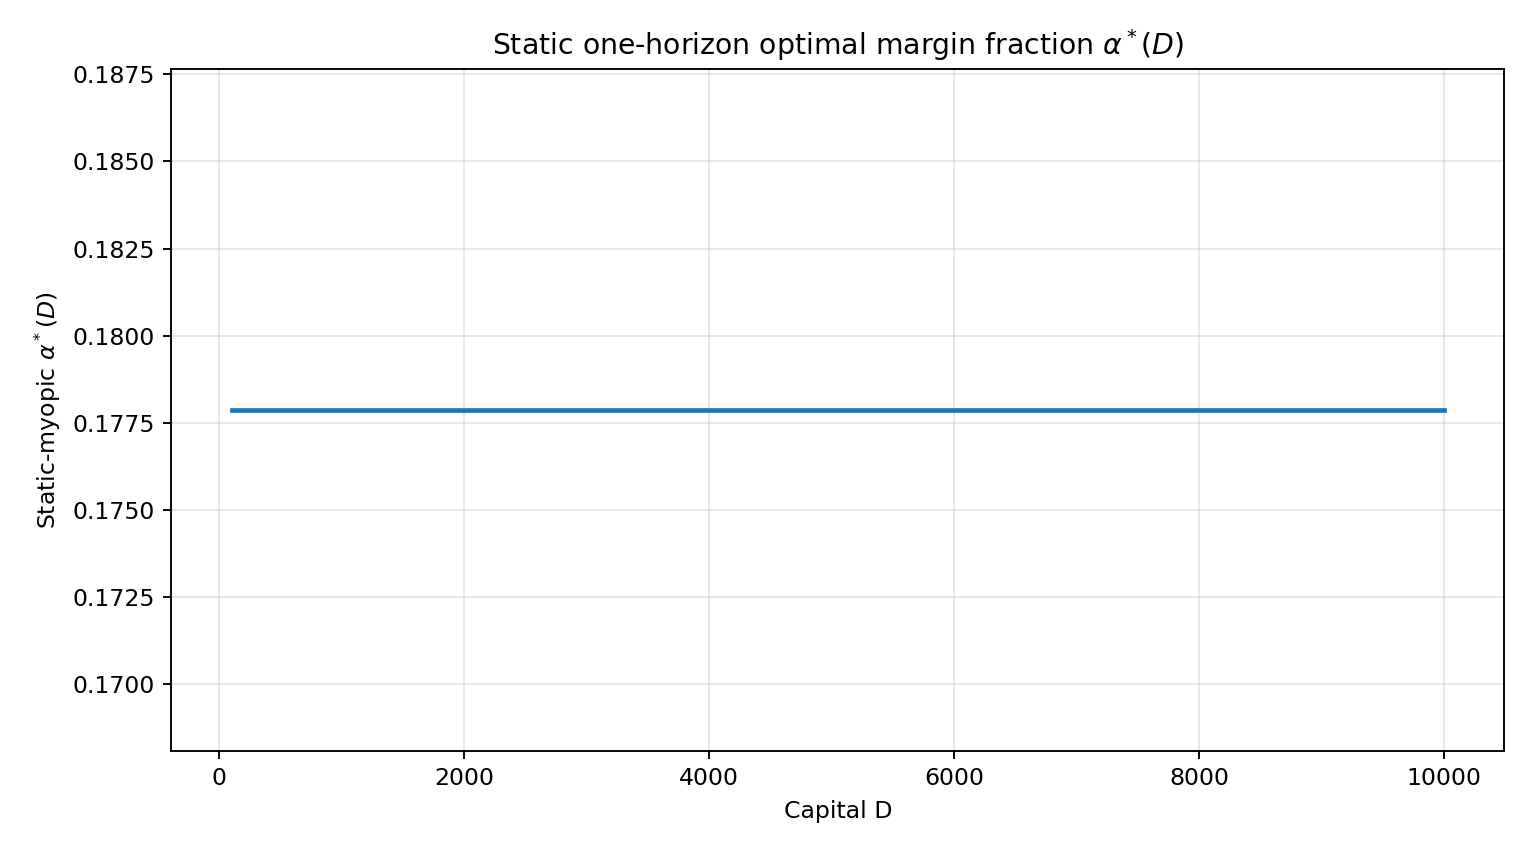

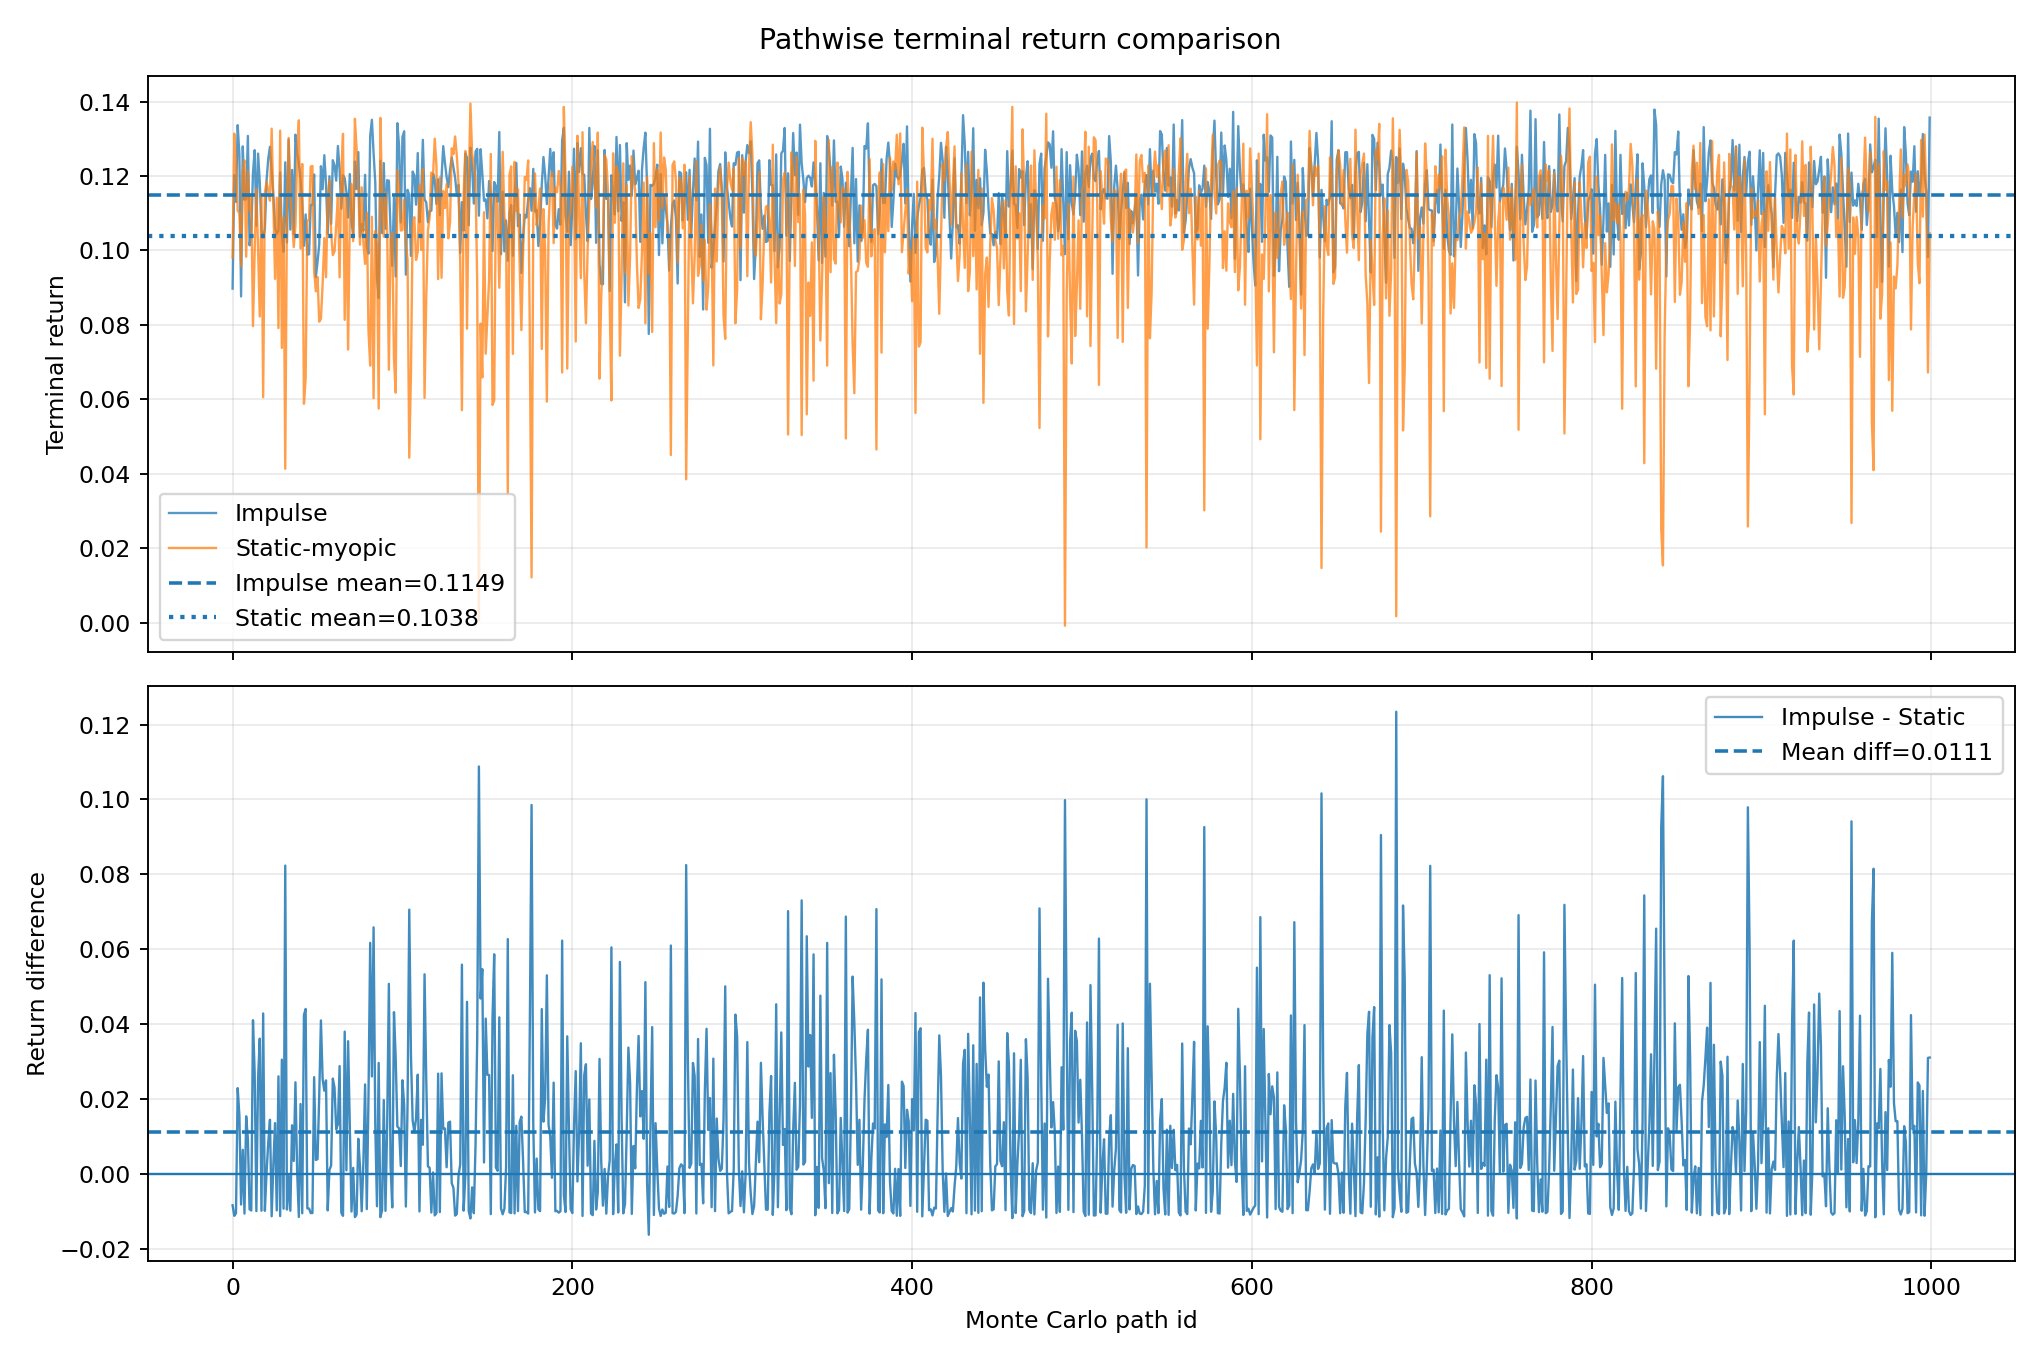


Searching sample path with impulse n_rebalances in [4, 5, 6]...
Search finished. real_time=6.89s
sample seed                  = 10004153
impulse n_rebalances         = 4
static n_rebalances          = 19
impulse terminal return      = 0.10595063
static terminal return       = -0.03477490

Representative path plots:
impulse_sim_outputs\sample_impulse_portfolio_path_target_rebalances.png
impulse_sim_outputs\sample_static_portfolio_path_same_price.png
impulse_sim_outputs\sample_impulse_vs_static_same_price_target_rebalances.png
impulse_sim_outputs\sample_price_band_path_target_rebalances.png


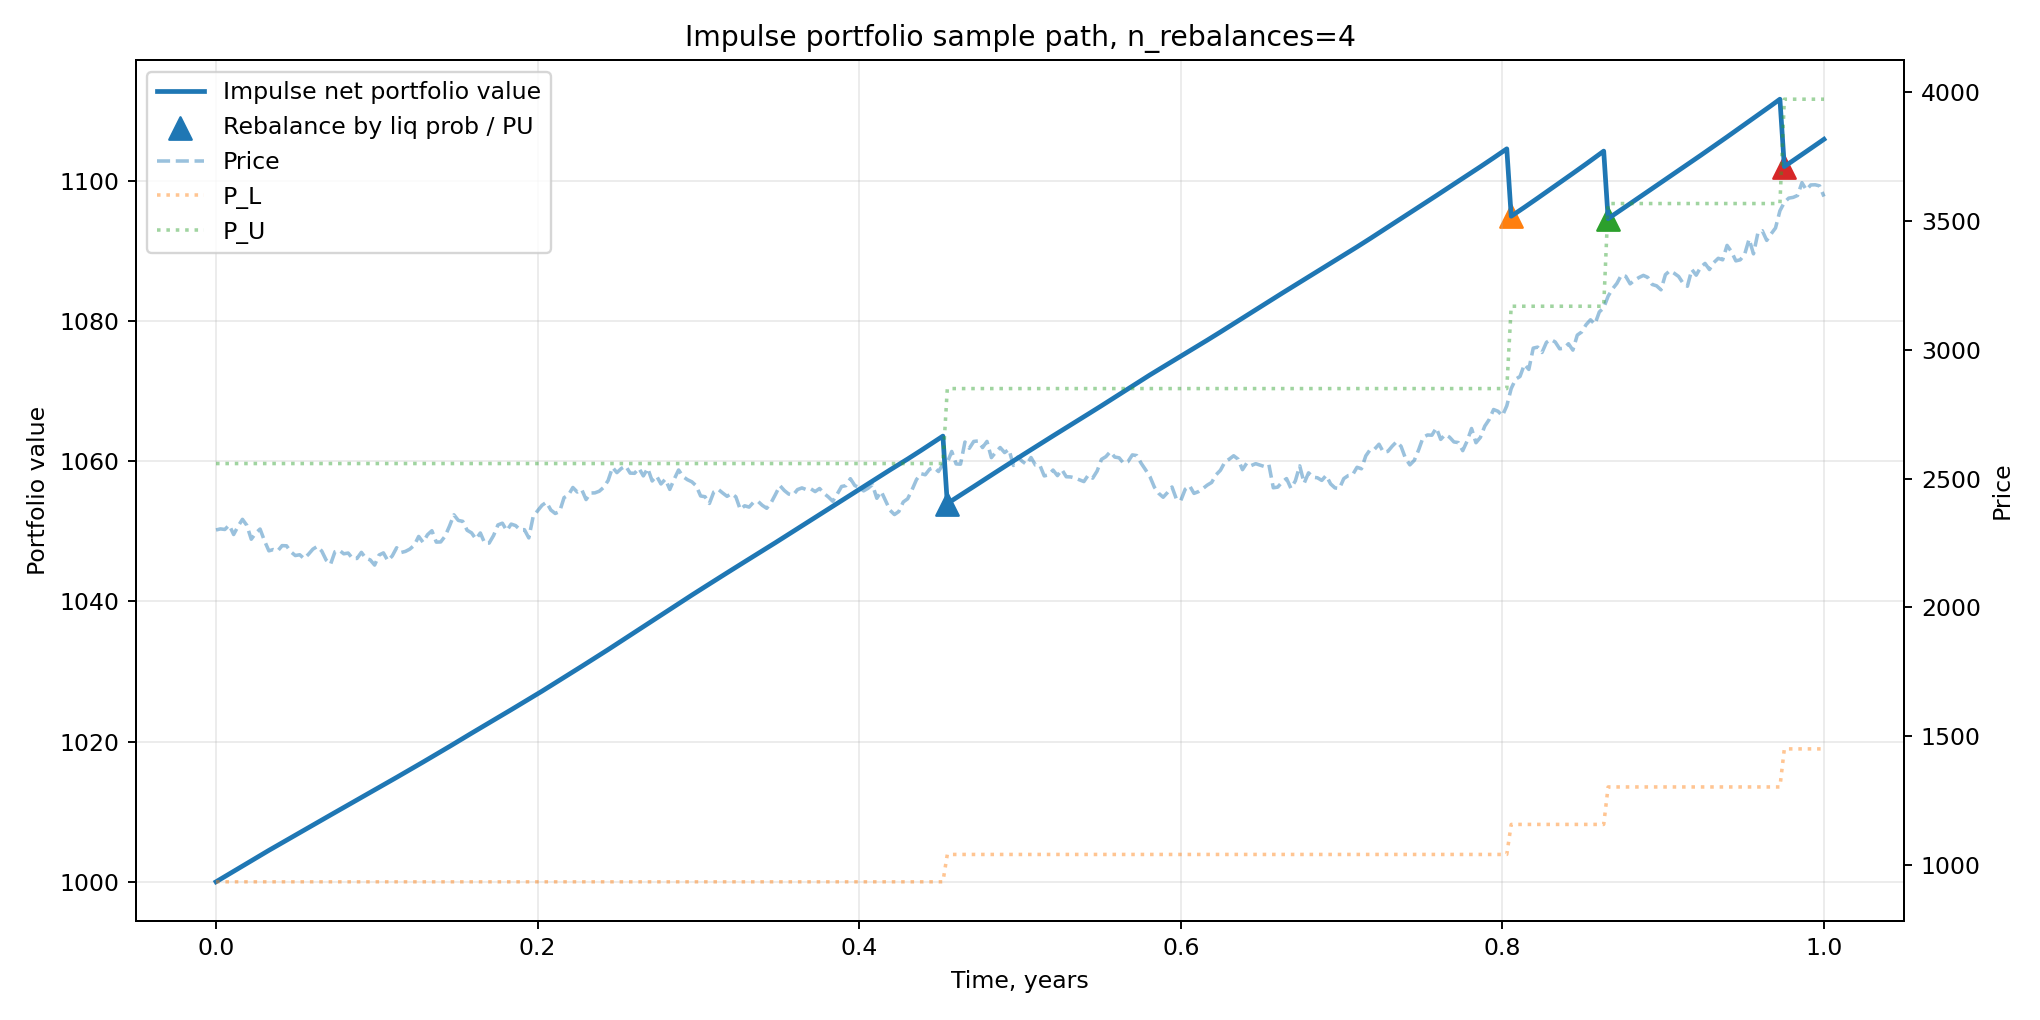

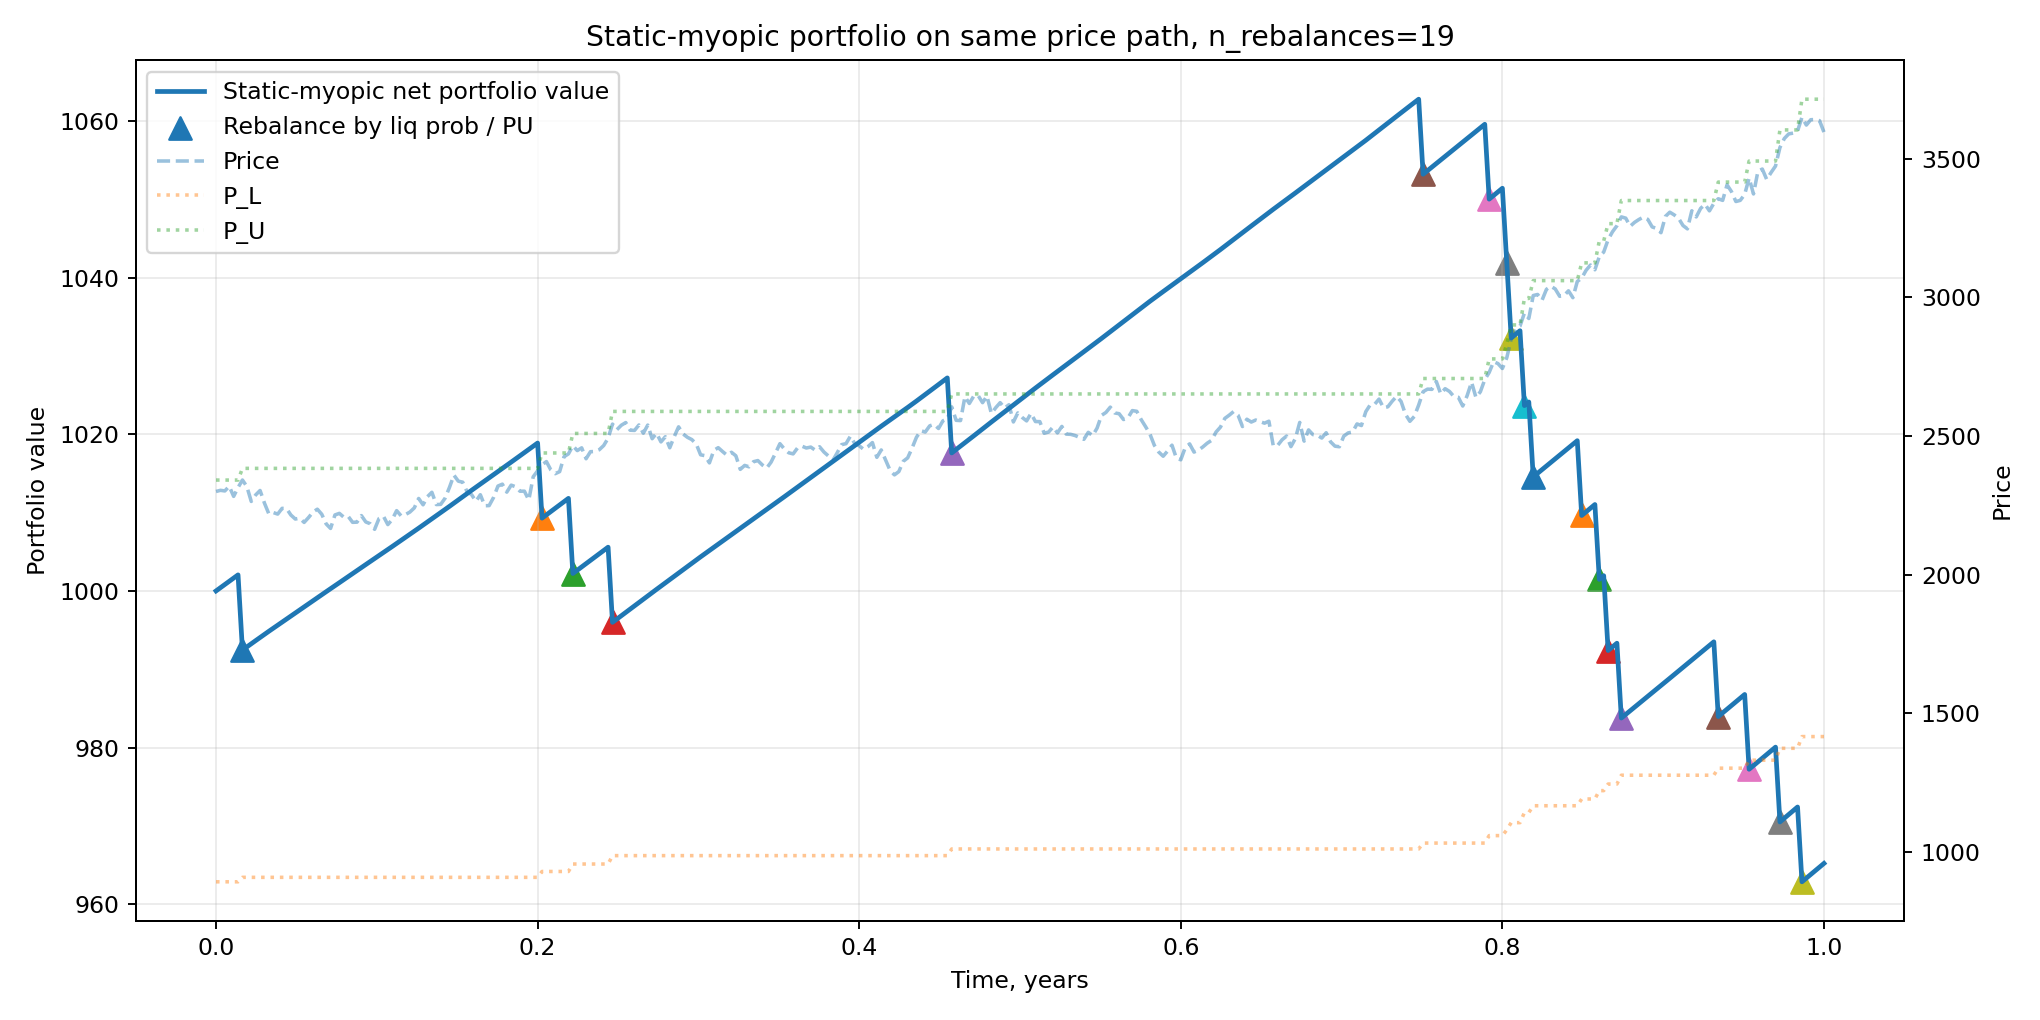

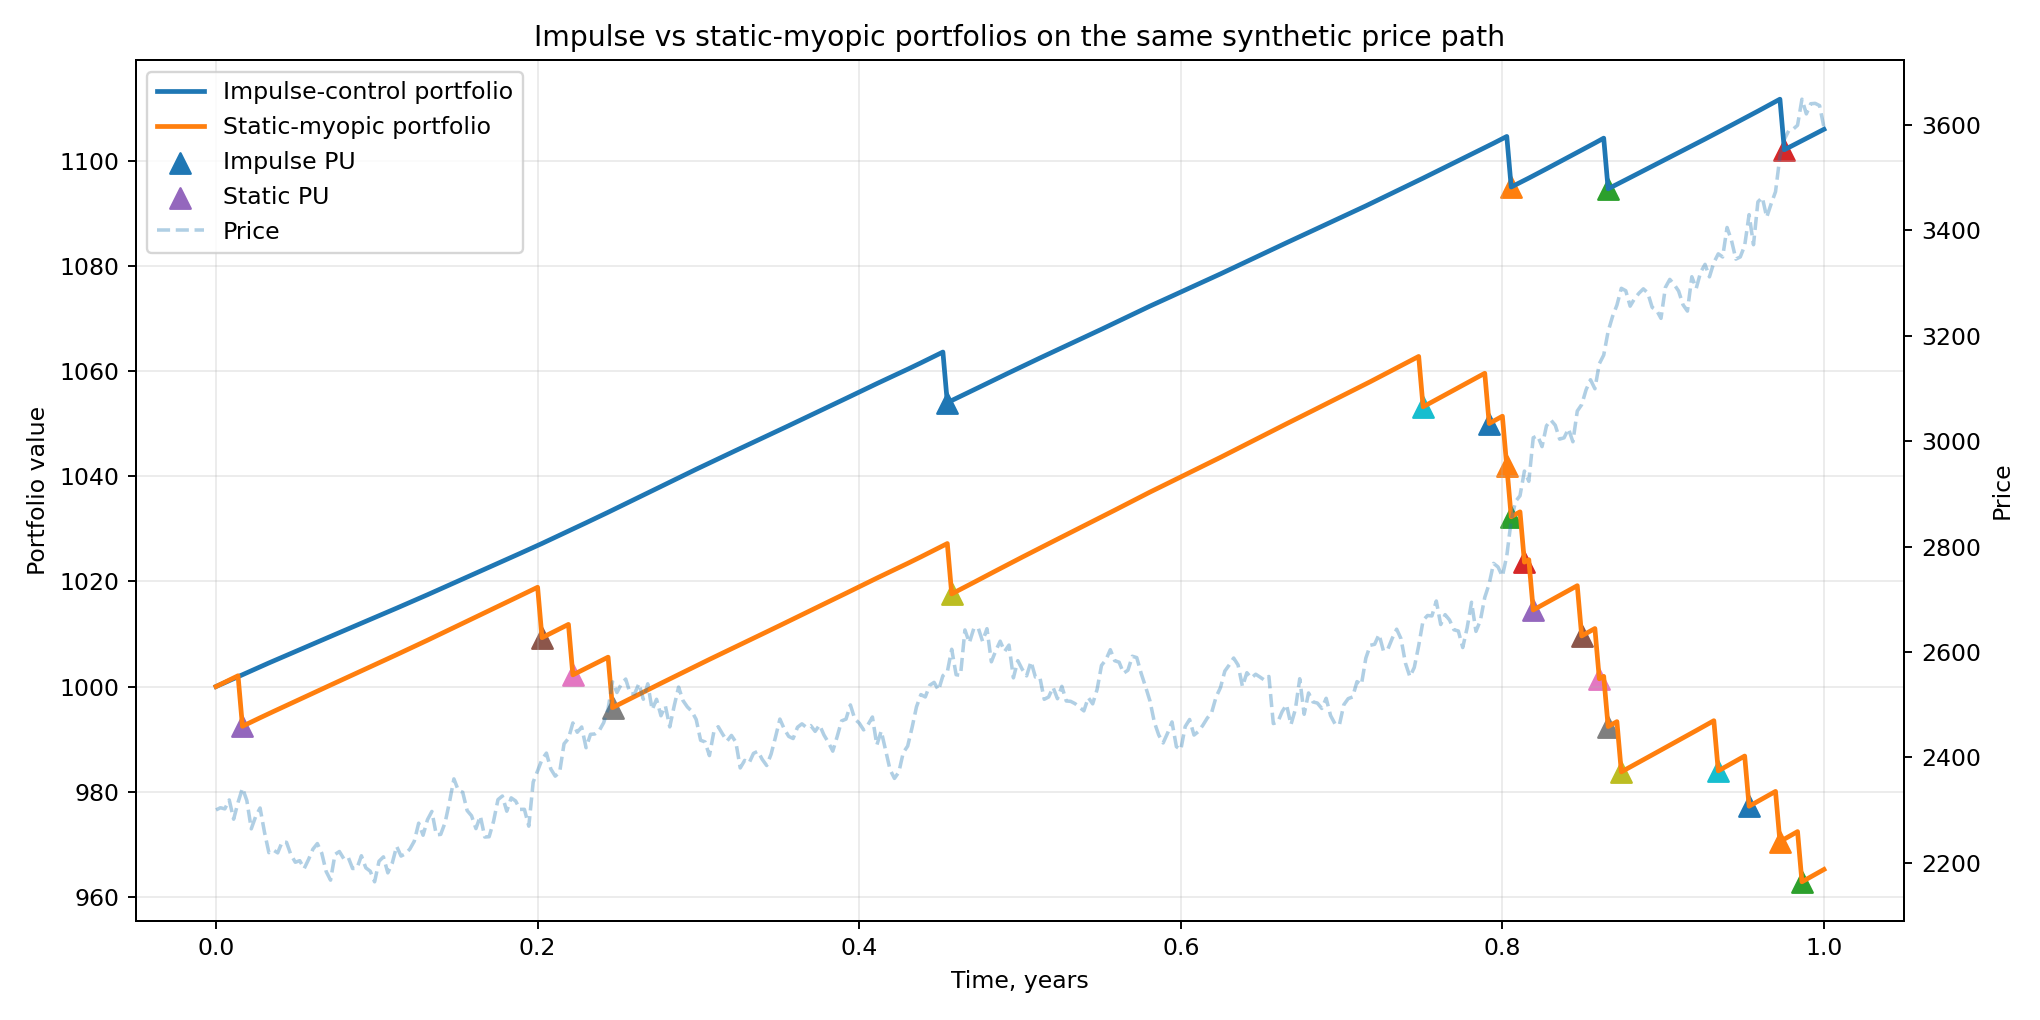

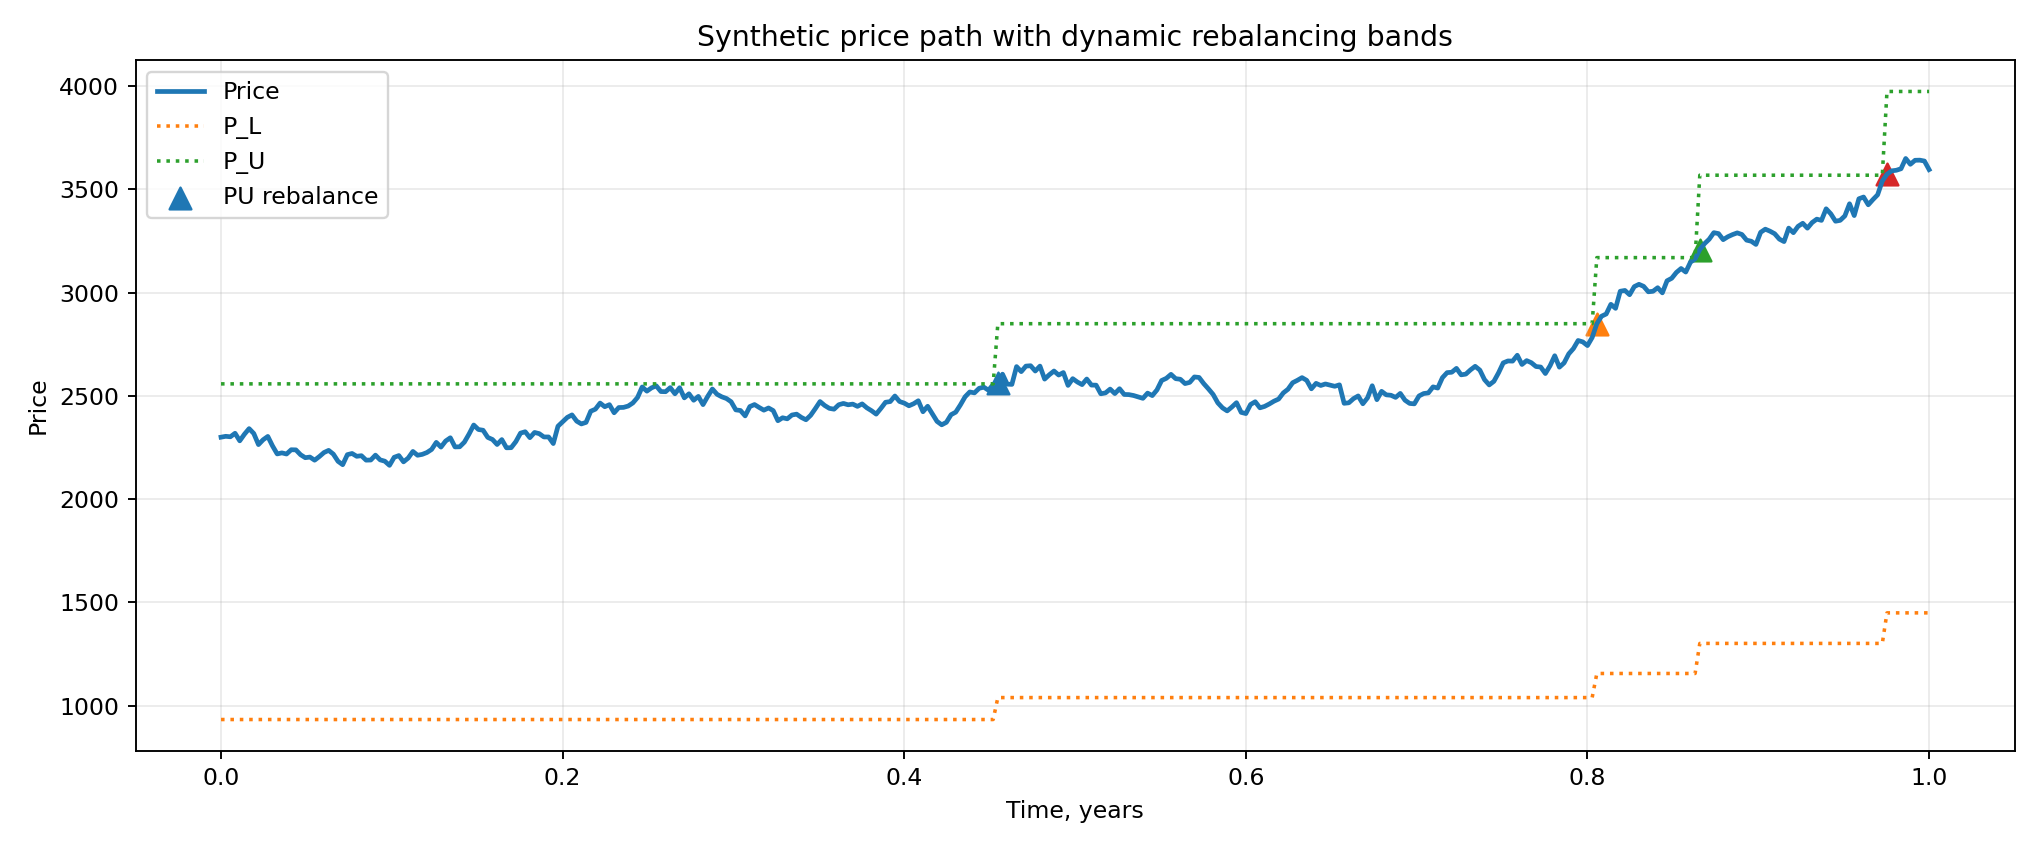


Impulse rebalance events:


,alpha,D_before,D_after,cost,Q,H,P_L,P_U,time,price,trigger,old_alpha,old_P_L,old_P_U,portfolio_before_cost,portfolio_net_after_rebalance
0,0.247576,1064.013630,1064.013630,10.037508,0.312500,-0.208333,1039.343880,2849.389761,0.454795,2561.885582,PU,0.247576,933.098238,2558.114420,1064.013630,1053.976122
1,0.247576,1115.060689,1115.060689,10.051472,0.294437,-0.196291,1156.028882,3169.284894,0.805479,2849.503212,PU,0.247576,1039.343880,2849.389761,1115.060689,1094.971710
2,0.247576,1124.815823,1124.815823,10.098290,0.263800,-0.175867,1301.572634,3568.297086,0.865753,3208.254968,PU,0.247576,1156.028882,3169.284894,1124.815823,1094.628553
3,0.247576,1142.322905,1142.322905,10.082981,0.240574,-0.160383,1449.446285,3973.696756,0.975342,3572.749705,PU,0.247576,1301.572634,3568.297086,1142.322905,1102.052655



Static-myopic rebalance events:


,alpha,D_before,D_after,cost,Q,H,P_L,P_U,time,price,trigger,old_alpha,old_P_L,old_P_U,portfolio_before_cost,portfolio_net_after_rebalance
0,0.177869,1002.462703,1002.462703,10.012772,0.351994,-0.234662,908.730033,2383.352602,0.016438,2341.394141,PU,0.177869,892.664348,2341.216666,1002.462703,992.449931
1,0.177869,1029.305436,1029.305436,10.002865,0.353190,-0.235460,929.903523,2438.884928,0.202740,2395.948832,PU,0.177869,908.730033,2383.352602,1029.305436,1009.289799
2,0.177869,1032.260977,1032.260977,10.021988,0.344270,-0.229513,956.736304,2509.260041,0.221918,2465.085004,PU,0.177869,929.903523,2438.884928,1032.260977,1002.223351
3,0.177869,1036.051771,1036.051771,10.023746,0.334932,-0.223288,987.019940,2588.685811,0.246575,2543.112499,PU,0.177869,956.736304,2509.260041,1036.051771,995.990400
4,0.177869,1067.680676,1067.680676,10.005272,0.336956,-0.224637,1011.042794,2651.691247,0.457534,2605.008736,PU,0.177869,987.019940,2588.685811,1067.680676,1017.614033
5,0.177869,1113.268650,1113.268650,10.019042,0.344116,-0.229410,1032.279100,2707.388323,0.750685,2659.725276,PU,0.177869,1011.042794,2651.691247,1113.268650,1053.182965
6,0.177869,1120.109842,1120.109842,10.018260,0.337425,-0.224950,1059.217401,2778.040185,0.791781,2729.133325,PU,0.177869,1032.279100,2707.388323,1120.109842,1050.005896
7,0.177869,1121.962001,1121.962001,10.016477,0.331503,-0.221002,1079.921528,2832.341499,0.802740,2782.478676,PU,0.177869,1059.217401,2778.040185,1121.962001,1041.841578
8,0.177869,1122.426624,1122.426624,10.021837,0.323840,-0.215893,1105.934751,2900.567135,0.805479,2849.503212,PU,0.177869,1079.921528,2832.341499,1122.426624,1032.284364
9,0.177869,1123.825411,1123.825411,10.029223,0.313911,-0.209274,1142.336445,2996.038911,0.813699,2943.294227,PU,0.177869,1105.934751,2900.567135,1123.825411,1023.653928


In [1]:
# =========================
# Jupyter one-cell launcher
# =========================

import sys
import time
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ---------------------------------------------------------------------
# 1. Path to simulator .py
# ---------------------------------------------------------------------
# Поменяйте путь, если файл лежит в другой директории.
SIMULATOR_PY = Path("impulse_control_portfolio_simulator_with_static_fast.py")

if not SIMULATOR_PY.exists():
    raise FileNotFoundError(f"Simulator file not found: {SIMULATOR_PY}")

spec = importlib.util.spec_from_file_location("impulse_sim", SIMULATOR_PY)
impulse_sim = importlib.util.module_from_spec(spec)
sys.modules["impulse_sim"] = impulse_sim
spec.loader.exec_module(impulse_sim)

# ---------------------------------------------------------------------
# 2. USER PARAMETERS
# ---------------------------------------------------------------------
params = impulse_sim.ModelParams(
    mu=-0.3,
    sigma=0.2,
    kappa=0.015,
    iota=0.00375,
    kappa_tilde=0.545,
    gamma=0.05,
    rho=0.07,
    rx=0.0775,
    p0=2300.0,
    h=1.0,
    initial_D=1000.0,
    theta_F=0.0100,
    epsilon=0.06,
    c_gas=10.0,
    c_spot=5.0,
    c_fut=5.0,
    futures_sign=-1.0,   # -1.0 для short futures, +1.0 если H=+Q/zeta
)

# Предрасчёт policy table для impulse-control.
# Для production оставьте n_episode_mc=2000, n_paths=1000.
# Для быстрой проверки можно уменьшить n_episode_mc, n_d, n_alpha, n_paths.
table_cfg = impulse_sim.TableConfig(
    d_min=100.0,
    d_max=10_000.0,
    n_d=120,
    alpha_min=0.01,
    alpha_max=0.99,
    n_alpha=100,
    n_episode_mc=2000,
    dt_episode=1.0 / 365.0,
    max_episode_time=2.0,
    max_iter=300,
    tol=1e-4,
    relaxation=1.0, #0.7
    seed=42,
    n_jobs=-1,
    parallel_backend="threads",
    policy_csv="impulse_sim_outputs/alpha_policy_table_operator_cost.csv",
)

sim_cfg = impulse_sim.SimulationConfig(
    n_paths=1000,
    simulation_years=1.0,
    dt=1.0 / 365.0,
    seed=777,
    n_jobs=-1,
    parallel_backend="threads",
    apply_cost_to_cash=False,  # False = convention 2: K вычитается в операторе/ledger
    output_dir="impulse_sim_outputs",
)

# Если True, таблица alpha*(D) пересчитается заново.
# Если False и CSV уже есть, таблица будет загружена из файла.
FORCE_RECOMPUTE_POLICY = True

# Для sample path хотим траекторию, где impulse делает 4-6 ребалансировок.
TARGET_REBALANCES = {4, 5, 6}
MAX_SAMPLE_SEARCH = 5000

# ---------------------------------------------------------------------
# 3. Build/load impulse policy table
# ---------------------------------------------------------------------
out_dir = Path(sim_cfg.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)

print("Model parameters:")
print(params)
print(f"\nComputed zeta = {params.zeta:.10f}")
print("\nTable config:")
print(table_cfg)
print("\nSimulation config:")
print(sim_cfg)

t0 = time.perf_counter()
policy_df = impulse_sim.build_or_load_policy_table(
    params=params,
    table_cfg=table_cfg,
    force_recompute=FORCE_RECOMPUTE_POLICY,
)
print(f"\nPolicy table ready. real_time={time.perf_counter() - t0:.2f}s")
display(policy_df.head())

policy = impulse_sim.AlphaPolicy(policy_df)
bounds = impulse_sim.RebalancingBounds(params)

# ---------------------------------------------------------------------
# 4. Static-myopic optimizer
# ---------------------------------------------------------------------
static_optimizer = impulse_sim.StaticAlphaOptimizer(
    params=params,
    alpha_min=table_cfg.alpha_min,
    alpha_max=table_cfg.alpha_max,
)

static_alpha = static_optimizer.optimal_alpha(params.initial_D, p0=params.p0)
print(f"\nStatic one-horizon alpha = {static_alpha:.8f}")

# ---------------------------------------------------------------------
# 5. Paired Monte Carlo: impulse vs static on same synthetic paths
# ---------------------------------------------------------------------
print("\nRunning paired Monte Carlo: impulse vs static-myopic...")
t0 = time.perf_counter()

comparison_df = impulse_sim.run_parallel_monte_carlo_comparison(
    params=params,
    sim_cfg=sim_cfg,
    policy_df=policy_df,
    alpha_min=table_cfg.alpha_min,
    alpha_max=table_cfg.alpha_max,
    static_alpha=static_alpha,
)

mc_time = time.perf_counter() - t0
comparison_df.to_csv(out_dir / "mc_terminal_returns.csv", index=False)

summary_df = impulse_sim.summarize_comparison(comparison_df)
summary_df.to_csv(out_dir / "mc_comparison_summary.csv", index=False)

print(f"Monte Carlo finished. real_time={mc_time:.2f}s")
display(summary_df)

print("\nImpulse-control portfolio:")
print(f"mean terminal return     = {comparison_df['impulse_terminal_return'].mean():.8f}")
print(f"variance terminal return = {comparison_df['impulse_terminal_return'].var(ddof=1):.8f}")
print(f"mean n_rebalances        = {comparison_df['impulse_n_rebalances'].mean():.4f}")

print("\nStatic-myopic portfolio:")
print(f"mean terminal return     = {comparison_df['static_terminal_return'].mean():.8f}")
print(f"variance terminal return = {comparison_df['static_terminal_return'].var(ddof=1):.8f}")
print(f"mean n_rebalances        = {comparison_df['static_n_rebalances'].mean():.4f}")

print("\nPaired comparison:")
print(f"mean impulse - static    = {comparison_df['impulse_minus_static_return'].mean():.8f}")
print(f"variance diff            = {comparison_df['impulse_minus_static_return'].var(ddof=1):.8f}")
print(f"impulse win rate         = {comparison_df['impulse_wins'].mean():.4f}")

# ---------------------------------------------------------------------
# 6. Plots: alpha*(D), static alpha(D), terminal comparison
# ---------------------------------------------------------------------
alpha_plot = out_dir / "alpha_policy_vs_D.png"
static_alpha_plot = out_dir / "static_alpha_policy_vs_D.png"
return_comparison_plot = out_dir / "terminal_return_comparison.png"

impulse_sim.plot_alpha_policy(policy_df, alpha_plot)

static_policy_df = static_optimizer.policy_table(
    np.array(sorted(policy_df["D"].unique()), dtype=float),
    p0=params.p0,
)
impulse_sim.plot_static_alpha_policy(static_policy_df, static_alpha_plot)

impulse_sim.plot_terminal_return_comparison(comparison_df, return_comparison_plot)

print("\nSaved plots:")
print(alpha_plot)
print(static_alpha_plot)
print(return_comparison_plot)

display(Image(filename=str(alpha_plot)))
display(Image(filename=str(static_alpha_plot)))
display(Image(filename=str(return_comparison_plot)))

# ---------------------------------------------------------------------
# 7. Find a representative sample path where impulse has 4-6 rebalances
# ---------------------------------------------------------------------
def find_sample_path_with_target_rebalances(
    params,
    sim_cfg,
    policy,
    static_optimizer,
    bounds,
    target_rebalances={4, 5, 6},
    max_search=5000,
    base_seed=10_000_000,
):
    """
    Ищем synthetic price path, на котором impulse-control делает 4-6 ребалансировок.
    Если такой путь не найден, берём путь с числом ребалансировок, ближайшим к центру target_rebalances.
    """
    target_mid = np.mean(list(target_rebalances))
    best = None
    best_distance = np.inf

    for i in range(max_search):
        seed = base_seed + i
        rng = np.random.default_rng(seed)

        times, prices = impulse_sim.generate_synthetic_price_path(
            params=params,
            sim_cfg=sim_cfg,
            rng=rng,
            p0=params.p0,
        )

        impulse_sample = impulse_sim.run_portfolio_on_price_path(
            prices=prices,
            times=times,
            params=params,
            policy=policy,
            bounds=bounds,
            apply_cost_to_cash=sim_cfg.apply_cost_to_cash,
        )

        n_reb = int(impulse_sample["n_rebalances"])
        distance = abs(n_reb - target_mid)

        if distance < best_distance:
            static_sample = impulse_sim.run_static_portfolio_on_price_path(
                prices=prices,
                times=times,
                params=params,
                static_optimizer=static_optimizer,
                bounds=bounds,
                apply_cost_to_cash=sim_cfg.apply_cost_to_cash,
            )
            best = {
                "seed": seed,
                "times": times,
                "prices": prices,
                "impulse": impulse_sample,
                "static": static_sample,
                "impulse_n_rebalances": n_reb,
                "static_n_rebalances": int(static_sample["n_rebalances"]),
            }
            best_distance = distance

        if n_reb in target_rebalances:
            static_sample = impulse_sim.run_static_portfolio_on_price_path(
                prices=prices,
                times=times,
                params=params,
                static_optimizer=static_optimizer,
                bounds=bounds,
                apply_cost_to_cash=sim_cfg.apply_cost_to_cash,
            )
            return {
                "seed": seed,
                "times": times,
                "prices": prices,
                "impulse": impulse_sample,
                "static": static_sample,
                "impulse_n_rebalances": n_reb,
                "static_n_rebalances": int(static_sample["n_rebalances"]),
            }

    return best


print(f"\nSearching sample path with impulse n_rebalances in {sorted(TARGET_REBALANCES)}...")
t0 = time.perf_counter()

sample_pack = find_sample_path_with_target_rebalances(
    params=params,
    sim_cfg=sim_cfg,
    policy=policy,
    static_optimizer=static_optimizer,
    bounds=bounds,
    target_rebalances=TARGET_REBALANCES,
    max_search=MAX_SAMPLE_SEARCH,
)

print(f"Search finished. real_time={time.perf_counter() - t0:.2f}s")
print(f"sample seed                  = {sample_pack['seed']}")
print(f"impulse n_rebalances         = {sample_pack['impulse_n_rebalances']}")
print(f"static n_rebalances          = {sample_pack['static_n_rebalances']}")
print(f"impulse terminal return      = {sample_pack['impulse']['terminal_return']:.8f}")
print(f"static terminal return       = {sample_pack['static']['terminal_return']:.8f}")

# ---------------------------------------------------------------------
# 8. Representative sample path visualizations
# ---------------------------------------------------------------------
impulse_sample_path = out_dir / "sample_impulse_portfolio_path_target_rebalances.png"
static_sample_path = out_dir / "sample_static_portfolio_path_same_price.png"
combined_sample_path = out_dir / "sample_impulse_vs_static_same_price_target_rebalances.png"
price_band_path = out_dir / "sample_price_band_path_target_rebalances.png"

impulse_sim.plot_sample_portfolio_path(
    sample_pack["impulse"],
    impulse_sample_path,
    title=f"Impulse portfolio sample path, n_rebalances={sample_pack['impulse_n_rebalances']}",
    portfolio_label="Impulse net portfolio value",
)

impulse_sim.plot_sample_portfolio_path(
    sample_pack["static"],
    static_sample_path,
    title=f"Static-myopic portfolio on same price path, n_rebalances={sample_pack['static_n_rebalances']}",
    portfolio_label="Static-myopic net portfolio value",
)

impulse_sim.plot_combined_portfolio_paths(
    sample_pack["impulse"],
    sample_pack["static"],
    combined_sample_path,
)

impulse_sim.plot_price_band_path(
    sample_pack["impulse"],
    price_band_path,
)

print("\nRepresentative path plots:")
print(impulse_sample_path)
print(static_sample_path)
print(combined_sample_path)
print(price_band_path)

display(Image(filename=str(impulse_sample_path)))
display(Image(filename=str(static_sample_path)))
display(Image(filename=str(combined_sample_path)))
display(Image(filename=str(price_band_path)))

# ---------------------------------------------------------------------
# 9. Optional: inspect rebalance event tables
# ---------------------------------------------------------------------
impulse_events = pd.DataFrame(sample_pack["impulse"]["rebalance_events"])
static_events = pd.DataFrame(sample_pack["static"]["rebalance_events"])

print("\nImpulse rebalance events:")
display(impulse_events)

print("\nStatic-myopic rebalance events:")
display(static_events)

Saved figure to: impulse_sim_outputs/terminal_return_distribution_impulse_vs_static.png


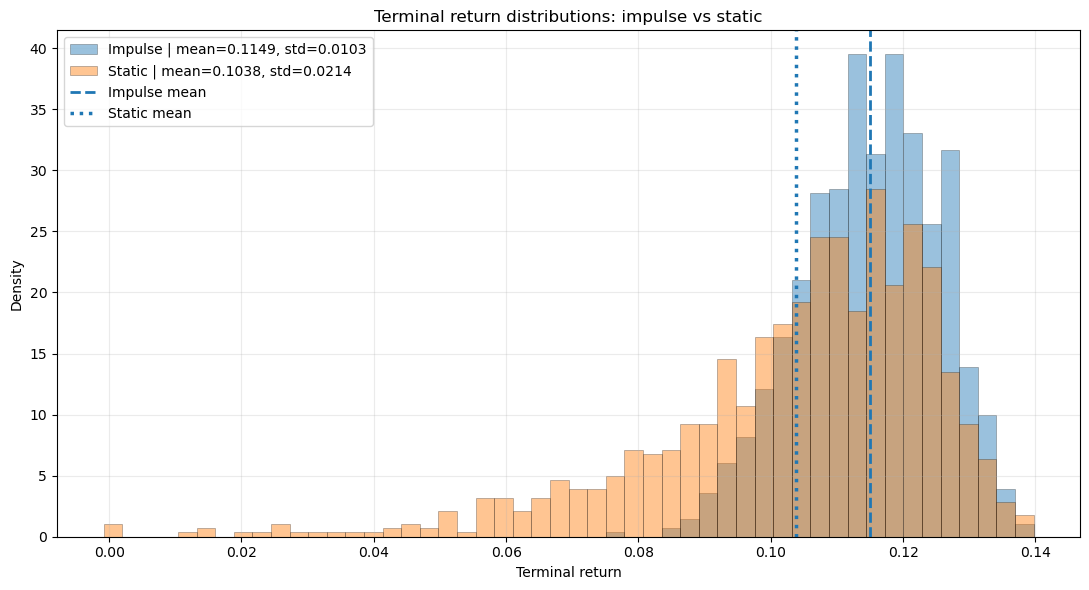

Saved figure to: impulse_sim_outputs/terminal_capital_distribution_impulse_vs_static.png


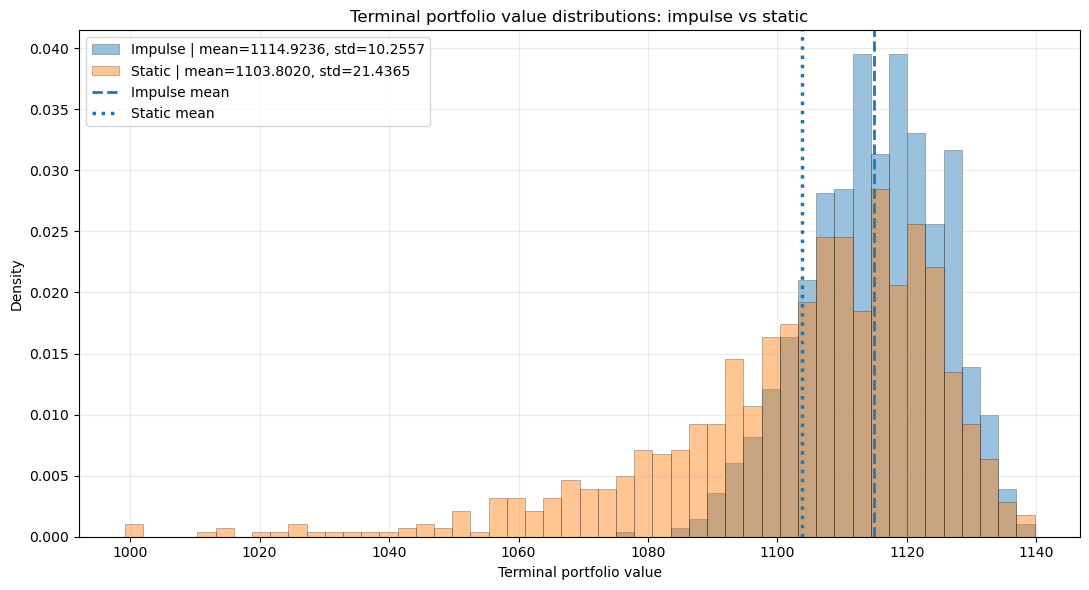

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_terminal_distribution_comparison(
    comparison_df,
    value_type="return",   # "return" или "capital"
    bins=50,
    density=True,
    alpha_impulse=0.45,
    alpha_static=0.45,
    figsize=(11, 6),
    save_path="terminal_distribution_comparison.png",
    dpi=200,
):
    """
    comparison_df должен содержать колонки:
      - impulse_terminal_return
      - static_terminal_return
      - impulse_terminal_D
      - static_terminal_D
    """

    if value_type == "return":
        x_imp = comparison_df["impulse_terminal_return"].to_numpy(float)
        x_sta = comparison_df["static_terminal_return"].to_numpy(float)
        xlabel = "Terminal return"
        title = "Terminal return distributions: impulse vs static"
    elif value_type == "capital":
        x_imp = comparison_df["impulse_terminal_D"].to_numpy(float)
        x_sta = comparison_df["static_terminal_D"].to_numpy(float)
        xlabel = "Terminal portfolio value"
        title = "Terminal portfolio value distributions: impulse vs static"
    else:
        raise ValueError("value_type must be 'return' or 'capital'")

    x_all = np.concatenate([x_imp, x_sta])
    x_min, x_max = np.min(x_all), np.max(x_all)
    bin_edges = np.linspace(x_min, x_max, bins + 1)

    mean_imp = np.mean(x_imp)
    mean_sta = np.mean(x_sta)
    std_imp = np.std(x_imp, ddof=1)
    std_sta = np.std(x_sta, ddof=1)

    plt.figure(figsize=figsize)

    plt.hist(
        x_imp,
        bins=bin_edges,
        density=density,
        alpha=alpha_impulse,
        label=f"Impulse | mean={mean_imp:.4f}, std={std_imp:.4f}",
        edgecolor="black",
        linewidth=0.4,
    )

    plt.hist(
        x_sta,
        bins=bin_edges,
        density=density,
        alpha=alpha_static,
        label=f"Static | mean={mean_sta:.4f}, std={std_sta:.4f}",
        edgecolor="black",
        linewidth=0.4,
    )

    plt.axvline(mean_imp, linestyle="--", linewidth=2, label="Impulse mean")
    plt.axvline(mean_sta, linestyle=":", linewidth=2.5, label="Static mean")

    plt.xlabel(xlabel)
    plt.ylabel("Density" if density else "Count")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()

    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure to: {save_path}")

    plt.show()


# 1) Сохранить сравнение терминальных доходностей
plot_terminal_distribution_comparison(
    comparison_df,
    value_type="return",
    bins=50,
    density=True,
    save_path="impulse_sim_outputs/terminal_return_distribution_impulse_vs_static.png",
    dpi=200,
)

# 2) Сохранить сравнение терминального капитала
plot_terminal_distribution_comparison(
    comparison_df,
    value_type="capital",
    bins=50,
    density=True,
    save_path="impulse_sim_outputs/terminal_capital_distribution_impulse_vs_static.png",
    dpi=200,
)

Loaded simulator: impulse_control_portfolio_simulator_with_static_accel.py
Numba version: 0.62.1
Model params:
ModelParams(mu=-0.3, sigma=0.2, kappa=0.015, iota=0.00375, kappa_tilde=0.545, gamma=0.05, rho=0.065, rx=0.0725, p0=2300.0, h=1.0, initial_D=1000.0, theta_F=0.01, epsilon=0.06, c_gas=10.0, c_spot=5.0, c_fut=5.0, futures_sign=-1.0)
Computed zeta = 1.5000000000
iter=001 | real_time=     1.89s | value_error=1679.83 | span_error=1.00594 | policy_changes= 120 | stable=00
iter=002 | real_time=     3.93s | value_error=1.0479 | span_error=0.509936 | policy_changes= 118 | stable=00
iter=003 | real_time=     6.19s | value_error=0.53665 | span_error=0.347568 | policy_changes=   1 | stable=00
iter=004 | real_time=     8.37s | value_error=0.366289 | span_error=0.266617 | policy_changes=   1 | stable=00
iter=005 | real_time=    10.61s | value_error=0.281128 | span_error=0.218104 | policy_changes=   0 | stable=01
iter=006 | real_time=    12.78s | value_error=0.230078 | span_error=0.185815 | p

,state_alpha,D,value,initial_alpha_star,r_L,r_U,P_L_initial,P_U_initial,iterations,final_error,final_span_error,final_policy_changes,stop_reason,solver
0,0.01,100.000000,1321.450499,0.257475,0.353682,1.000001,813.46929,2300.0023,35.0,0.061062,0.057016,0.0,policy_stability,numba_fast_operator_cost_accelerated
1,0.01,183.193277,2496.897337,0.257475,0.353682,1.000001,813.46929,2300.0023,35.0,0.061062,0.057016,0.0,policy_stability,numba_fast_operator_cost_accelerated
2,0.01,266.386555,3672.364899,0.257475,0.353682,1.000001,813.46929,2300.0023,35.0,0.061062,0.057016,0.0,policy_stability,numba_fast_operator_cost_accelerated
3,0.01,349.579832,4847.833174,0.257475,0.353682,1.000001,813.46929,2300.0023,35.0,0.061062,0.057016,0.0,policy_stability,numba_fast_operator_cost_accelerated
4,0.01,432.773109,6023.301491,0.257475,0.353682,1.000001,813.46929,2300.0023,35.0,0.061062,0.057016,0.0,policy_stability,numba_fast_operator_cost_accelerated



Static one-horizon alpha = 0.17786878

Running paired Monte Carlo: impulse vs static-myopic...
Monte Carlo finished. real_time=40.76s

Summary:


,metric,impulse,static,impulse_minus_static
0,mean_terminal_return,0.114025,0.104896,0.009129
1,variance_terminal_return,0.000112,0.000405,0.000481
2,std_terminal_return,0.010569,0.020116,0.021935
3,mean_terminal_D,1114.024625,1104.895617,9.129007
4,mean_n_rebalances,0.157000,2.059000,-1.902000
5,impulse_win_rate,0.590000,0.410000,0.180000



Impulse-control portfolio:
mean terminal return     = 0.11402462
variance terminal return = 0.00011170
mean terminal D          = 1114.02462460
mean n_rebalances        = 0.1570

Static-myopic portfolio:
mean terminal return     = 0.10489562
variance terminal return = 0.00040465
mean terminal D          = 1104.89561715
mean n_rebalances        = 2.0590

Paired comparison:
mean impulse - static    = 0.00912901
variance diff            = 0.00048116
impulse win rate         = 0.5900

Saved:
MC returns: impulse_sim_outputs\mc_terminal_returns.csv
MC summary: impulse_sim_outputs\mc_comparison_summary.csv

Saved plots:
impulse_sim_outputs\alpha_policy_vs_D.png
impulse_sim_outputs\static_alpha_policy_vs_D.png
impulse_sim_outputs\terminal_return_comparison.png


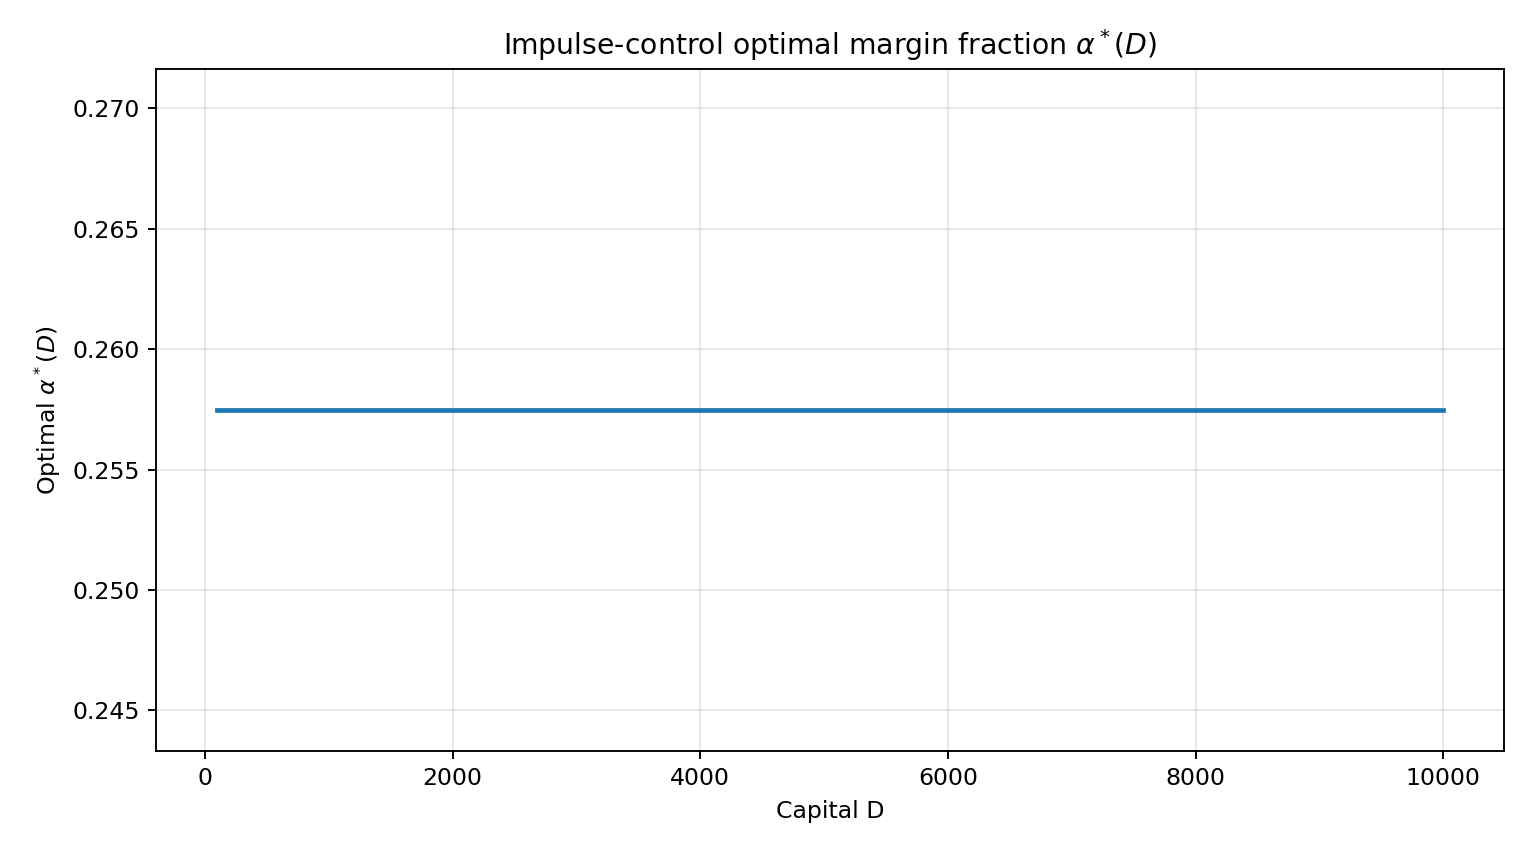

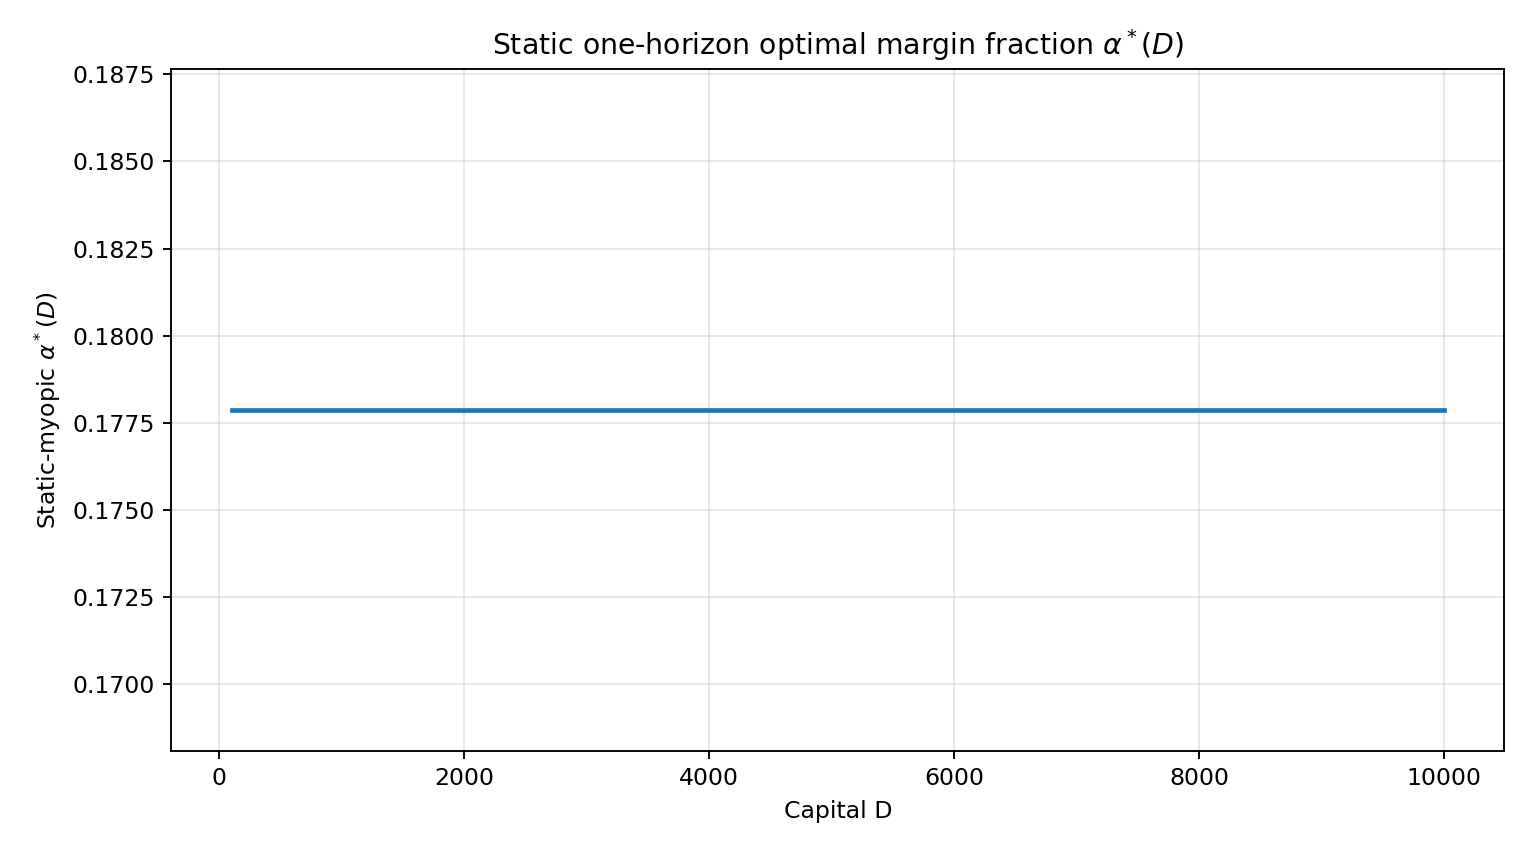

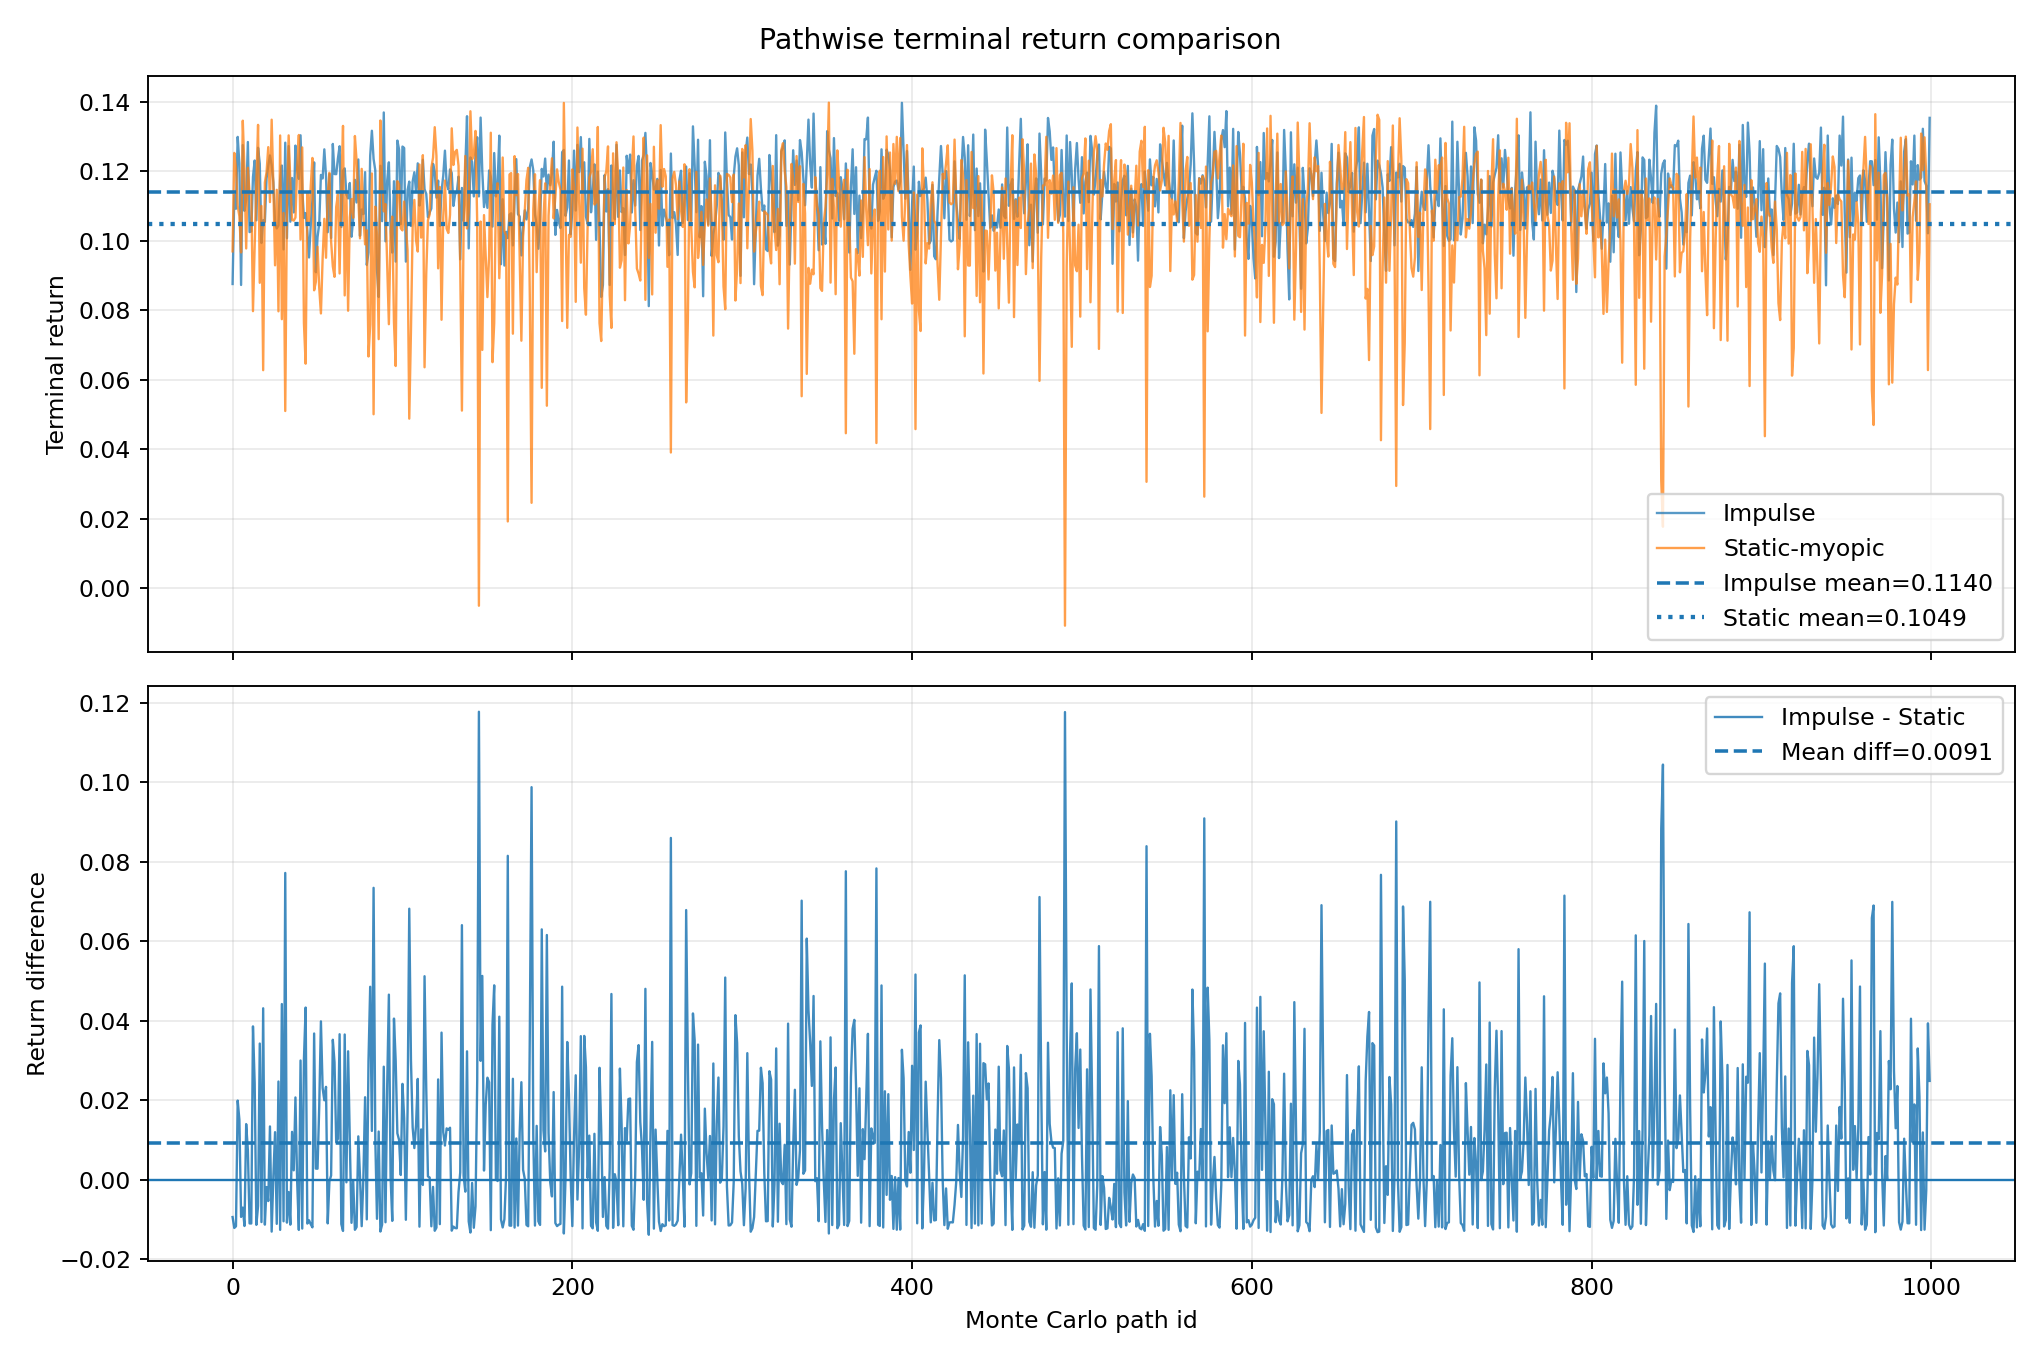


Searching sample path with impulse n_rebalances in [4, 5, 6]...
Search finished. real_time=5.33s
sample seed                  = 10002802
impulse n_rebalances         = 3
static n_rebalances          = 18
impulse terminal return      = 0.11478116
static terminal return       = -0.02290363

Representative path plots:
impulse_sim_outputs\sample_impulse_portfolio_path_target_rebalances.png
impulse_sim_outputs\sample_static_portfolio_path_same_price.png
impulse_sim_outputs\sample_impulse_vs_static_same_price_target_rebalances.png
impulse_sim_outputs\sample_price_band_path_target_rebalances.png


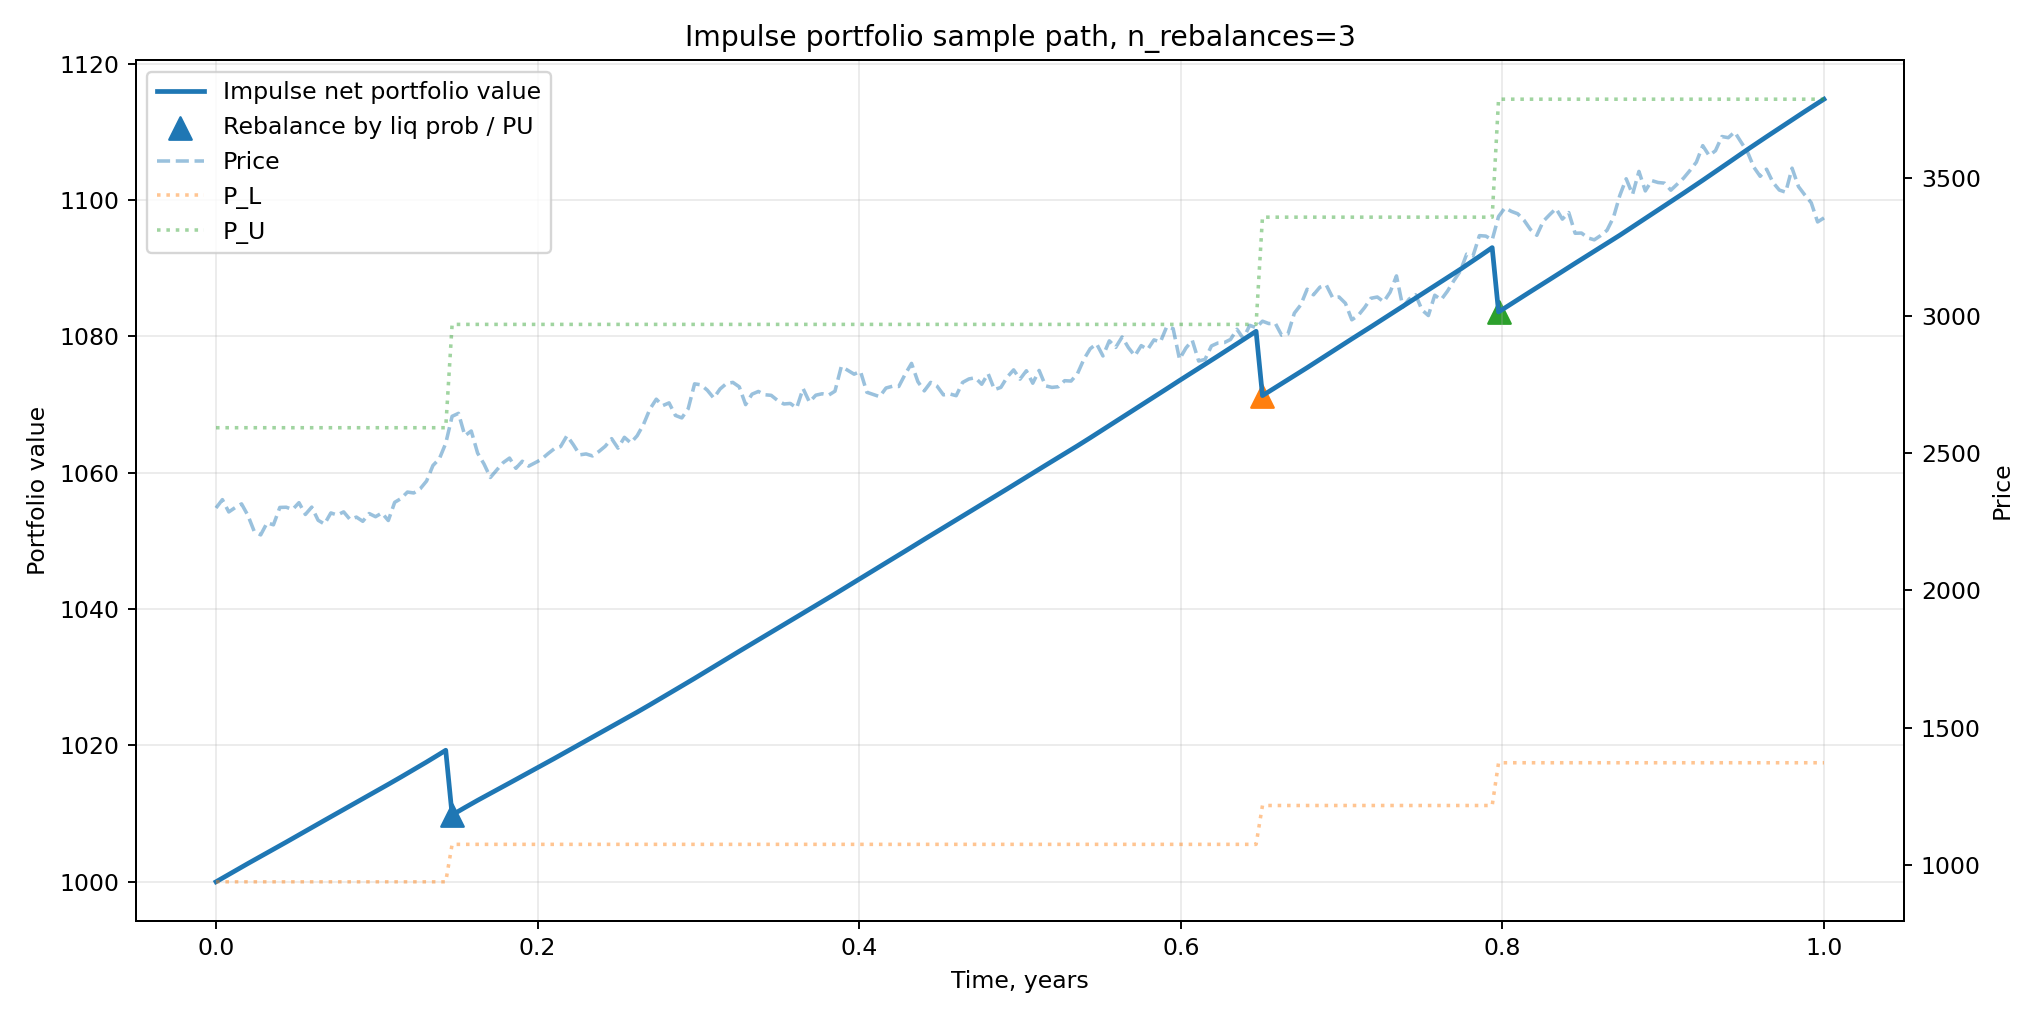

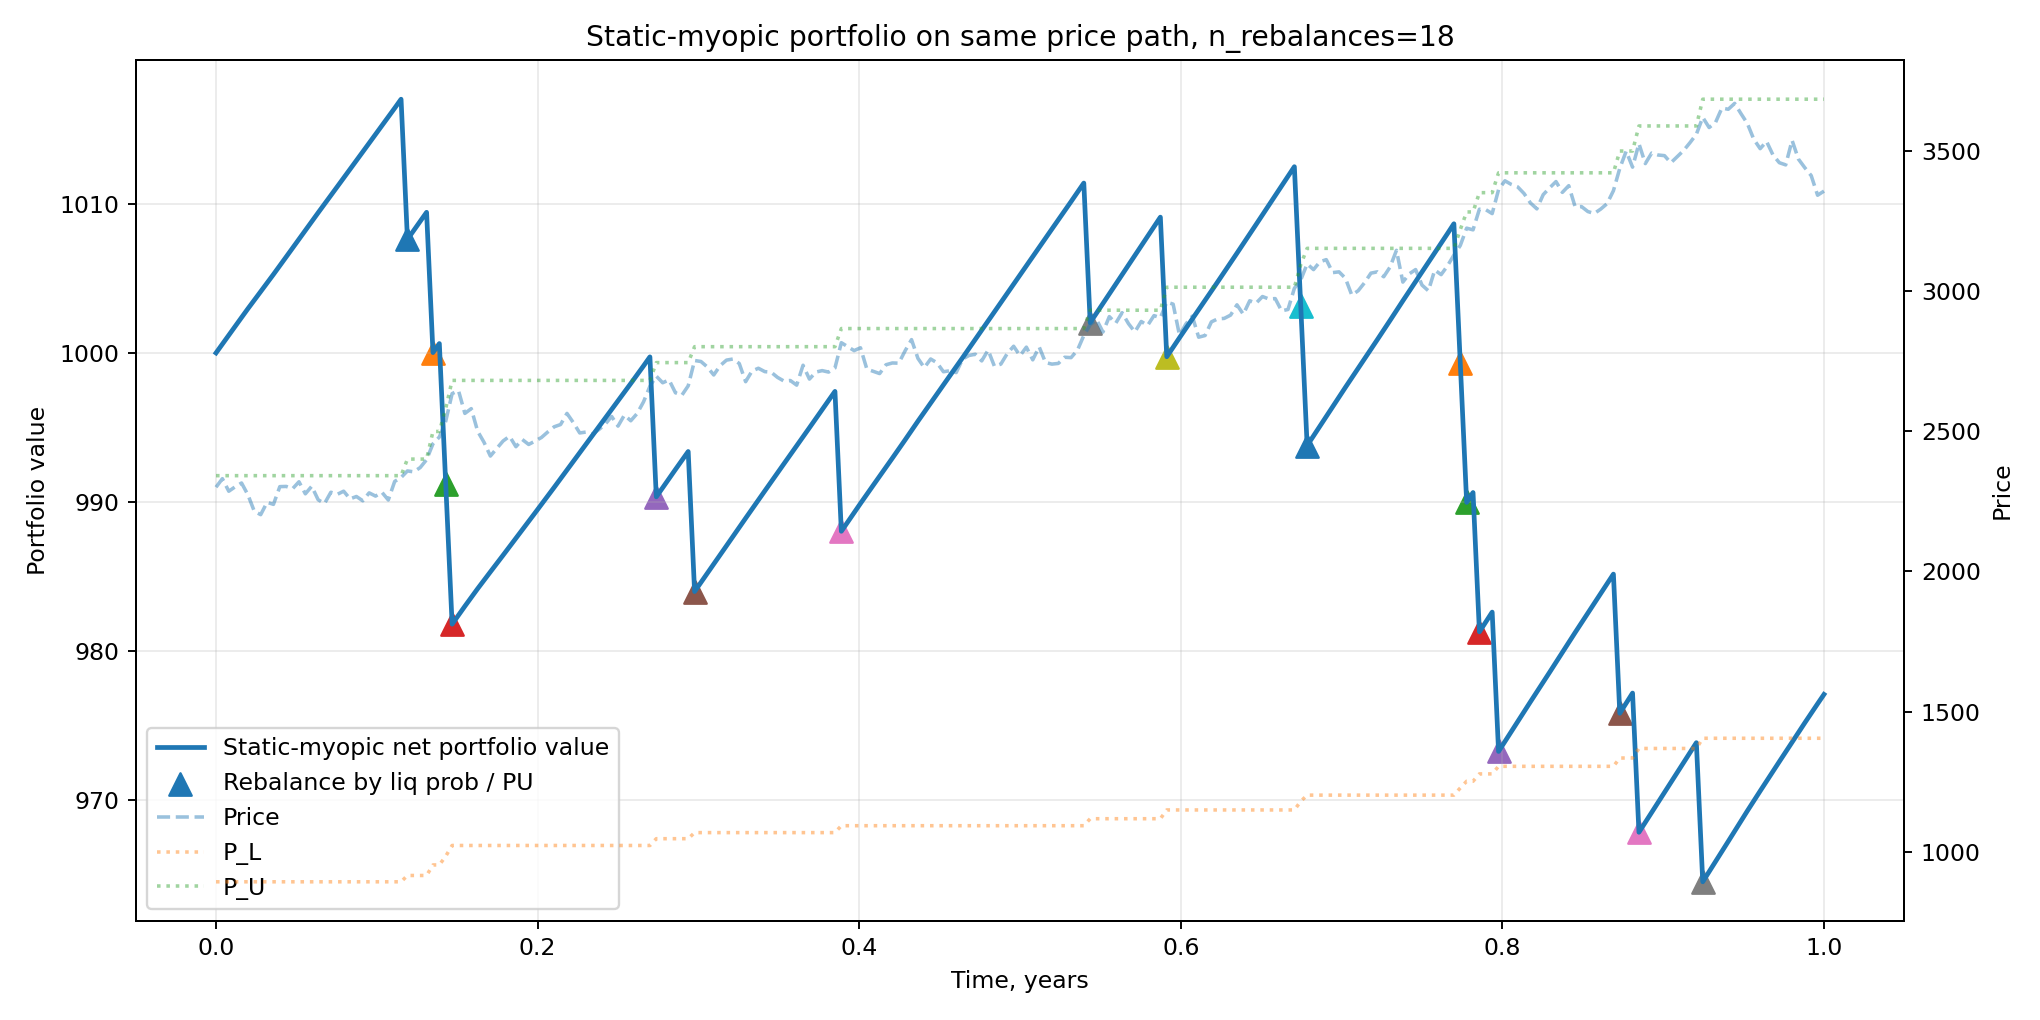

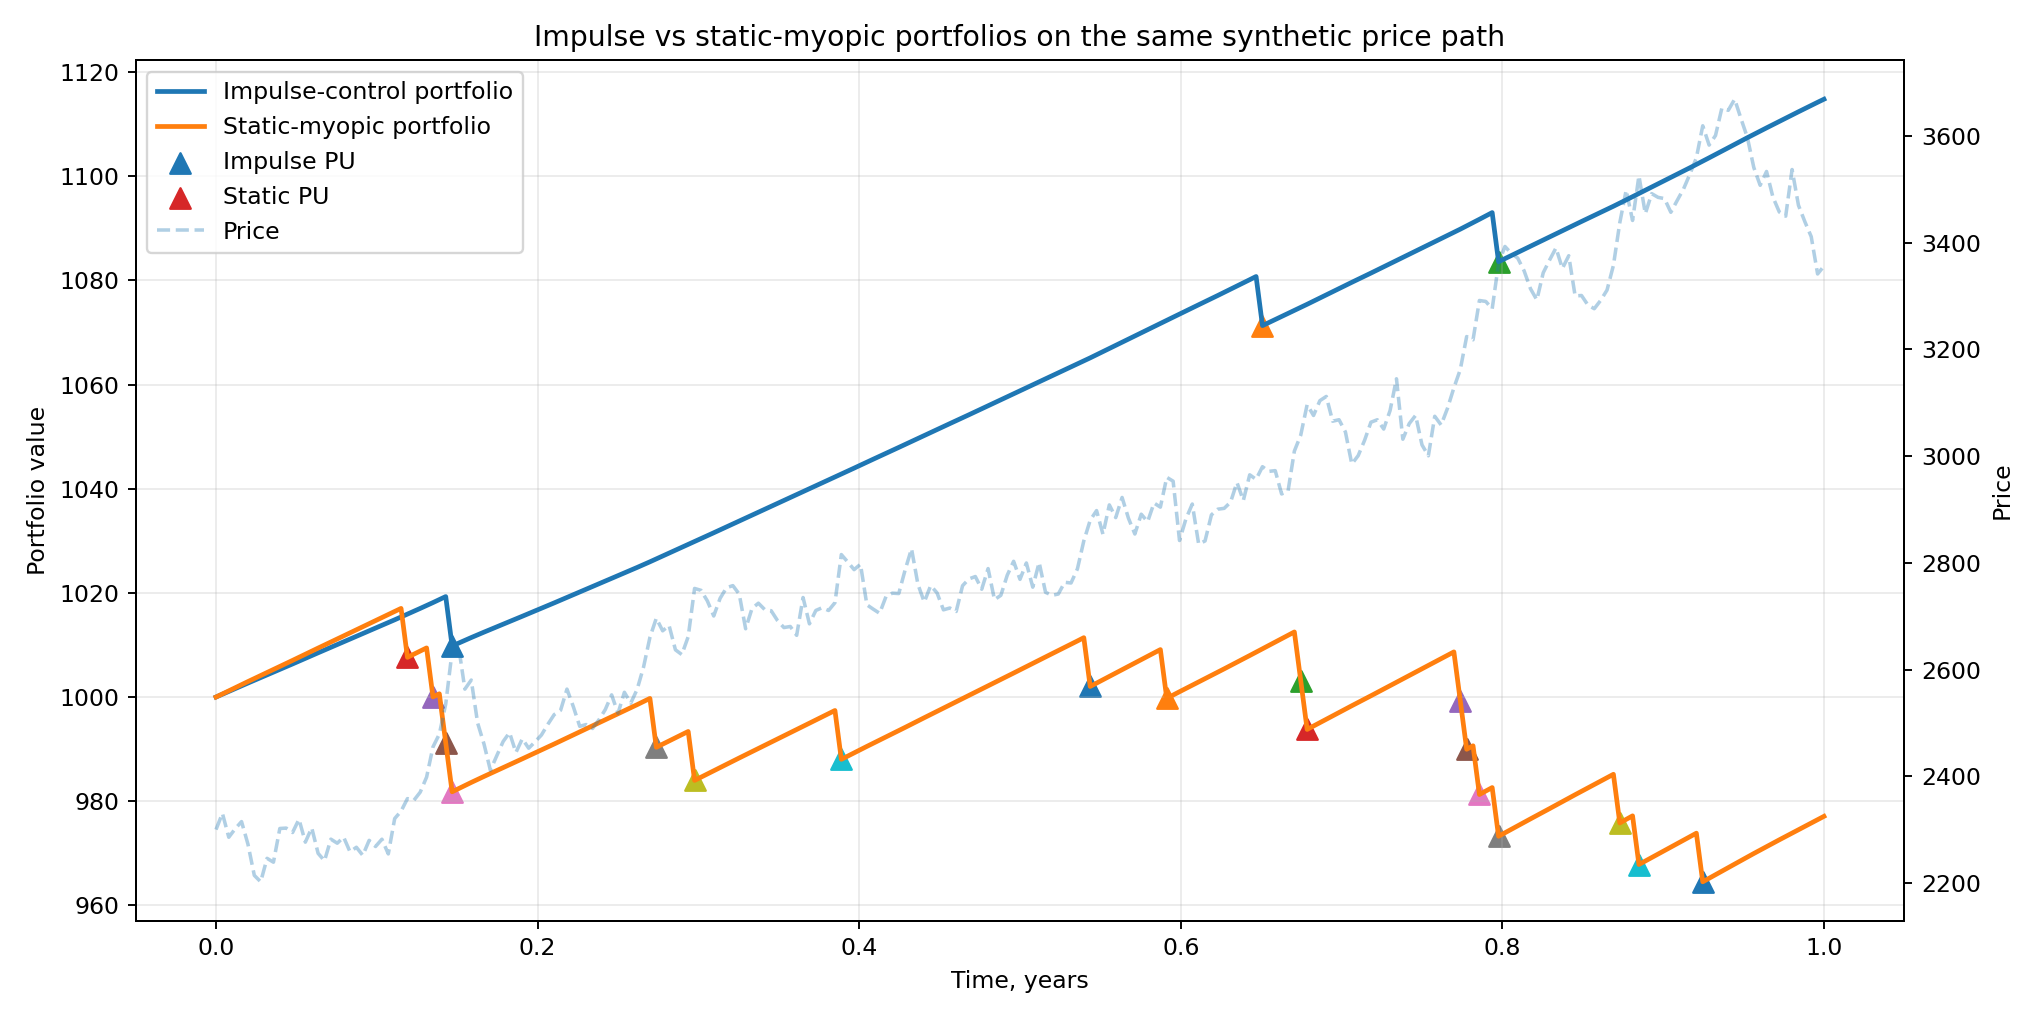

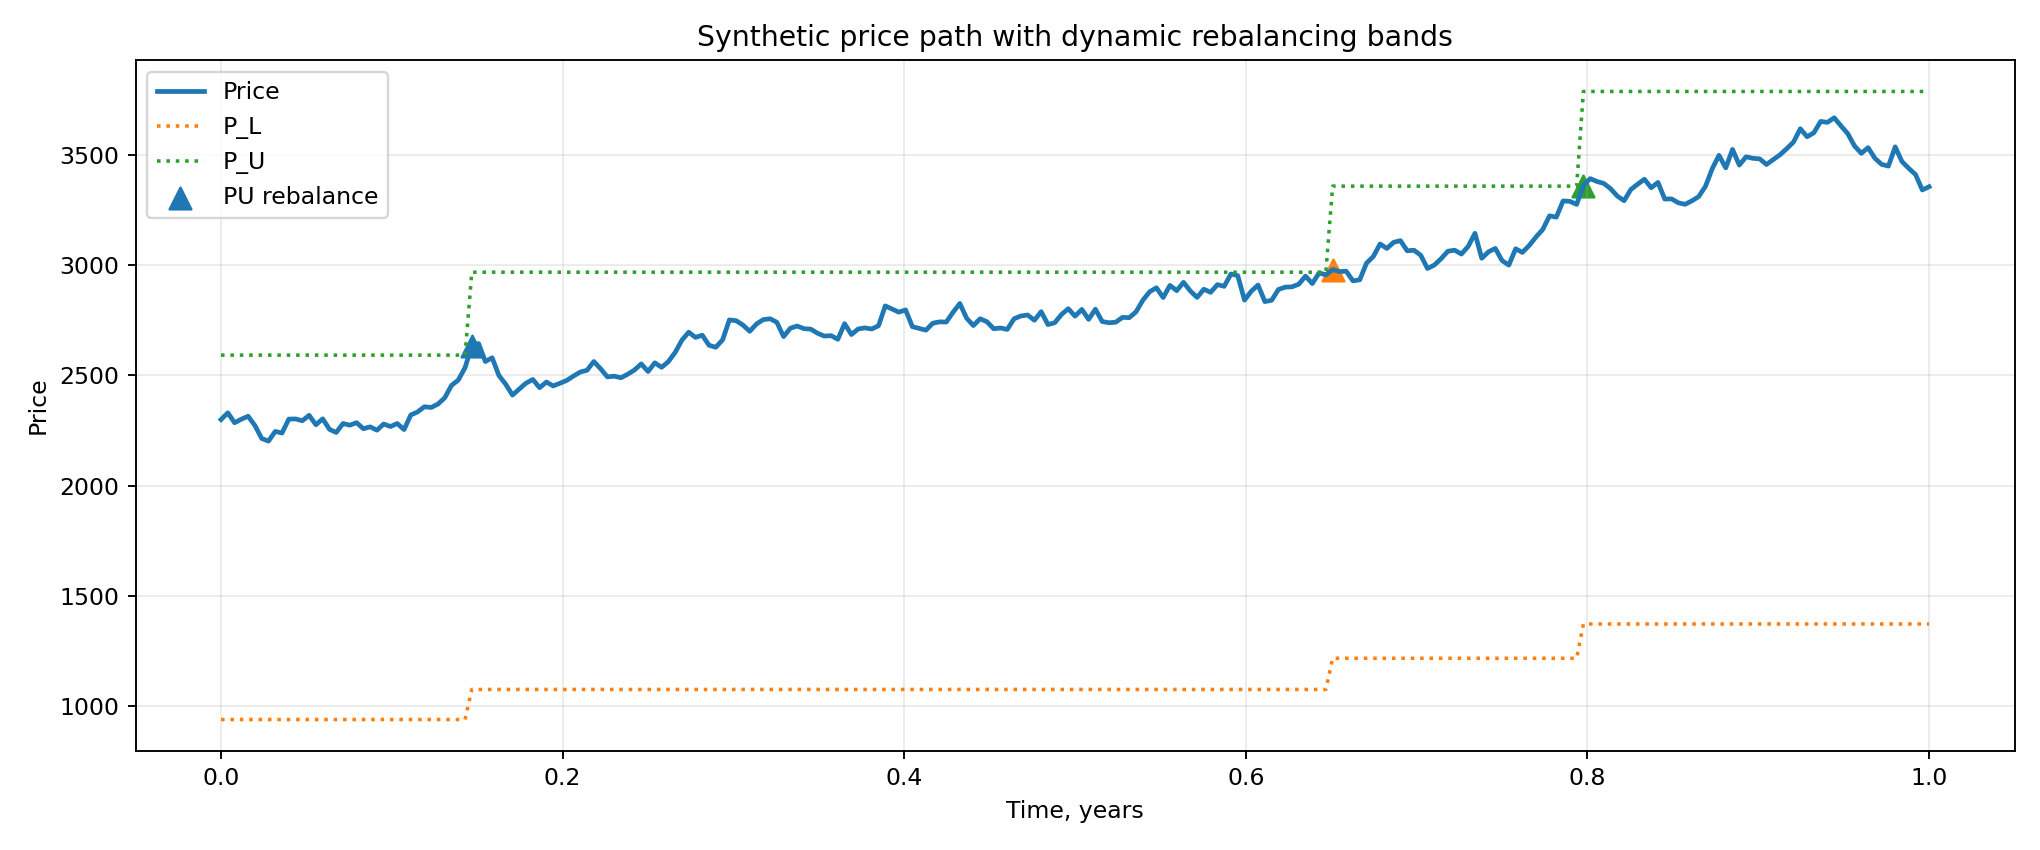


Impulse rebalance events:


,alpha,D_before,D_after,cost,Q,H,P_L,P_U,time,price,trigger,old_alpha,old_P_L,old_P_U,portfolio_before_cost,portfolio_net_after_rebalance
0,0.257475,1019.893793,1019.893793,10.092980,0.287534,-0.191689,1075.603388,2968.387086,0.146825,2633.763970,PU,0.257475,939.297454,2592.217972,1019.893793,1009.800814
1,0.257475,1091.448535,1091.448535,10.046454,0.271946,-0.181297,1217.045523,3358.730788,0.650794,2980.104642,PU,0.257475,1075.603388,2968.387086,1091.448535,1071.309102
2,0.257475,1113.802451,1113.802451,10.087023,0.246055,-0.164037,1372.656250,3788.176135,0.797619,3361.139073,PU,0.257475,1217.045523,3358.730788,1113.802451,1083.575995



Static-myopic rebalance events:


,alpha,D_before,D_after,cost,Q,H,P_L,P_U,time,price,trigger,old_alpha,old_P_L,old_P_U,portfolio_before_cost,portfolio_net_after_rebalance
0,0.177869,1017.623213,1017.623213,10.006263,0.354792,-0.236528,915.196446,2400.312250,0.119048,2358.055218,PU,0.177869,892.664348,2341.216666,1017.623213,1007.616950
1,0.177869,1020.060598,1020.060598,10.032347,0.341616,-0.227744,952.773813,2498.867502,0.134921,2454.875423,PU,0.177869,915.196446,2400.312250,1020.060598,1000.021988
2,0.177869,1021.285576,1021.285576,10.026500,0.331164,-0.220776,984.024834,2580.830460,0.142857,2535.395440,PU,0.177869,952.773813,2498.867502,1021.285576,991.220466
3,0.177869,1021.902607,1021.902607,10.032069,0.318988,-0.212658,1022.203130,2680.961783,0.146825,2633.763970,PU,0.177869,984.024834,2580.830460,1021.902607,981.805428
4,0.177869,1040.449000,1040.449000,10.004643,0.317266,-0.211510,1046.403617,2744.433102,0.273810,2696.117889,PU,0.177869,1022.203130,2680.961783,1040.449000,990.347179
5,0.177869,1044.109762,1044.109762,10.014696,0.311925,-0.207950,1068.062881,2801.239483,0.297619,2751.924204,PU,0.177869,1046.403617,2744.433102,1044.109762,983.993245
6,0.177869,1058.159909,1058.159909,10.008262,0.308991,-0.205994,1092.715879,2865.897616,0.388889,2815.444043,PU,0.177869,1068.062881,2801.239483,1058.159909,988.035129
7,0.177869,1082.156167,1082.156167,10.000126,0.308947,-0.205965,1117.654595,2931.305109,0.543651,2879.700050,PU,0.177869,1092.715879,2865.897616,1082.156167,1002.031261
8,0.177869,1089.886559,1089.886559,10.018531,0.302687,-0.201791,1148.917650,3013.299630,0.591270,2960.251073,PU,0.177869,1117.654595,2931.305109,1089.886559,999.743122
9,0.177869,1103.296343,1103.296343,10.012929,0.298433,-0.198955,1179.632083,3093.855262,0.674603,3039.388539,PU,0.177869,1148.917650,3013.299630,1103.296343,1003.139977


In [1]:
# ============================================================
# Jupyter one-cell launcher for accelerated impulse simulator
# ============================================================

import sys
import time
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ------------------------------------------------------------
# 1. Path to accelerated simulator
# ------------------------------------------------------------
SIMULATOR_PY = Path("impulse_control_portfolio_simulator_with_static_accel.py")

if not SIMULATOR_PY.exists():
    raise FileNotFoundError(f"Simulator file not found: {SIMULATOR_PY}")

spec = importlib.util.spec_from_file_location("impulse_sim_accel", SIMULATOR_PY)
impulse_sim = importlib.util.module_from_spec(spec)
sys.modules["impulse_sim_accel"] = impulse_sim
spec.loader.exec_module(impulse_sim)

print("Loaded simulator:", SIMULATOR_PY)

# Optional: check numba
try:
    import numba
    print("Numba version:", numba.__version__)
except Exception as e:
    print("Numba is not available:", e)

# ------------------------------------------------------------
# 2. USER PARAMETERS
# ------------------------------------------------------------
params = impulse_sim.ModelParams(
    mu=-0.3,
    sigma=0.2,
    kappa=0.015,
    iota=0.00375,
    kappa_tilde=0.545,
    gamma=0.05,
    rho=0.065,
    rx=0.0725,
    p0=2300.0,
    h=1.0,
    initial_D=1000.0,
    theta_F=0.0100,
    epsilon=0.06,

    # Rebalancing costs
    c_gas=10.0,
    c_spot=5.0,
    c_fut=5.0,

    # Futures convention
    # -1.0 = short futures convention from PuPl.txt
    # +1.0 = H = +Q / zeta
    futures_sign=-1.0,
)

print("Model params:")
print(params)
print(f"Computed zeta = {params.zeta:.10f}")

# ------------------------------------------------------------
# 3. POLICY TABLE CONFIG
# ------------------------------------------------------------
# Для финального запуска:
# n_d=120, n_alpha=71, n_episode_mc=2000.
#
# Для быстрой отладки:
# n_d=40, n_alpha=31, n_episode_mc=500.

table_cfg = impulse_sim.TableConfig(
    d_min=100.0,
    d_max=10_000.0,
    n_d=120,
    alpha_min=0.01,
    alpha_max=0.99,
    n_alpha=100,

    # Monte Carlo inside Bellman/value iteration
    n_episode_mc=2000,
    dt_episode=1.0 / 252.0,
    max_episode_time=2.0,

    # Bellman iteration
    max_iter=200,
    tol=1e-4,

    # Important for accelerated version
    relaxation=1.0,
    min_iter=10,
    stop_on_span_error=True,
    stop_on_policy_stability=True,
    policy_stable_iters=8,

    # If you want to continue from existing CSV, set path here
    # Example:
    # warm_start_csv="impulse_sim_outputs/alpha_policy_table_accel.csv",
    warm_start_csv=None,

    seed=42,
    n_jobs=-1,
    parallel_backend="threads",

    policy_csv="impulse_sim_outputs/alpha_policy_table_accel.csv",
)

# ------------------------------------------------------------
# 4. SIMULATION CONFIG
# ------------------------------------------------------------
sim_cfg = impulse_sim.SimulationConfig(
    n_paths=1000,
    simulation_years=1.0,
    dt=1.0 / 252.0,
    seed=777,

    n_jobs=-1,
    parallel_backend="threads",

    # False = convention 2:
    # K is subtracted in the intervention operator / cost ledger.
    # True = cash-account convention:
    # cost reduces capital before next position is opened.
    apply_cost_to_cash=False,

    output_dir="impulse_sim_outputs",
)

# ------------------------------------------------------------
# 5. RUN SWITCHES
# ------------------------------------------------------------
FORCE_RECOMPUTE_POLICY = True

# Для показательного графика ищем траекторию, где impulse делает 4-6 ребалансировок.
TARGET_REBALANCES = {4, 5, 6}
MAX_SAMPLE_SEARCH = 5000

out_dir = Path(sim_cfg.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 6. Build / load impulse policy table
# ------------------------------------------------------------
t0 = time.perf_counter()

policy_df = impulse_sim.build_or_load_policy_table(
    params=params,
    table_cfg=table_cfg,
    force_recompute=FORCE_RECOMPUTE_POLICY,
)

print(f"\nPolicy table ready. real_time={time.perf_counter() - t0:.2f}s")
display(policy_df.head())

policy = impulse_sim.AlphaPolicy(policy_df)
bounds = impulse_sim.RebalancingBounds(params)

# ------------------------------------------------------------
# 7. Static-myopic alpha: computed once
# ------------------------------------------------------------
static_optimizer = impulse_sim.StaticAlphaOptimizer(
    params=params,
    alpha_min=table_cfg.alpha_min,
    alpha_max=table_cfg.alpha_max,
)

static_alpha = static_optimizer.optimal_alpha(params.initial_D, p0=params.p0)
print(f"\nStatic one-horizon alpha = {static_alpha:.8f}")

# ------------------------------------------------------------
# 8. Paired Monte Carlo: impulse vs static on same synthetic paths
# ------------------------------------------------------------
print("\nRunning paired Monte Carlo: impulse vs static-myopic...")

t0 = time.perf_counter()

comparison_df = impulse_sim.run_parallel_monte_carlo_comparison(
    params=params,
    sim_cfg=sim_cfg,
    policy_df=policy_df,
    alpha_min=table_cfg.alpha_min,
    alpha_max=table_cfg.alpha_max,
    static_alpha=static_alpha,
)

mc_time = time.perf_counter() - t0

comparison_csv = out_dir / "mc_terminal_returns.csv"
comparison_df.to_csv(comparison_csv, index=False)

summary_df = impulse_sim.summarize_comparison(comparison_df)
summary_csv = out_dir / "mc_comparison_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print(f"Monte Carlo finished. real_time={mc_time:.2f}s")

print("\nSummary:")
display(summary_df)

print("\nImpulse-control portfolio:")
print(f"mean terminal return     = {comparison_df['impulse_terminal_return'].mean():.8f}")
print(f"variance terminal return = {comparison_df['impulse_terminal_return'].var(ddof=1):.8f}")
print(f"mean terminal D          = {comparison_df['impulse_terminal_D'].mean():.8f}")
print(f"mean n_rebalances        = {comparison_df['impulse_n_rebalances'].mean():.4f}")

print("\nStatic-myopic portfolio:")
print(f"mean terminal return     = {comparison_df['static_terminal_return'].mean():.8f}")
print(f"variance terminal return = {comparison_df['static_terminal_return'].var(ddof=1):.8f}")
print(f"mean terminal D          = {comparison_df['static_terminal_D'].mean():.8f}")
print(f"mean n_rebalances        = {comparison_df['static_n_rebalances'].mean():.4f}")

print("\nPaired comparison:")
print(f"mean impulse - static    = {comparison_df['impulse_minus_static_return'].mean():.8f}")
print(f"variance diff            = {comparison_df['impulse_minus_static_return'].var(ddof=1):.8f}")
print(f"impulse win rate         = {comparison_df['impulse_wins'].mean():.4f}")

print("\nSaved:")
print("MC returns:", comparison_csv)
print("MC summary:", summary_csv)

# ------------------------------------------------------------
# 9. Basic plots: alpha*(D), static alpha(D), terminal comparison
# ------------------------------------------------------------
alpha_plot = out_dir / "alpha_policy_vs_D.png"
static_alpha_plot = out_dir / "static_alpha_policy_vs_D.png"
return_comparison_plot = out_dir / "terminal_return_comparison.png"

impulse_sim.plot_alpha_policy(policy_df, alpha_plot)

static_policy_df = static_optimizer.policy_table(
    np.array(sorted(policy_df["D"].unique()), dtype=float),
    p0=params.p0,
)
impulse_sim.plot_static_alpha_policy(static_policy_df, static_alpha_plot)

impulse_sim.plot_terminal_return_comparison(comparison_df, return_comparison_plot)

print("\nSaved plots:")
print(alpha_plot)
print(static_alpha_plot)
print(return_comparison_plot)

display(Image(filename=str(alpha_plot)))
display(Image(filename=str(static_alpha_plot)))
display(Image(filename=str(return_comparison_plot)))

# ------------------------------------------------------------
# 10. Find one path where impulse has 4-6 rebalances
# ------------------------------------------------------------
def find_sample_path_with_target_rebalances(
    params,
    sim_cfg,
    policy,
    static_optimizer,
    bounds,
    target_rebalances={4, 5, 6},
    max_search=5000,
    base_seed=10_000_000,
):
    """
    Ищем synthetic price path, на котором impulse-control делает 4-6 ребалансировок.
    Если не нашли ровно 4-6, берём путь с числом ребалансировок,
    ближайшим к середине target_rebalances.
    """
    target_mid = np.mean(list(target_rebalances))
    best = None
    best_distance = np.inf

    for i in range(max_search):
        seed = base_seed + i
        rng = np.random.default_rng(seed)

        times, prices = impulse_sim.generate_synthetic_price_path(
            params=params,
            sim_cfg=sim_cfg,
            rng=rng,
            p0=params.p0,
        )

        impulse_sample = impulse_sim.run_portfolio_on_price_path(
            prices=prices,
            times=times,
            params=params,
            policy=policy,
            bounds=bounds,
            apply_cost_to_cash=sim_cfg.apply_cost_to_cash,
        )

        n_reb = int(impulse_sample["n_rebalances"])
        distance = abs(n_reb - target_mid)

        if distance < best_distance:
            static_sample = impulse_sim.run_static_portfolio_on_price_path(
                prices=prices,
                times=times,
                params=params,
                static_optimizer=static_optimizer,
                bounds=bounds,
                apply_cost_to_cash=sim_cfg.apply_cost_to_cash,
            )
            best = {
                "seed": seed,
                "times": times,
                "prices": prices,
                "impulse": impulse_sample,
                "static": static_sample,
                "impulse_n_rebalances": n_reb,
                "static_n_rebalances": int(static_sample["n_rebalances"]),
            }
            best_distance = distance

        if n_reb in target_rebalances:
            static_sample = impulse_sim.run_static_portfolio_on_price_path(
                prices=prices,
                times=times,
                params=params,
                static_optimizer=static_optimizer,
                bounds=bounds,
                apply_cost_to_cash=sim_cfg.apply_cost_to_cash,
            )
            return {
                "seed": seed,
                "times": times,
                "prices": prices,
                "impulse": impulse_sample,
                "static": static_sample,
                "impulse_n_rebalances": n_reb,
                "static_n_rebalances": int(static_sample["n_rebalances"]),
            }

    return best


print(f"\nSearching sample path with impulse n_rebalances in {sorted(TARGET_REBALANCES)}...")

t0 = time.perf_counter()

sample_pack = find_sample_path_with_target_rebalances(
    params=params,
    sim_cfg=sim_cfg,
    policy=policy,
    static_optimizer=static_optimizer,
    bounds=bounds,
    target_rebalances=TARGET_REBALANCES,
    max_search=MAX_SAMPLE_SEARCH,
)

print(f"Search finished. real_time={time.perf_counter() - t0:.2f}s")
print(f"sample seed                  = {sample_pack['seed']}")
print(f"impulse n_rebalances         = {sample_pack['impulse_n_rebalances']}")
print(f"static n_rebalances          = {sample_pack['static_n_rebalances']}")
print(f"impulse terminal return      = {sample_pack['impulse']['terminal_return']:.8f}")
print(f"static terminal return       = {sample_pack['static']['terminal_return']:.8f}")

# ------------------------------------------------------------
# 11. Representative path visualizations
# ------------------------------------------------------------
impulse_sample_path = out_dir / "sample_impulse_portfolio_path_target_rebalances.png"
static_sample_path = out_dir / "sample_static_portfolio_path_same_price.png"
combined_sample_path = out_dir / "sample_impulse_vs_static_same_price_target_rebalances.png"
price_band_path = out_dir / "sample_price_band_path_target_rebalances.png"

impulse_sim.plot_sample_portfolio_path(
    sample_pack["impulse"],
    impulse_sample_path,
    title=f"Impulse portfolio sample path, n_rebalances={sample_pack['impulse_n_rebalances']}",
    portfolio_label="Impulse net portfolio value",
)

impulse_sim.plot_sample_portfolio_path(
    sample_pack["static"],
    static_sample_path,
    title=f"Static-myopic portfolio on same price path, n_rebalances={sample_pack['static_n_rebalances']}",
    portfolio_label="Static-myopic net portfolio value",
)

impulse_sim.plot_combined_portfolio_paths(
    sample_pack["impulse"],
    sample_pack["static"],
    combined_sample_path,
)

impulse_sim.plot_price_band_path(
    sample_pack["impulse"],
    price_band_path,
)

print("\nRepresentative path plots:")
print(impulse_sample_path)
print(static_sample_path)
print(combined_sample_path)
print(price_band_path)

display(Image(filename=str(impulse_sample_path)))
display(Image(filename=str(static_sample_path)))
display(Image(filename=str(combined_sample_path)))
display(Image(filename=str(price_band_path)))

# ------------------------------------------------------------
# 12. Rebalance event tables
# ------------------------------------------------------------
impulse_events = pd.DataFrame(sample_pack["impulse"]["rebalance_events"])
static_events = pd.DataFrame(sample_pack["static"]["rebalance_events"])

print("\nImpulse rebalance events:")
display(impulse_events)

print("\nStatic-myopic rebalance events:")
display(static_events)

,D,old_alpha,P_L,P_U,alpha_rebalance_PL,alpha_rebalance_PU,second_output_PL,second_output_PU,cost_PL,cost_U,gas_over_D
0,100.000000,0.257475,0.40839,1.127051,0.257475,0.257475,1380.324360,1380.358855,10.043929,10.009434,0.100000
1,166.442953,0.257475,0.40839,1.127051,0.257475,0.257475,2359.466699,2359.524113,10.073116,10.015702,0.060081
2,232.885906,0.257475,0.40839,1.127051,0.257475,0.257475,3338.618544,3338.698877,10.102303,10.021970,0.042939
3,299.328859,0.257475,0.40839,1.127051,0.257475,0.257475,4317.773772,4317.877024,10.131491,10.028238,0.033408
4,365.771812,0.257475,0.40839,1.127051,0.257475,0.257475,5296.929197,5297.055368,10.160678,10.034506,0.027339


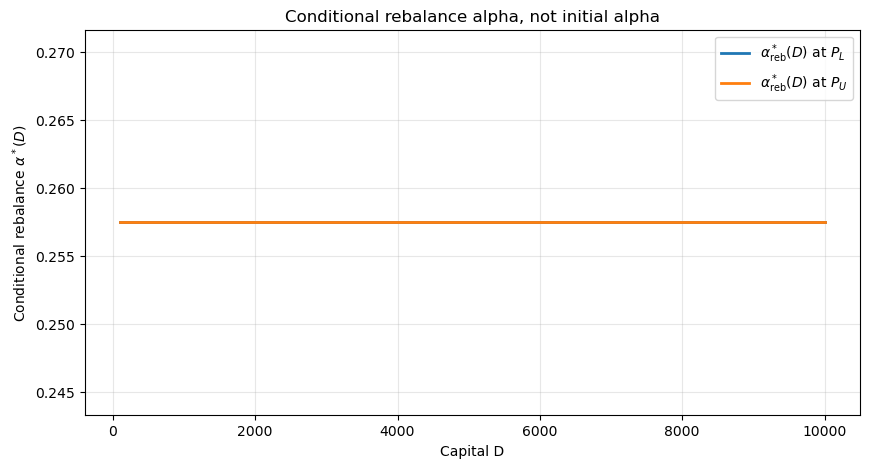

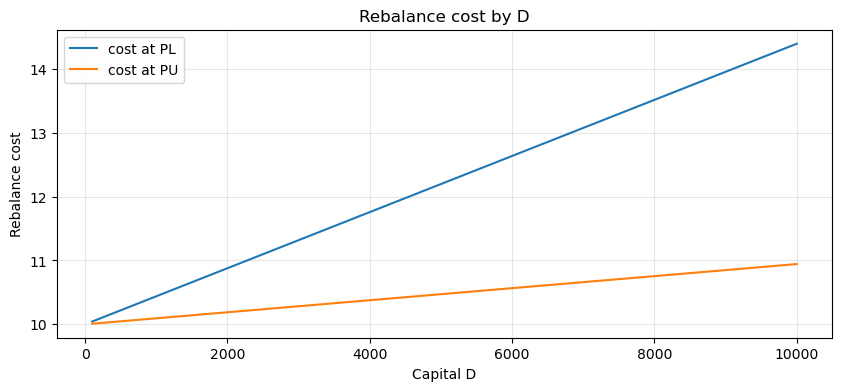

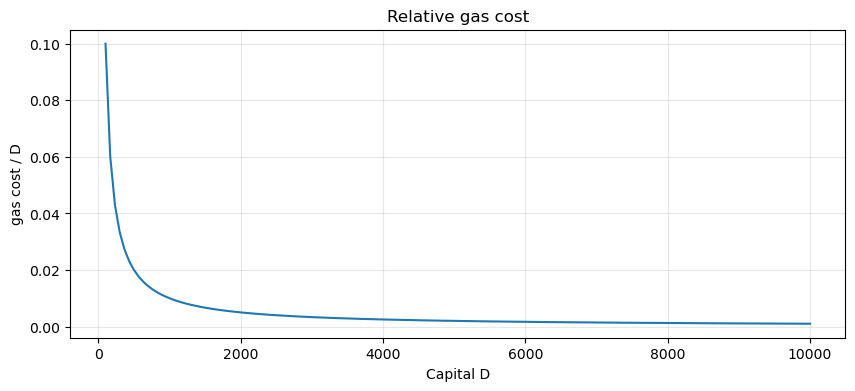

In [3]:
def get_initial_alpha_from_policy(policy, D):
    """
    Robust helper: supports different simulator versions.
    """
    if hasattr(policy, "alpha"):
        return float(policy.alpha(D))

    if hasattr(policy, "initial_alpha"):
        return float(policy.initial_alpha(D))

    # fallback if policy stores the original dataframe
    if hasattr(policy, "df"):
        df = policy.df.copy()

        if "initial_alpha_star" in df.columns:
            tmp = df[["D", "initial_alpha_star"]].drop_duplicates("D").sort_values("D")
            return float(np.interp(D, tmp["D"], tmp["initial_alpha_star"]))

        if "alpha_star" in df.columns:
            tmp = df[["D", "alpha_star"]].drop_duplicates("D").sort_values("D")
            return float(np.interp(D, tmp["D"], tmp["alpha_star"]))

    raise AttributeError(
        "Cannot infer initial alpha. Policy has neither alpha(D), "
        "initial_alpha(D), nor suitable columns in policy.df."
    )


def get_fixed_gas_cost(params):
    """
    Robust helper for different parameter naming conventions.
    """
    if hasattr(params, "c_gas"):
        return float(params.c_gas)
    if hasattr(params, "fixed_dollar_cost"):
        return float(params.fixed_dollar_cost)
    return np.nan


def compute_rebalance_alpha_curves(
    impulse_sim,
    policy,
    params,
    D_grid,
    old_alpha_mode="initial",
):
    """
    Computes conditional rebalance alpha at PL and PU.

    This is different from initial_alpha_star.
    It asks: given old alpha and an exit through PL/PU,
    which alpha_new would the intervention operator choose?
    """
    bounds = impulse_sim.RebalancingBounds(params)
    rows = []

    for D in D_grid:
        D = float(D)

        if old_alpha_mode == "initial":
            old_alpha = get_initial_alpha_from_policy(policy, D)
        else:
            old_alpha = float(old_alpha_mode)

        p0 = 1.0
        zeta = float(params.zeta)

        Q0 = (1.0 - old_alpha) * D / p0
        H0 = params.futures_sign * (1.0 - old_alpha) * D / (zeta * p0)

        P_L, P_U = bounds.price_band(p0, old_alpha)

        old_state = impulse_sim.PositionState(
            D_entry=D,
            p_entry=p0,
            alpha=old_alpha,
            Q=Q0,
            H=H0,
            P_L=P_L,
            P_U=P_U,
            integral_price=0.0,
        )

        # Diagnostic approximation:
        # at the boundary we use D_before ~= D.
        # This is enough to inspect how the intervention operator maps D -> alpha_new.
        D_before_L = D
        D_before_U = D

        out_L = policy.next_alpha(
            D_before=D_before_L,
            p=P_L,
            old_state=old_state,
            params=params,
        )

        out_U = policy.next_alpha(
            D_before=D_before_U,
            p=P_U,
            old_state=old_state,
            params=params,
        )

        # Different simulator versions return:
        #   convention 2: (alpha_new, value_score, cost)
        #   gamma-cost:  (alpha_new, D_after_cost, cost)
        alpha_L = float(out_L[0])
        alpha_U = float(out_U[0])

        second_L = float(out_L[1])
        second_U = float(out_U[1])

        cost_L = float(out_L[2]) if len(out_L) >= 3 else np.nan
        cost_U = float(out_U[2]) if len(out_U) >= 3 else np.nan

        rows.append(
            {
                "D": D,
                "old_alpha": old_alpha,
                "P_L": P_L,
                "P_U": P_U,
                "alpha_rebalance_PL": alpha_L,
                "alpha_rebalance_PU": alpha_U,
                "second_output_PL": second_L,
                "second_output_PU": second_U,
                "cost_PL": cost_L,
                "cost_U": cost_U,
                "gas_over_D": get_fixed_gas_cost(params) / D,
            }
        )

    return pd.DataFrame(rows)


D_grid_plot = np.linspace(100, 10_000, 150)

rebalance_alpha_df = compute_rebalance_alpha_curves(
    impulse_sim=impulse_sim,
    policy=policy,
    params=params,
    D_grid=D_grid_plot,
    old_alpha_mode="initial",
)

display(rebalance_alpha_df.head())

plt.figure(figsize=(10, 5))
plt.plot(
    rebalance_alpha_df["D"],
    rebalance_alpha_df["alpha_rebalance_PL"],
    label=r"$\alpha^*_{\mathrm{reb}}(D)$ at $P_L$",
    linewidth=2,
)
plt.plot(
    rebalance_alpha_df["D"],
    rebalance_alpha_df["alpha_rebalance_PU"],
    label=r"$\alpha^*_{\mathrm{reb}}(D)$ at $P_U$",
    linewidth=2,
)
plt.xlabel("Capital D")
plt.ylabel(r"Conditional rebalance $\alpha^*(D)$")
plt.title("Conditional rebalance alpha, not initial alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(rebalance_alpha_df["D"], rebalance_alpha_df["cost_PL"], label="cost at PL")
plt.plot(rebalance_alpha_df["D"], rebalance_alpha_df["cost_U"], label="cost at PU")
plt.xlabel("Capital D")
plt.ylabel("Rebalance cost")
plt.title("Rebalance cost by D")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(rebalance_alpha_df["D"], rebalance_alpha_df["gas_over_D"])
plt.xlabel("Capital D")
plt.ylabel("gas cost / D")
plt.title("Relative gas cost")
plt.grid(True, alpha=0.3)
plt.show()

Model parameters:
ModelParams(mu=-0.3, sigma=0.2, kappa=0.015, iota=0.00375, kappa_tilde=0.545, gamma=0.05, rho=0.065, rx=0.0725, p0=2300.0, h=1.0, initial_D=1000.0, theta_F=0.01, epsilon=0.06, c_spot_bps=5.0, c_fut_bps=5.0, fixed_dollar_cost=10.0, max_cost_at_zero=False, futures_sign=-1.0)

Computed zeta = 1.5000000000

Howard TableConfig:
TableConfig(d_min=100.0, d_max=10000.0, n_d=120, alpha_min=0.01, alpha_max=0.99, n_alpha=71, n_episode_mc=2000, dt_episode=0.003968253968253968, max_episode_time=2.0, max_iter=40, tol=0.001, relaxation=1.0, solver='howard', policy_eval_sweeps=25, policy_eval_tol=1e-05, policy_stable_iters=2, seed=42, policy_csv='simulation_outputs\\alpha_policy_table_howard.csv')

SimulationConfig:
SimulationConfig(n_paths=1000, simulation_years=1.0, dt=0.003968253968253968, n_jobs=-1, parallel_backend='threads', seed=777, output_dir='simulation_outputs', alpha_policy_plot='alpha_policy_vs_D.png', sample_path_plot='sample_impulse_portfolio_path.png', static_sample_p

,state_alpha,D,value,next_alpha_star_mode,next_alpha_star_at_r1,initial_alpha_star,r_L,r_U,P_L_for_initial_p0,P_U_for_initial_p0,iterations,final_error,final_eval_error,stop_reason,solver
0,0.01,100.000000,1.001474e+07,0.010,0.010,0.304,0.353682,1.000001,813.46929,2300.0023,11,0.049061,0.049061,policy_stability,howard_policy_iteration
1,0.01,183.193277,1.939810e+08,0.290,0.290,0.290,0.353682,1.000001,813.46929,2300.0023,11,0.049061,0.049061,policy_stability,howard_policy_iteration
2,0.01,266.386555,3.346915e+08,0.248,0.248,0.248,0.353682,1.000001,813.46929,2300.0023,11,0.049061,0.049061,policy_stability,howard_policy_iteration
3,0.01,349.579832,4.744392e+08,0.248,0.248,0.248,0.353682,1.000001,813.46929,2300.0023,11,0.049061,0.049061,policy_stability,howard_policy_iteration
4,0.01,432.773109,6.141728e+08,0.248,0.248,0.248,0.353682,1.000001,813.46929,2300.0023,11,0.049061,0.049061,policy_stability,howard_policy_iteration



Static one-horizon alpha = 0.17786911

Running paired Monte Carlo: impulse vs static-myopic...

Monte Carlo finished. real_time=28.81s
Saved MC results to: simulation_outputs\portfolio_mc_results_howard.csv
Saved summary to: simulation_outputs\terminal_return_comparison_summary_howard.csv


,metric,impulse,static,impulse_minus_static
0,mean_terminal_return,0.115373,0.103866,0.011507
1,variance_terminal_return,0.000103,0.000459,0.000525
2,std_terminal_return,0.010168,0.021426,0.022912
3,paired_mean_diff_standard_error,NaN,NaN,0.000725
4,paired_mean_diff_t_stat,NaN,NaN,15.881666
5,impulse_win_rate,0.660000,0.340000,0.320000
6,mean_n_rebalances,0.175000,1.986000,-1.811000



Impulse portfolio:
mean terminal return         = 0.11537327
variance terminal return     = 0.00010339
mean n_rebalances            = 0.1750

Static-myopic portfolio:
mean terminal return         = 0.10386626
variance terminal return     = 0.00045906
mean n_rebalances            = 1.9860

Paired comparison:
mean impulse - static        = 0.01150701
variance impulse - static    = 0.00052497
impulse win rate             = 0.6600

Saved plots:
simulation_outputs\alpha_policy_vs_D_howard.png
simulation_outputs\static_alpha_policy_vs_D_howard.png
simulation_outputs\terminal_return_comparison_howard.png


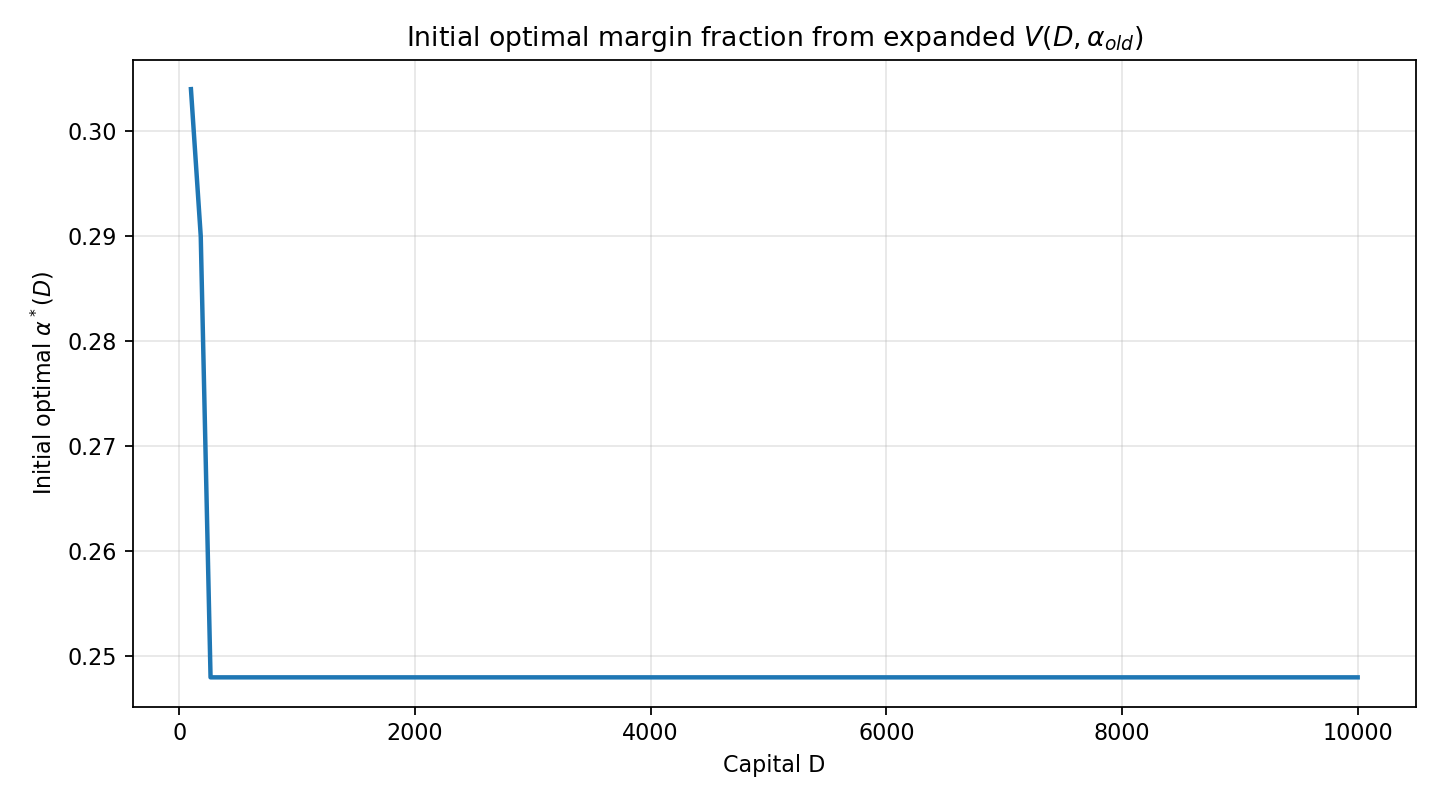

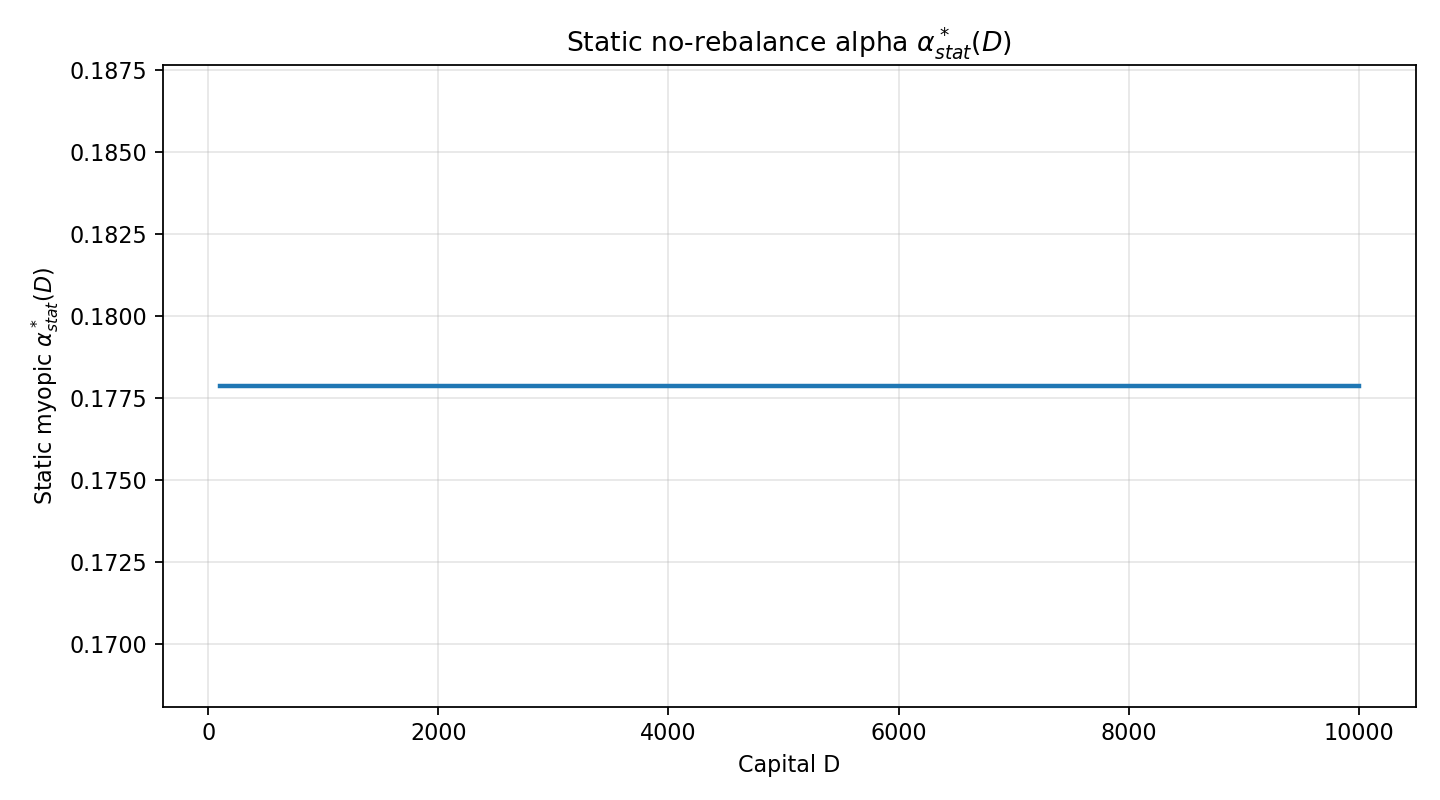

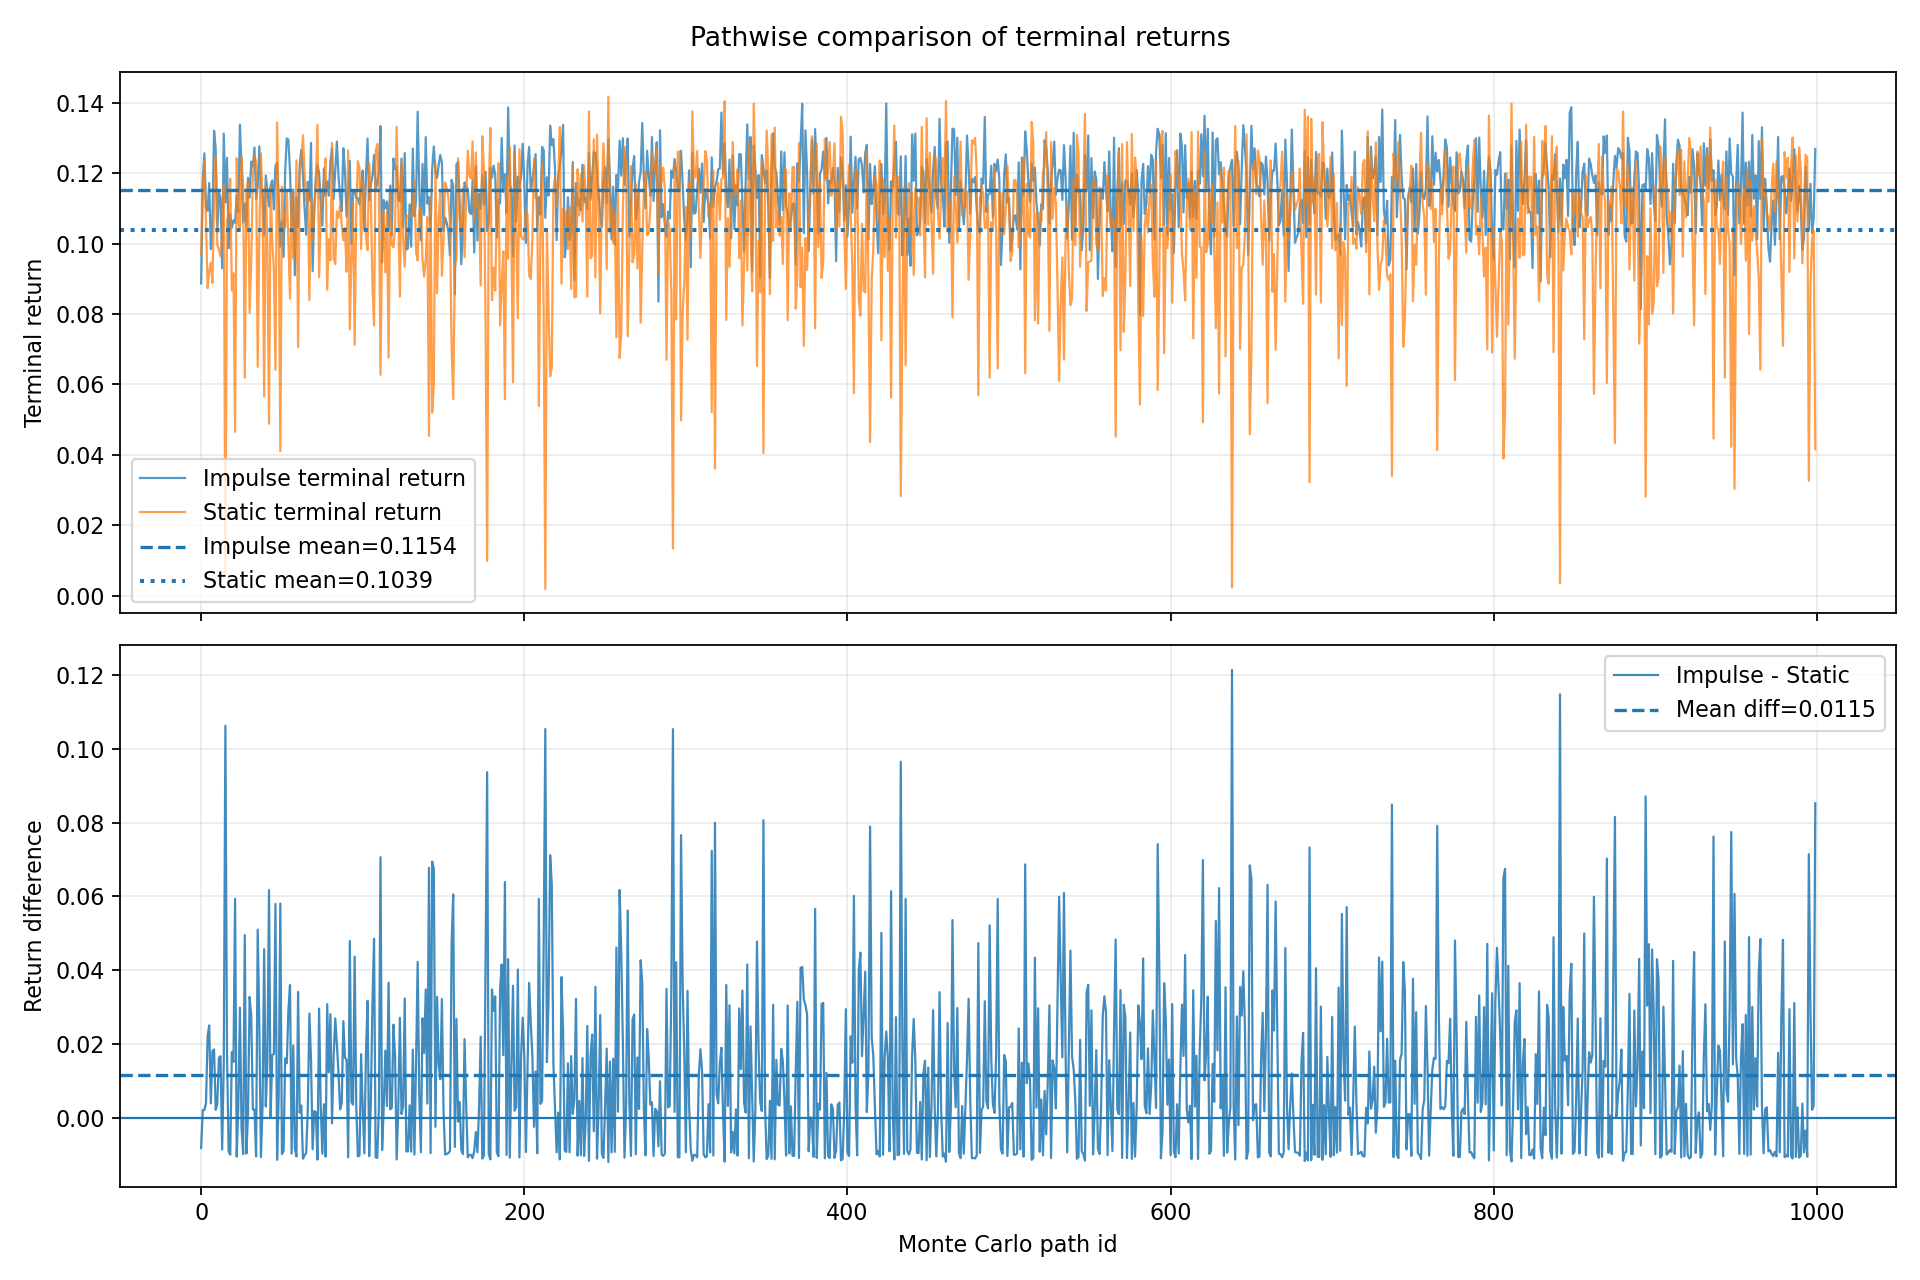


Searching sample path with impulse n_rebalances in [4, 5, 6]...
Search finished. real_time=2.11s
sample seed                  = 10003238
impulse n_rebalances         = 4
static n_rebalances          = 18
impulse terminal return      = 0.10143808
static terminal return       = -0.04234186

Sample path plots:
simulation_outputs\sample_impulse_path_4_6_rebalances_howard.png
simulation_outputs\sample_static_path_same_price_howard.png
simulation_outputs\sample_impulse_vs_static_same_price_howard.png


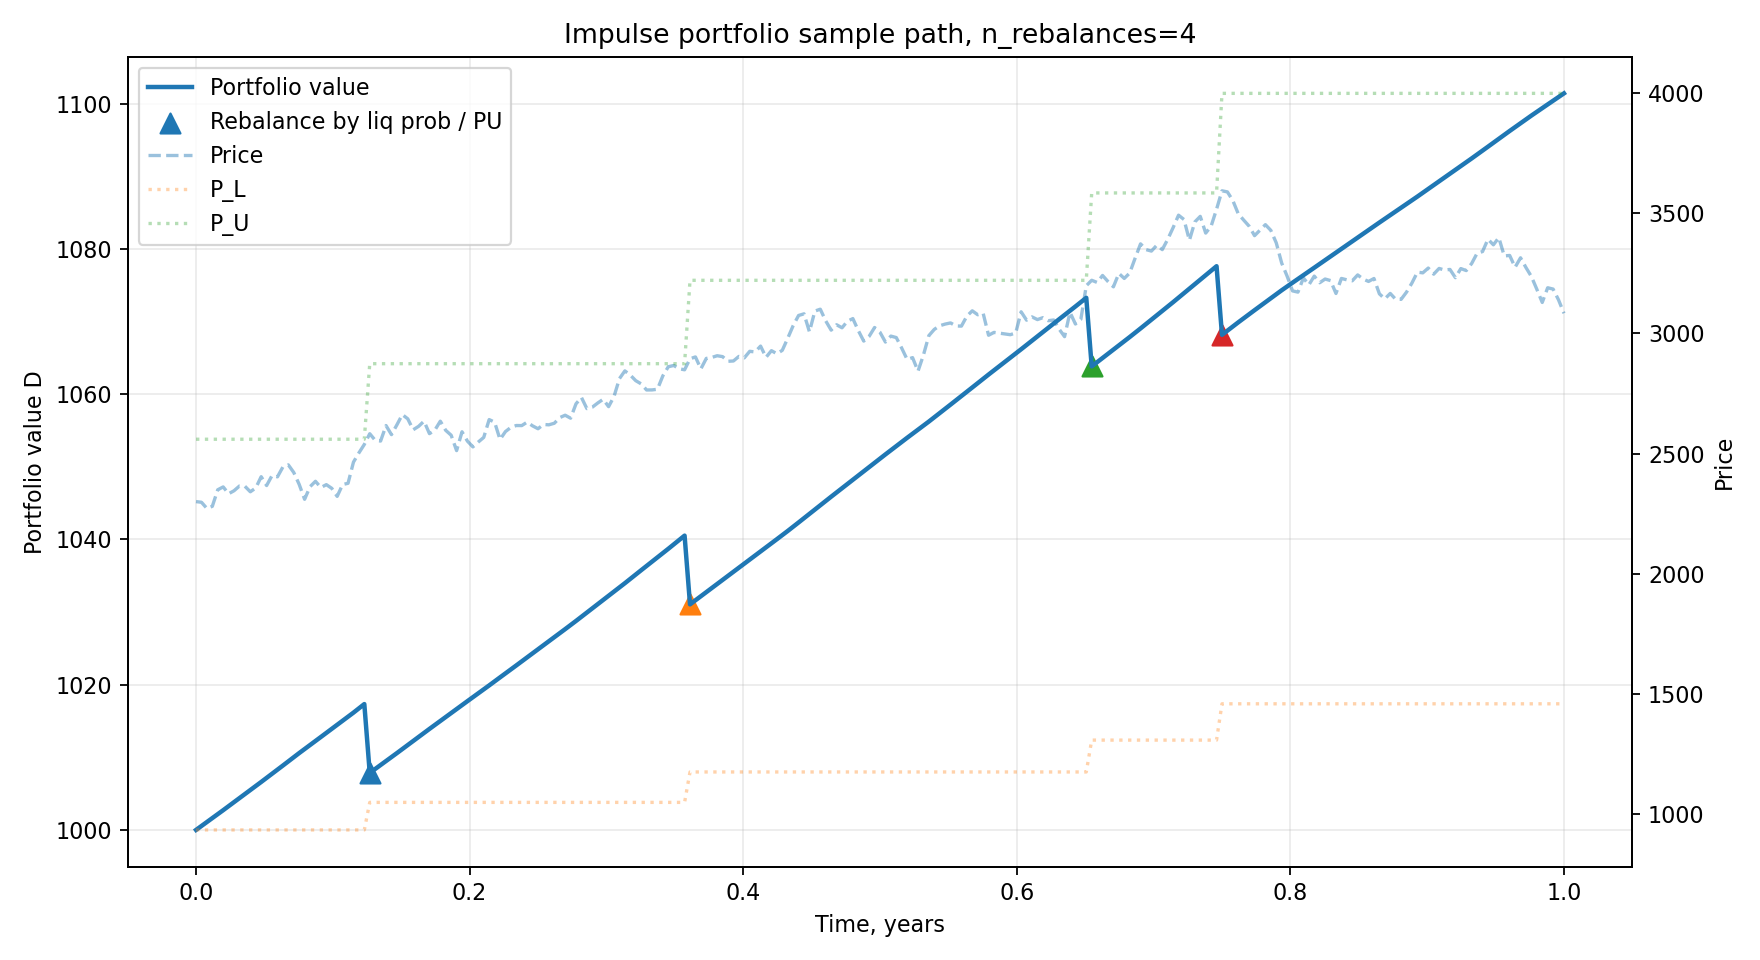

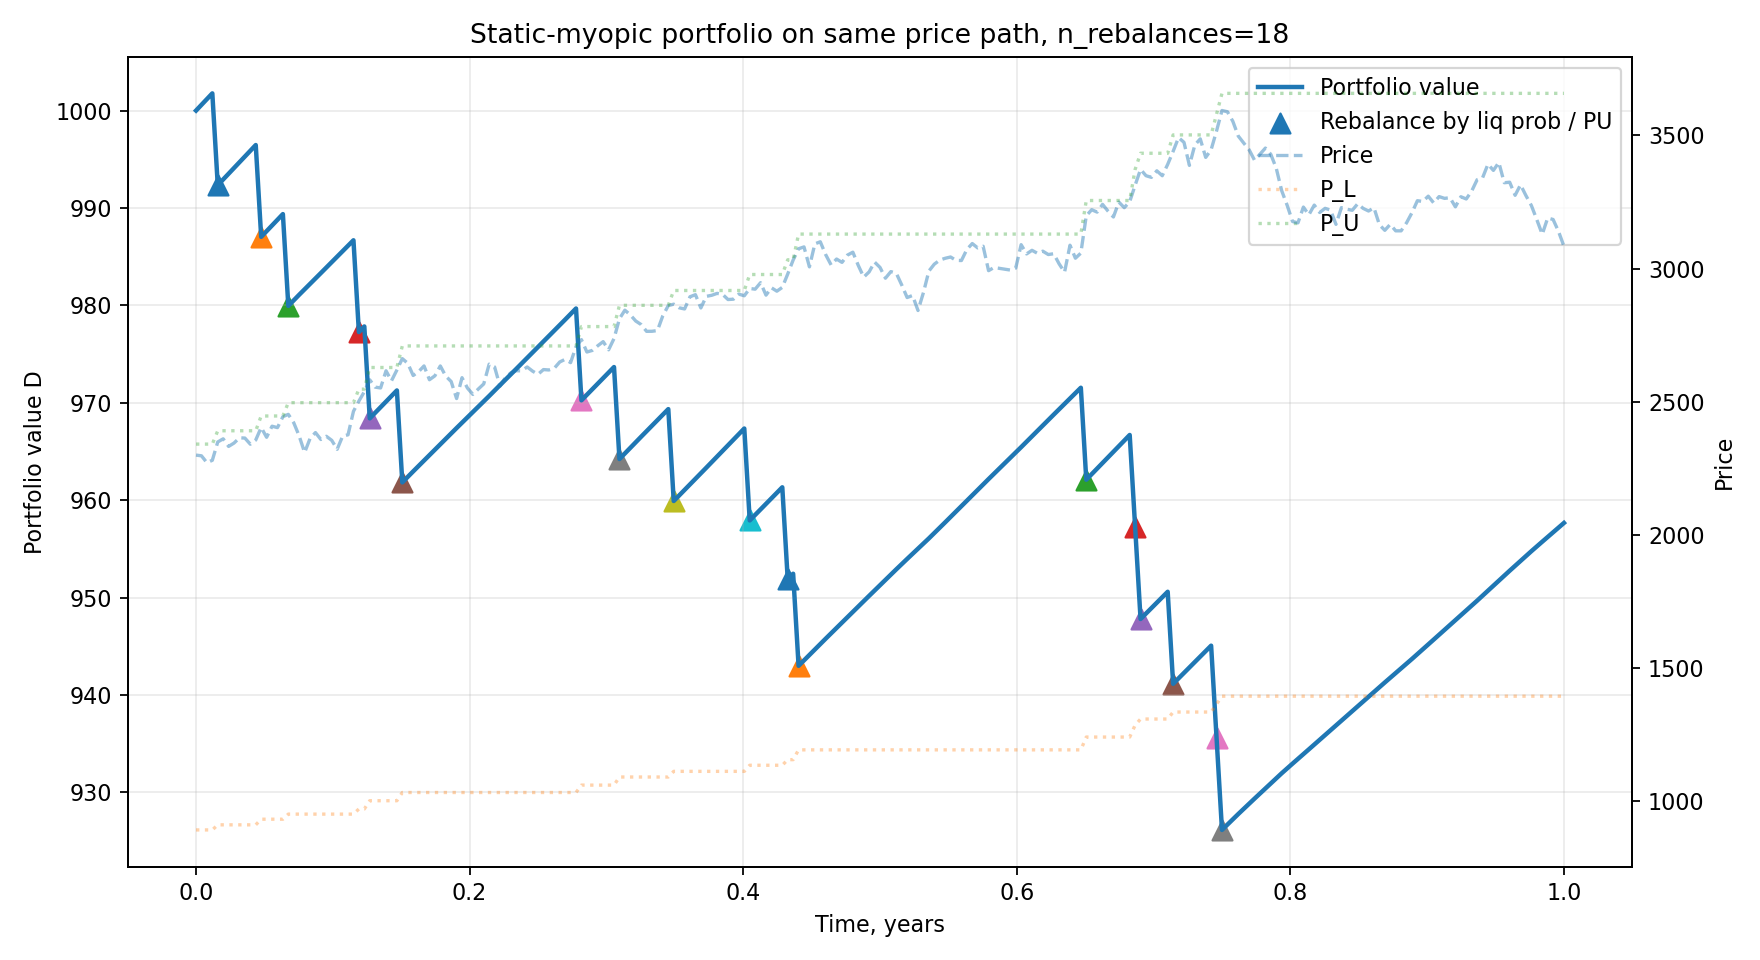

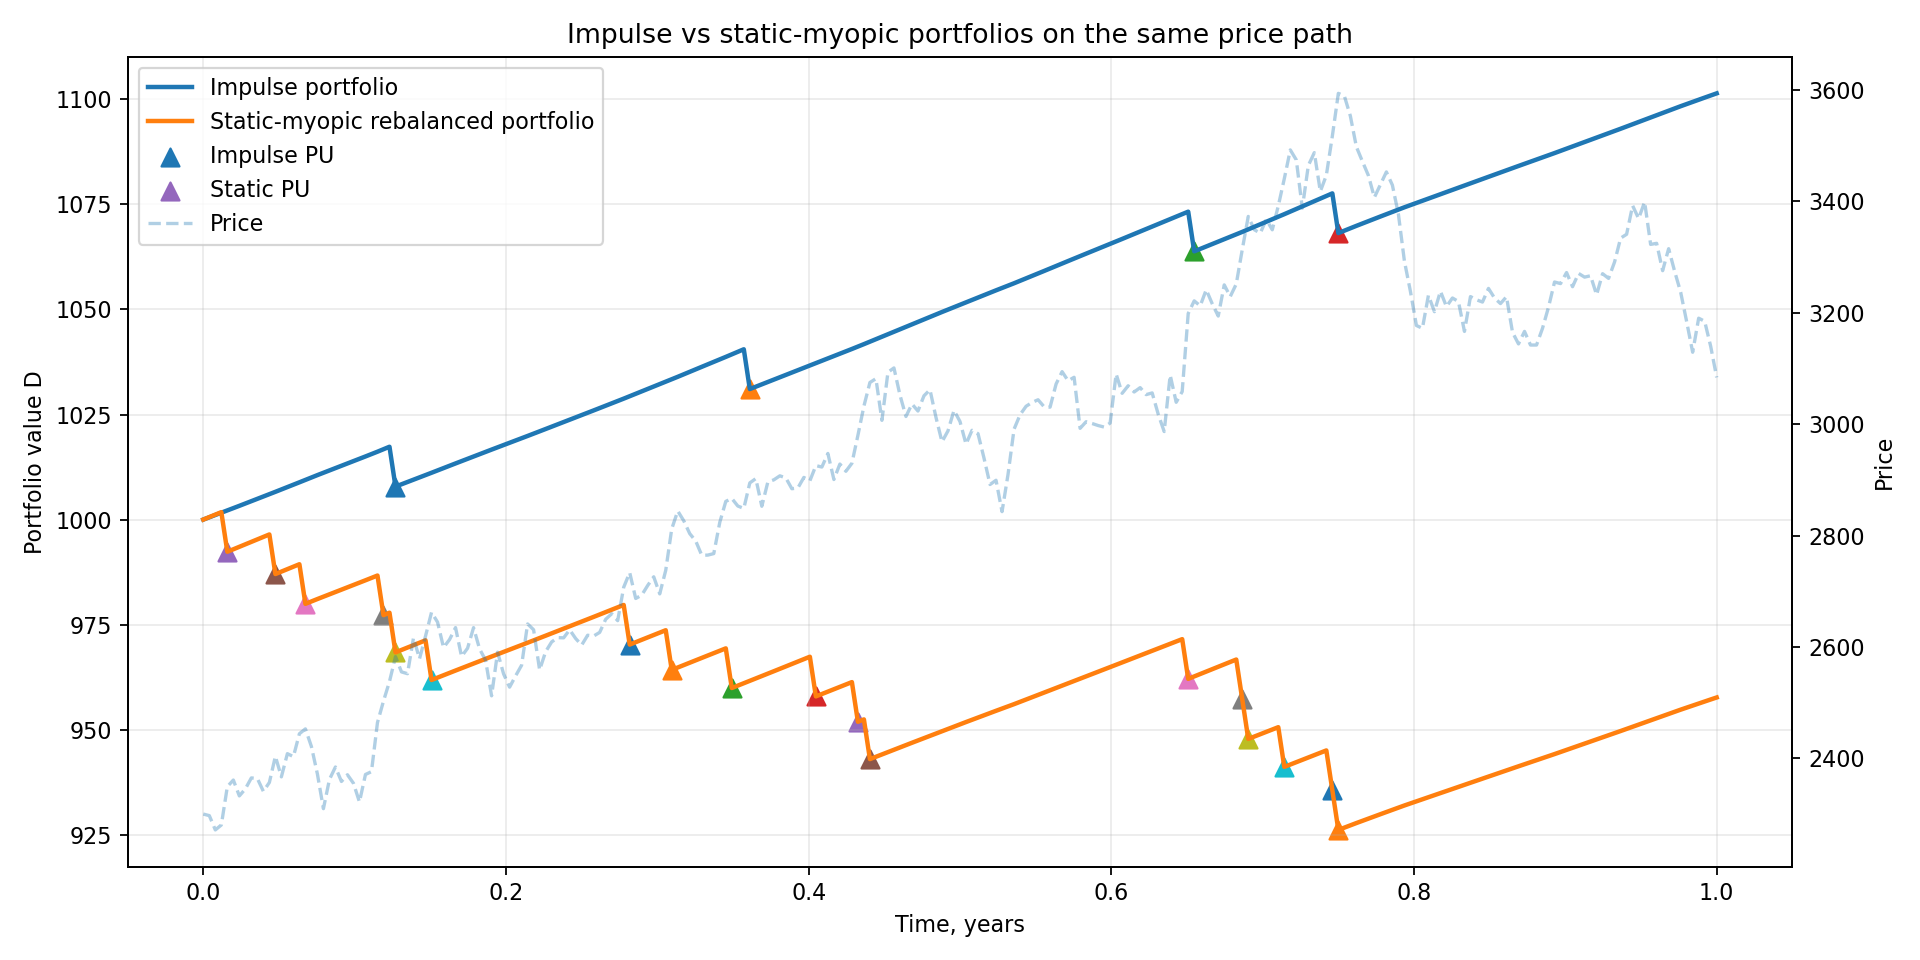


Impulse rebalance events:


,time,price,portfolio_before_cost,cost,portfolio_after_cost,trigger,old_alpha,new_alpha
0,0.126984,2582.560662,1017.935039,10.086483,1007.848557,PU,0.248,0.248
1,0.361111,2894.452878,1041.138199,10.074073,1031.064126,PU,0.248,0.248
2,0.654762,3221.236268,1073.900782,10.062892,1063.837890,PU,0.248,0.248
3,0.750000,3593.701629,1078.270788,10.089237,1068.181551,PU,0.248,0.248



Static-myopic rebalance events:


,time,price,portfolio_before_cost,cost,portfolio_after_cost,trigger,old_alpha,new_alpha
0,0.015873,2349.262483,1002.363956,10.023906,992.340050,PU,0.177869,0.177869
1,0.047619,2403.692314,997.057054,10.023264,987.033790,PU,0.177869,0.177869
2,0.067460,2452.931873,989.966618,10.022452,979.944166,PU,0.177869,0.177869
3,0.119048,2502.739147,987.271033,10.018572,977.252462,PU,0.177869,0.177869
4,0.126984,2582.560662,978.428220,10.032906,968.395313,PU,0.177869,0.177869
5,0.150794,2662.099984,971.849808,10.029926,961.819882,PU,0.177869,0.177869
6,0.281746,2733.492403,980.260772,10.014278,970.246494,PU,0.177869,0.177869
7,0.309524,2811.893968,974.248071,10.027833,964.220238,PU,0.177869,0.177869
8,0.349206,2866.603047,969.928058,10.018968,959.909090,PU,0.177869,0.177869
9,0.404762,2925.541222,967.931979,10.017866,957.914114,PU,0.177869,0.177869


In [1]:
# ==============================
# Howard impulse simulator runner
# ==============================

import sys
import time
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ---------------------------------------------------------------------
# 0. Path to Howard simulator .py
# ---------------------------------------------------------------------
SIMULATOR_PY = Path("impulse_alpha_simulator_howard.py")

if not SIMULATOR_PY.exists():
    raise FileNotFoundError(f"Simulator file not found: {SIMULATOR_PY}")

spec = importlib.util.spec_from_file_location("impulse_sim_howard", SIMULATOR_PY)
impulse_sim = importlib.util.module_from_spec(spec)
sys.modules["impulse_sim_howard"] = impulse_sim
spec.loader.exec_module(impulse_sim)

# ---------------------------------------------------------------------
# 1. USER PARAMETERS
# ---------------------------------------------------------------------
params = impulse_sim.ModelParams(
    mu=-0.3,
    sigma=0.2,
    kappa=0.015,
    iota=0.00375,
    kappa_tilde=0.545,
    gamma=0.05,
    
    # Ваши текущие параметры:
    rho=0.065,
    rx=0.0725,
    
    p0=2300.0,
    h=1.0,
    initial_D=1000.0,
    
    theta_F=0.0100,
    epsilon=0.06,
    
    c_spot_bps=5.0,
    c_fut_bps=5.0,
    fixed_dollar_cost=10.0,
    
    # PuPl.txt convention: short futures
    futures_sign=-1.0,
)

# ---------------------------------------------------------------------
# 2. HOWARD POLICY TABLE CONFIG
# ---------------------------------------------------------------------
table_cfg = impulse_sim.TableConfig(
    d_min=100.0,
    d_max=10_000.0,
    n_d=120,
    
    alpha_min=0.01,
    alpha_max=0.99,
    n_alpha=71,
    
    n_episode_mc=2000,
    dt_episode=1.0 / 252.0,
    max_episode_time=2.0,
    
    # Howard policy iteration
    solver="howard",
    max_iter=40,              # number of policy-improvement rounds
    tol=1e-3,                 # Bellman residual tolerance
    relaxation=1.0,
    
    policy_eval_sweeps=25,    # fixed-policy evaluation sweeps per policy update
    policy_eval_tol=1e-5,
    policy_stable_iters=2,    # stop if policy unchanged for 2 improvement rounds
    
    seed=42,
    policy_csv="simulation_outputs/alpha_policy_table_howard.csv",
)

# ---------------------------------------------------------------------
# 3. MONTE CARLO SIMULATION CONFIG
# ---------------------------------------------------------------------
sim_cfg = impulse_sim.SimulationConfig(
    n_paths=1000,
    simulation_years=1.0,
    dt=1.0 / 252.0,
    n_jobs=-1,
    parallel_backend="threads",
    seed=777,
    output_dir="simulation_outputs",
)

FORCE_RECOMPUTE_POLICY = False

# Для красивого sample path ищем траекторию, где impulse делает 4-6 ребалансировок.
TARGET_REBALANCES = {4, 5, 6}
MAX_SAMPLE_SEARCH = 5000

out_dir = Path(sim_cfg.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)

# Если policy_csv относительный, положим его в output_dir
policy_csv = Path(table_cfg.policy_csv)
if not policy_csv.is_absolute():
    table_cfg = impulse_sim.TableConfig(
        **{
            **table_cfg.__dict__,
            "policy_csv": str(out_dir / policy_csv.name),
        }
    )

print("Model parameters:")
print(params)
print(f"\nComputed zeta = {params.zeta:.10f}")

print("\nHoward TableConfig:")
print(table_cfg)

print("\nSimulationConfig:")
print(sim_cfg)

# ---------------------------------------------------------------------
# 4. BUILD OR LOAD HOWARD POLICY TABLE
# ---------------------------------------------------------------------
print("\nBuilding/loading Howard policy table...")
t0 = time.perf_counter()

policy_df = impulse_sim.build_or_load_policy_table(
    params=params,
    table_cfg=table_cfg,
    force_recompute=FORCE_RECOMPUTE_POLICY,
)

print(f"\nPolicy table ready. real_time={time.perf_counter() - t0:.2f}s")
display(policy_df.head())

policy = impulse_sim.AlphaPolicy(policy_df)
bounds = impulse_sim.RebalancingBounds(params)

# ---------------------------------------------------------------------
# 5. STATIC-MYOPIC ALPHA
# ---------------------------------------------------------------------
static_optimizer = impulse_sim.StaticAlphaOptimizer(
    params=params,
    alpha_min=table_cfg.alpha_min,
    alpha_max=table_cfg.alpha_max,
)

static_alpha = static_optimizer.optimal_alpha(params.initial_D, p0=params.p0)

print(f"\nStatic one-horizon alpha = {static_alpha:.8f}")

# ---------------------------------------------------------------------
# 6. PAIRED MONTE CARLO: IMPULSE VS STATIC
# ---------------------------------------------------------------------
print("\nRunning paired Monte Carlo: impulse vs static-myopic...")
t0 = time.perf_counter()

mc_df = impulse_sim.run_parallel_monte_carlo_comparison(
    params=params,
    sim_cfg=sim_cfg,
    policy_df=policy_df,
    static_alpha=static_alpha,
)

mc_time = time.perf_counter() - t0

mc_path = out_dir / "portfolio_mc_results_howard.csv"
mc_df.to_csv(mc_path, index=False)

summary_df = impulse_sim.summarize_return_comparison(mc_df)
summary_path = out_dir / "terminal_return_comparison_summary_howard.csv"
summary_df.to_csv(summary_path, index=False)

print(f"\nMonte Carlo finished. real_time={mc_time:.2f}s")
print(f"Saved MC results to: {mc_path}")
print(f"Saved summary to: {summary_path}")

display(summary_df)

print("\nImpulse portfolio:")
print(f"mean terminal return         = {mc_df['impulse_terminal_return'].mean():.8f}")
print(f"variance terminal return     = {mc_df['impulse_terminal_return'].var(ddof=1):.8f}")
print(f"mean n_rebalances            = {mc_df['impulse_n_rebalances'].mean():.4f}")

print("\nStatic-myopic portfolio:")
print(f"mean terminal return         = {mc_df['static_terminal_return'].mean():.8f}")
print(f"variance terminal return     = {mc_df['static_terminal_return'].var(ddof=1):.8f}")
print(f"mean n_rebalances            = {mc_df['static_n_rebalances'].mean():.4f}")

print("\nPaired comparison:")
print(f"mean impulse - static        = {mc_df['impulse_minus_static_return'].mean():.8f}")
print(f"variance impulse - static    = {mc_df['impulse_minus_static_return'].var(ddof=1):.8f}")
print(f"impulse win rate             = {mc_df['impulse_wins'].mean():.4f}")

# ---------------------------------------------------------------------
# 7. PLOTS: alpha policy, static alpha, terminal comparison
# ---------------------------------------------------------------------
alpha_plot = out_dir / "alpha_policy_vs_D_howard.png"
static_alpha_plot = out_dir / "static_alpha_policy_vs_D_howard.png"
comparison_plot = out_dir / "terminal_return_comparison_howard.png"

impulse_sim.plot_alpha_policy(policy_df, alpha_plot)

static_policy_df = static_optimizer.policy_table(
    np.array(sorted(policy_df["D"].unique()), dtype=float),
    p0=params.p0,
)
impulse_sim.plot_static_alpha_policy(static_policy_df, static_alpha_plot)

impulse_sim.plot_terminal_return_comparison(mc_df, comparison_plot)

print("\nSaved plots:")
print(alpha_plot)
print(static_alpha_plot)
print(comparison_plot)

display(Image(filename=str(alpha_plot)))
display(Image(filename=str(static_alpha_plot)))
display(Image(filename=str(comparison_plot)))

# ---------------------------------------------------------------------
# 8. FIND SAMPLE PATH WHERE IMPULSE HAS 4-6 REBALANCES
# ---------------------------------------------------------------------
def find_sample_path_with_target_rebalances(
    params,
    sim_cfg,
    policy,
    static_optimizer,
    bounds,
    target_rebalances={4, 5, 6},
    max_search=5000,
    base_seed=10_000_000,
):
    """
    Ищем synthetic price path, где impulse-control делает 4-6 ребалансировок.
    Если точный вариант не найден, возвращаем ближайший по числу ребалансировок.
    """
    target_mid = float(np.mean(list(target_rebalances)))
    best_pack = None
    best_distance = np.inf

    for i in range(max_search):
        seed = base_seed + i
        rng = np.random.default_rng(seed)

        times, prices = impulse_sim.generate_synthetic_price_path(
            params=params,
            sim_cfg=sim_cfg,
            rng=rng,
            p0=params.p0,
        )

        impulse_sample = impulse_sim.run_portfolio_on_price_path(
            prices=prices,
            times=times,
            params=params,
            policy=policy,
            bounds=bounds,
        )

        n_reb = int(impulse_sample["n_rebalances"])
        distance = abs(n_reb - target_mid)

        if distance < best_distance:
            static_sample = impulse_sim.run_static_portfolio_on_price_path(
                prices=prices,
                times=times,
                params=params,
                static_optimizer=static_optimizer,
                bounds=bounds,
            )

            best_pack = {
                "seed": seed,
                "times": times,
                "prices": prices,
                "impulse": impulse_sample,
                "static": static_sample,
                "impulse_n_rebalances": n_reb,
                "static_n_rebalances": int(static_sample["n_rebalances"]),
            }
            best_distance = distance

        if n_reb in target_rebalances:
            static_sample = impulse_sim.run_static_portfolio_on_price_path(
                prices=prices,
                times=times,
                params=params,
                static_optimizer=static_optimizer,
                bounds=bounds,
            )

            return {
                "seed": seed,
                "times": times,
                "prices": prices,
                "impulse": impulse_sample,
                "static": static_sample,
                "impulse_n_rebalances": n_reb,
                "static_n_rebalances": int(static_sample["n_rebalances"]),
            }

    return best_pack


print(f"\nSearching sample path with impulse n_rebalances in {sorted(TARGET_REBALANCES)}...")
t0 = time.perf_counter()

sample_pack = find_sample_path_with_target_rebalances(
    params=params,
    sim_cfg=sim_cfg,
    policy=policy,
    static_optimizer=static_optimizer,
    bounds=bounds,
    target_rebalances=TARGET_REBALANCES,
    max_search=MAX_SAMPLE_SEARCH,
)

print(f"Search finished. real_time={time.perf_counter() - t0:.2f}s")
print(f"sample seed                  = {sample_pack['seed']}")
print(f"impulse n_rebalances         = {sample_pack['impulse_n_rebalances']}")
print(f"static n_rebalances          = {sample_pack['static_n_rebalances']}")
print(f"impulse terminal return      = {sample_pack['impulse']['terminal_return']:.8f}")
print(f"static terminal return       = {sample_pack['static']['terminal_return']:.8f}")

# ---------------------------------------------------------------------
# 9. SAMPLE PATH VISUALIZATIONS
# ---------------------------------------------------------------------
impulse_sample_plot = out_dir / "sample_impulse_path_4_6_rebalances_howard.png"
static_sample_plot = out_dir / "sample_static_path_same_price_howard.png"
combined_sample_plot = out_dir / "sample_impulse_vs_static_same_price_howard.png"

impulse_sim.plot_sample_path(
    sample_pack["impulse"],
    impulse_sample_plot,
    title=f"Impulse portfolio sample path, n_rebalances={sample_pack['impulse_n_rebalances']}",
)

impulse_sim.plot_sample_path(
    sample_pack["static"],
    static_sample_plot,
    title=f"Static-myopic portfolio on same price path, n_rebalances={sample_pack['static_n_rebalances']}",
)

impulse_sim.plot_combined_portfolio_paths(
    sample_pack["impulse"],
    sample_pack["static"],
    combined_sample_plot,
)

print("\nSample path plots:")
print(impulse_sample_plot)
print(static_sample_plot)
print(combined_sample_plot)

display(Image(filename=str(impulse_sample_plot)))
display(Image(filename=str(static_sample_plot)))
display(Image(filename=str(combined_sample_plot)))

# ---------------------------------------------------------------------
# 10. REBALANCE EVENT TABLES
# ---------------------------------------------------------------------
impulse_events = pd.DataFrame(sample_pack["impulse"]["rebalance_events"])
static_events = pd.DataFrame(sample_pack["static"]["rebalance_events"])

print("\nImpulse rebalance events:")
display(impulse_events)

print("\nStatic-myopic rebalance events:")
display(static_events)